# Endometriosis single-cell analysis: data challenge

**Author:** Richard Ahn, PhD

**Dataset:** Human Endometrial Cell Atlas (HECA), scRNA-seq arm, Mareckova et al., *Nature Genetics* 2024 (`s41588-024-01873-w`), ArrayExpress `E-MTAB-14039`.

**Task:** Compare eutopic endometrium from endometriosis cases vs controls, select a dysregulated cell type, derive a biological insight, and propose a therapeutic intervention.

---

## Summary of the approach and the key finding

The HECA scRNA-seq atlas integrates seven datasets (313,527 cells, 63 donors) with scVI. The authors themselves report **no endometriosis-specific cell type** in the main results, and the disease signal they report is subtle and surfaces via differential abundance, functional GWAS, and a (confounded) differential expression analysis that points to **decidualized stromal cells** and **macrophages**. The authors point to the **IGF axis** (IGF1 up in uM2 macrophages, the IGF program shifting in decidualized stroma) as the biology of interest.

This notebook set out to re-analyze the HECA data and determine an endometriosis-specific dysregulated cell type, identify any biological insight from this cell type, and whether the dysregulated biology can be targeted with a therapeutic intervention with a time budget of less than one business day. With this time budget in mind, I didn't download the individual data files posted on `E-MTAB-14039` to process, normalize, and re-integrate using scVI (or similar batch reduction/integration method). Instead I chose to use `https://cellgeni.cog.sanger.ac.uk/vento/reproductivecellatlas/endometriumAtlasV2_cells_with_counts.h5ad`, the final, filtered dataset the Vento lab published to save time and not necessitate having to stand up a large GPU-equipped cloud compute instance. I acknowledge that this choice limited me to the ~17.7K genes in the final dataset and the QC filtering thresholds that the Vento lab implemented. With limited time, I wanted to spend it getting to the biology.

What I found is that their scRNA-seq case/control differential expression does not reproduce under batch control, and their published DE design does not account for the confound that drives it. I want to be precise about the scope of this claim: it concerns the scRNA-seq differential expression specifically, not their differential abundance (which they ran on single-nuclei data) or their functional GWAS, which are separate lines of evidence I do not re-examine here. Within their scRNA-seq DE, the specific issues are:
- **The case/control differential expression on this atlas is confounded by dataset-of-origin.** The seven source datasets are partly separated by condition (some are entirely cases or entirely controls), so a pooled `~condition` contrast reports batch as disease.
- **After adjusting for dataset and restricting to datasets that contain both arms (endometriosis cases and controls), the candidate signals collapse.** IGF1 does not reach significance in uM2 macrophages, uM1 macrophages, or decidualized stroma, and the macrophage compartment yields no genes at FDR < 0.05. Exogenous-hormone treatment is confounded with case status (far more cases are treated), so the primary contrast is fit both without and with a treatment term; adjusting for treatment moves IGF1 toward the reference's case-up direction in every compartment but never clears significance. The strong stromal IGF2 effect seen in a naive contrast is a dataset main effect that vanishes under adjustment.
- **No reproducible disease signature survives the strongest test.** Fitting case vs control independently within the two largest both-arm datasets (Mareckova, Huang), the per-gene fold-changes do not correlate (Pearson r near zero). The one compartment with residual batch-controlled hits (decidualized stroma) is small, does not reproduce genome-wide, and is dominated by tissue-handling and epithelial-contamination genes rather than a coherent program. It does not include IGF1 or IGF2.
- **This holds across every cell type, and against a second study.** Running the same batch-controlled, reproducibility-gated DE on all cell types (section 5h) surfaces no reproducible disease program in any of them, and an externally-defined signature from Fonseca et al. (2023) does not transfer intact (only CRIP1 in epithelium keeps its case-up direction across datasets). A bulk EndMT signature (Liang et al. 2025) likewise does not transfer, and single-cell resolution reassigns its VIM/CDH11/FGF2 signal to the stromal compartment rather than a true endothelial transition (section 5i). Section 4a also cross-validates the shipped annotation against Fonseca's independent marker panel.

Two suggestive results come out of this despite the overall negative result. First, in direct answer to the brief, the cell type and signature this atlas best supports is **endometrial secretory/luminal epithelium marked by CRIP1**, the one externally-defined gene (from Fonseca et al. 2023) that holds its case-up direction across both independent datasets, alongside a coherent early-TGF-β/growth program in the **functionalis (SOX9) epithelium** that is directionally reproducible in both datasets under the most sensitive method applied here (GSEA). Both are faint and neither clears the genome-wide reproducibility bar, so I offer them as leads to test rather than as targets this atlas establishes. Second, and more transferable, the reanalysis implies a concrete study and analysis design that would let a dataset like this nominate a target credibly (section 6): balance condition within batch, distribute exogenous-hormone treatment across arms, use batch-aware donor-level DE with cross-dataset reproducibility as the acceptance bar, and sample the right tissue and stage (ectopic lesion, and basalis-inclusive rather than superficial eutopic biopsies, with spatial transcriptomics to resolve the epithelial-stromal junction).

All that said, the bottom line is that this atlas, analyzed with donor-level replication and batch control, does not establish an endometriosis-specific dysregulated cell type or a credible IGF1-anchored target. A real signal may exist, but the data as assembled cannot separate it from batch, and if a precursor signature exists in **eutopic endometrium** it is very subtle and most plausibly sits in compartments this cohort barely samples.

## How to run

Environment is managed with **uv** (`pyproject.toml` + `uv.lock` pin exact versions).

1. `uv sync` to build the environment from the lockfile.
2. Register the kernel once and run this notebook on it:
   `uv run python -m ipykernel install --user --name heca --display-name "HECA (uv)"`.
3. For fast iteration use the ~90k-cell subset (`HECA-Subset.h5ad`, Zenodo record 15072628); for the definitive run use the full atlas (`endometriumAtlasV2_cells_with_counts.h5ad`) from the VentoLab reproductive cell atlas portal, the HECA scRNA-seq object deposited as `E-MTAB-14039`. Single-nuclei objects are out of scope. Set `DATA_PATH` in the **Config** cell accordingly.
4. Run top to bottom. The **Config** cell is the only place you should need to edit: the inspection cell right after loading prints the `.obs` schema so the column names can be set.

Runtime is modest and manageable on a 2020 M1 MacBook Pro with 16 GB RAM because the atlas ships already integrated and annotated: the heavy lifting is QC review, annotation validation, a de novo re-annotation of the immune compartment (to recover the uM1/uM2 macrophage split the shipped labels collapse), and the batch-aware case/control differential expression that carries the argument.

## 0. Setup and reproducibility

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns

sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=90, frameon=False, figsize=(5, 5))

SEED = 0
np.random.seed(SEED)

print("scanpy", sc.__version__)
print("anndata", ad.__version__)

scanpy 1.11.5
anndata 0.12.19


## 1. Config

Everything environment-specific lives here. After the first load, the inspection cell prints the available `.obs` columns and their values so these can be set in a couple of minutes. Defaults reflect the most common HECA field names; adjust to the object you downloaded.

In [2]:
# ============================ Config ============================
# The only cell that should need editing per environment. Column names are shared across the
# subset and the full atlas; the per-dataset differences (path, condition encoding, where raw
# counts live, in-memory vs backed) are set by the switch below.

# ---- dataset switch: subset = fast prototyping, full atlas = definitive run ----
USE_FULL_ATLAS = True
if USE_FULL_ATLAS:
    DATA_PATH        = "endometriumAtlasV2_cells_with_counts.h5ad"  # HECA scRNA-seq, E-MTAB-14039
    BACKED           = True               # 16 GB object: hold log-norm X in RAM, stream counts from disk
    CONDITION_COL    = "Group"            # case/control encoded here on the full atlas
    CASE_LABELS      = {"Endo_Superficial"}
    CONTROL_LABELS   = {"Ctrl_Superficial"}   # Ctrl_whole_uterus excluded (different biopsy type)
    RAW_COUNTS_LAYER = "counts"           # full atlas ships log-norm X; raw counts live in this layer
else:
    DATA_PATH        = "HECA-Subset.h5ad" # Zenodo record 15072628, ~90k cells
    BACKED           = False
    CONDITION_COL    = "Endometriosis"
    CASE_LABELS      = {"Endometriosis"}
    CONTROL_LABELS   = {"Control"}
    RAW_COUNTS_LAYER = None               # subset ships raw counts in .X

# ---- .obs column names (shared; verified against the inspection cell) ----
CELLTYPE_COL = "celltype"             # fine-grained cell state / annotation
LINEAGE_COL  = "lineage"             # coarse lineage
DONOR_COL    = "sample"             # donor / patient identifier
DATASET_COL  = "dataset"            # source dataset (batch)
PHASE_COL    = None                  # NOTE: obs['phase'] is CELL-CYCLE (G1/S/G2M), not menstrual phase,
                                     # so it is not used as a DE covariate
HORMONE_COL  = "Hormonal treatment" # free-text drug names (blank/nan/- = untreated); modeled as a DE
                                     # covariate, not an exclusion (see section 2)

# ---- QC thresholds, matched to the reference Methods ----
MIN_GENES    = 1000    # cells with < 1000 detected genes are dropped
MAX_PCT_MITO = 20.0    # cells with > 20% mitochondrial content are dropped
N_HVG        = 2000    # highly variable genes (Seurat v3 flavor)

## 2. Load and inspect

In [3]:
import anndata as ad, gc

if BACKED:
    # Full atlas (16 GB): materialize the log-normalized X only (~3.5 GB). The raw counts layer
    # stays on disk and is streamed per-compartment for pseudobulk (see fetch_counts). This runs
    # the whole pipeline on the full object while keeping peak RAM well under 16 GB.
    _bk = sc.read_h5ad(DATA_PATH, backed="r")
    adata = ad.AnnData(X=_bk.X[:], obs=_bk.obs.copy(), var=_bk.var.copy(),
                       obsm={k: np.asarray(_bk.obsm[k]) for k in _bk.obsm.keys()})
    _bk.file.close(); del _bk; gc.collect()
    COUNTS_BACKED = sc.read_h5ad(DATA_PATH, backed="r")   # kept open to stream raw counts on demand
    adata.obs["_row"] = np.arange(adata.n_obs)            # row position in the backed file
else:
    adata = sc.read_h5ad(DATA_PATH)
    COUNTS_BACKED = None

def fetch_counts(adata_sub):
    """Raw counts (cells x genes, CSR) for the cells in adata_sub: from the in-memory 'counts'
    layer if present, else streamed from the backed file by row position. Gene order follows var."""
    import scipy.sparse as sp
    if "counts" in adata_sub.layers:
        C = adata_sub.layers["counts"]
        return C.tocsr() if sp.issparse(C) else sp.csr_matrix(C)
    pos = adata_sub.obs["_row"].to_numpy()
    order = np.argsort(pos)                                # h5py fancy-index needs increasing order
    C = COUNTS_BACKED.layers[RAW_COUNTS_LAYER][pos[order]]
    C = C.tocsr() if sp.issparse(C) else sp.csr_matrix(C)
    return C[np.argsort(order)]                            # restore adata_sub order

print(adata)

AnnData object with n_obs × n_vars = 313527 × 17736
    obs: 'n_genes', 'sample', 'library', 'Processing', 'Treatment', '10x kit', 'percent_mito', 'n_counts', 'scrublet_score', 'genotype', 'Library_genotype', 'Group', 'Endometriosis_stage', 'Hormonal treatment', 'Binary Stage', 'Stage', 'phase', 'dataset', 'Biopsy_type', 'Tissue_sampled', 'Age', 'Endometrial_pathology', 'celltype', 'lineage', 'label_long', '_row'
    var: 'gene_ids-0-Fonseca', 'feature_types-0-Fonseca', 'n_cells-0-Fonseca', 'gene_ids-1-Fonseca', 'feature_types-1-Fonseca', 'n_cells-1-Fonseca', 'gene_ids-2-Fonseca', 'feature_types-2-Fonseca', 'n_cells-2-Fonseca', 'gene_ids-3-Fonseca', 'feature_types-3-Fonseca', 'n_cells-3-Fonseca', 'gene_ids-4-Fonseca', 'feature_types-4-Fonseca', 'n_cells-4-Fonseca', 'gene_ids-5-Fonseca', 'feature_types-5-Fonseca', 'n_cells-5-Fonseca', 'gene_ids-6-Fonseca', 'feature_types-6-Fonseca', 'n_cells-6-Fonseca', 'MT-Fonseca', 'n_cells_by_counts-Fonseca', 'mean_counts-Fonseca', 'pct_dropout_by_co

Inspect the metadata so the config above can be set correctly. This prints the `.obs` columns, plus the value counts for the columns we depend on.

In [4]:
print("obs columns:\n", list(adata.obs.columns), "\n")
print("obsm keys:", list(adata.obsm.keys()))
print("layers:", list(adata.layers.keys()))
print("var columns:", list(adata.var.columns), "\n")

for col in [CELLTYPE_COL, CONDITION_COL, DONOR_COL, DATASET_COL, PHASE_COL, HORMONE_COL, LINEAGE_COL]:
    if col is not None and col in adata.obs.columns:
        vc = adata.obs[col].value_counts(dropna=False)
        print(f"--- {col} ({adata.obs[col].nunique()} unique) ---")
        print(vc.head(30), "\n")
    elif col is not None:
        print(f"!! '{col}' not found in .obs - update the config.\n")

obs columns:
 ['n_genes', 'sample', 'library', 'Processing', 'Treatment', '10x kit', 'percent_mito', 'n_counts', 'scrublet_score', 'genotype', 'Library_genotype', 'Group', 'Endometriosis_stage', 'Hormonal treatment', 'Binary Stage', 'Stage', 'phase', 'dataset', 'Biopsy_type', 'Tissue_sampled', 'Age', 'Endometrial_pathology', 'celltype', 'lineage', 'label_long', '_row'] 

obsm keys: ['X_scVI', 'X_umap']
layers: []
var columns: ['gene_ids-0-Fonseca', 'feature_types-0-Fonseca', 'n_cells-0-Fonseca', 'gene_ids-1-Fonseca', 'feature_types-1-Fonseca', 'n_cells-1-Fonseca', 'gene_ids-2-Fonseca', 'feature_types-2-Fonseca', 'n_cells-2-Fonseca', 'gene_ids-3-Fonseca', 'feature_types-3-Fonseca', 'n_cells-3-Fonseca', 'gene_ids-4-Fonseca', 'feature_types-4-Fonseca', 'n_cells-4-Fonseca', 'gene_ids-5-Fonseca', 'feature_types-5-Fonseca', 'n_cells-5-Fonseca', 'gene_ids-6-Fonseca', 'feature_types-6-Fonseca', 'n_cells-6-Fonseca', 'MT-Fonseca', 'n_cells_by_counts-Fonseca', 'mean_counts-Fonseca', 'pct_dropout_

**Exogenous hormones are modeled, not excluded.** Progestins, GnRH agonists, and combined estrogen–progestin are standard endometriosis treatments and directly remodel the endometrial transcriptome, including the decidualization and IGF axis (IGF1 and IGFBP1 are progesterone-responsive). In this cohort treatment is confounded with disease: many more case donors are treated than control donors (crosstab below), and in Mareckova every treated donor is a case. Excluding treated donors is one option, but it discards tens of thousands of cells and, because of that confounding, preferentially removes cases, shrinking and skewing the case arm. The alternative, which I (and the authors) take, is to keep every cell and carry a treated/untreated covariate, then fit the disease contrast both without and with it, so an apparent disease signal can be separated from a treatment effect rather than assumed away. The caveat is that treatment is nearly nested in case status, so the adjustment rests on an additivity assumption and the treated-case donors carry the treatment coefficient.

In [5]:
def _map_condition(v):
    s = str(v).strip().lower()
    if s in {x.lower() for x in CASE_LABELS}:    return "case"
    if s in {x.lower() for x in CONTROL_LABELS}: return "control"
    return np.nan

adata.obs["condition"] = adata.obs[CONDITION_COL].map(_map_condition).astype("category")
print(adata.obs["condition"].value_counts(dropna=False))

# Exogenous hormones are RETAINED and modeled, not excluded. HORMONE_COL holds free-text treatment
# names (e.g. "norethindrone/E2:1/20", "Mirena coil", "Desogestrel"); untreated is encoded as
# NaN / "nan" / "-". We collapse that to a two-level covariate (treated / untreated) and later fit the
# disease contrast both WITHOUT and WITH this term, so the condition effect can be read net of
# treatment. Excluding treated donors instead would discard ~53k cells and, because treatment is
# confounded with case status, would strip cases far more than controls (crosstabs below).
if HORMONE_COL and HORMONE_COL in adata.obs.columns:
    _blank = {"", "nan", "none", "na", "n/a", "-"}
    hv = adata.obs[HORMONE_COL].astype(str).str.strip().str.lower()
    on_horm = ~hv.isin(_blank)
    adata.obs["hormone"] = np.where(on_horm, "treated", "untreated")
    print(f"\nexogenous-hormone cells (retained, modeled as a covariate): {int(on_horm.sum())}")
    print("\ncondition x hormone (cells):")
    print(pd.crosstab(adata.obs["condition"], adata.obs["hormone"]))
    _dl = adata.obs[adata.obs["condition"].notna()].drop_duplicates(DONOR_COL)
    print("\ncondition x hormone (donors) -- treatment falls mostly on cases, so it is modeled not ignored:")
    print(pd.crosstab(_dl["condition"], _dl["hormone"]))
else:
    adata.obs["hormone"] = "untreated"

adata.obs["use_for_contrast"] = adata.obs["condition"].notna()
print("\ncells usable for case/control contrast:", int(adata.obs['use_for_contrast'].sum()))

condition
control    145200
case       145093
NaN         23234
Name: count, dtype: int64



exogenous-hormone cells (retained, modeled as a covariate): 52951

condition x hormone (cells):


hormone    treated  untreated
condition                    
case         44421     100672
control       8530     136670

condition x hormone (donors) -- treatment falls mostly on cases, so it is modeled not ignored:
hormone    treated  untreated
condition                    
case            14         30
control          2         36

cells usable for case/control contrast: 290293


## 3. QC and normalization

The published atlas is already filtered, but demonstrating the QC review is part of the brief and maybe more importantly, part of verifying a published dataset. The authors' stated QC thresholds are very reasonable to me and are well within the bounds of what I've seen published.  

In [6]:
# QC validates the shipped object against the paper thresholds (validation, not re-derivation).
if BACKED:
    # Full atlas ships a log-normalized X, so counts-based QC metrics cannot be recomputed from X;
    # validate against the per-cell metrics the atlas ships in .obs instead.
    adata.obs["n_genes_by_counts"] = adata.obs["n_genes"].astype(float)
    adata.obs["total_counts"]      = adata.obs["n_counts"].astype(float)
    _m = adata.obs["percent_mito"].astype(float)
    adata.obs["pct_counts_mito"]   = _m * 100 if _m.max() <= 1.5 else _m   # normalize fraction -> percent
else:
    adata.var["mito"] = adata.var_names.str.upper().str.startswith("MT-")
    sc.pp.calculate_qc_metrics(adata, qc_vars=["mito"], inplace=True, percent_top=None)

qc = adata.obs[["n_genes_by_counts", "total_counts", "pct_counts_mito"]].describe()
print(qc)

       n_genes_by_counts   total_counts  pct_counts_mito
count      313527.000000  313527.000000    313527.000000
mean         3308.185825   13374.390253         8.829996
std          1554.485349   12495.045862         4.181133
min          1000.000000    1384.000000         0.000000
25%          2074.000000    5586.500000         5.777752
50%          3048.000000    9765.000000         8.176488
75%          4230.000000   16634.500000        11.251432
max         12561.000000  336156.000000        24.996535


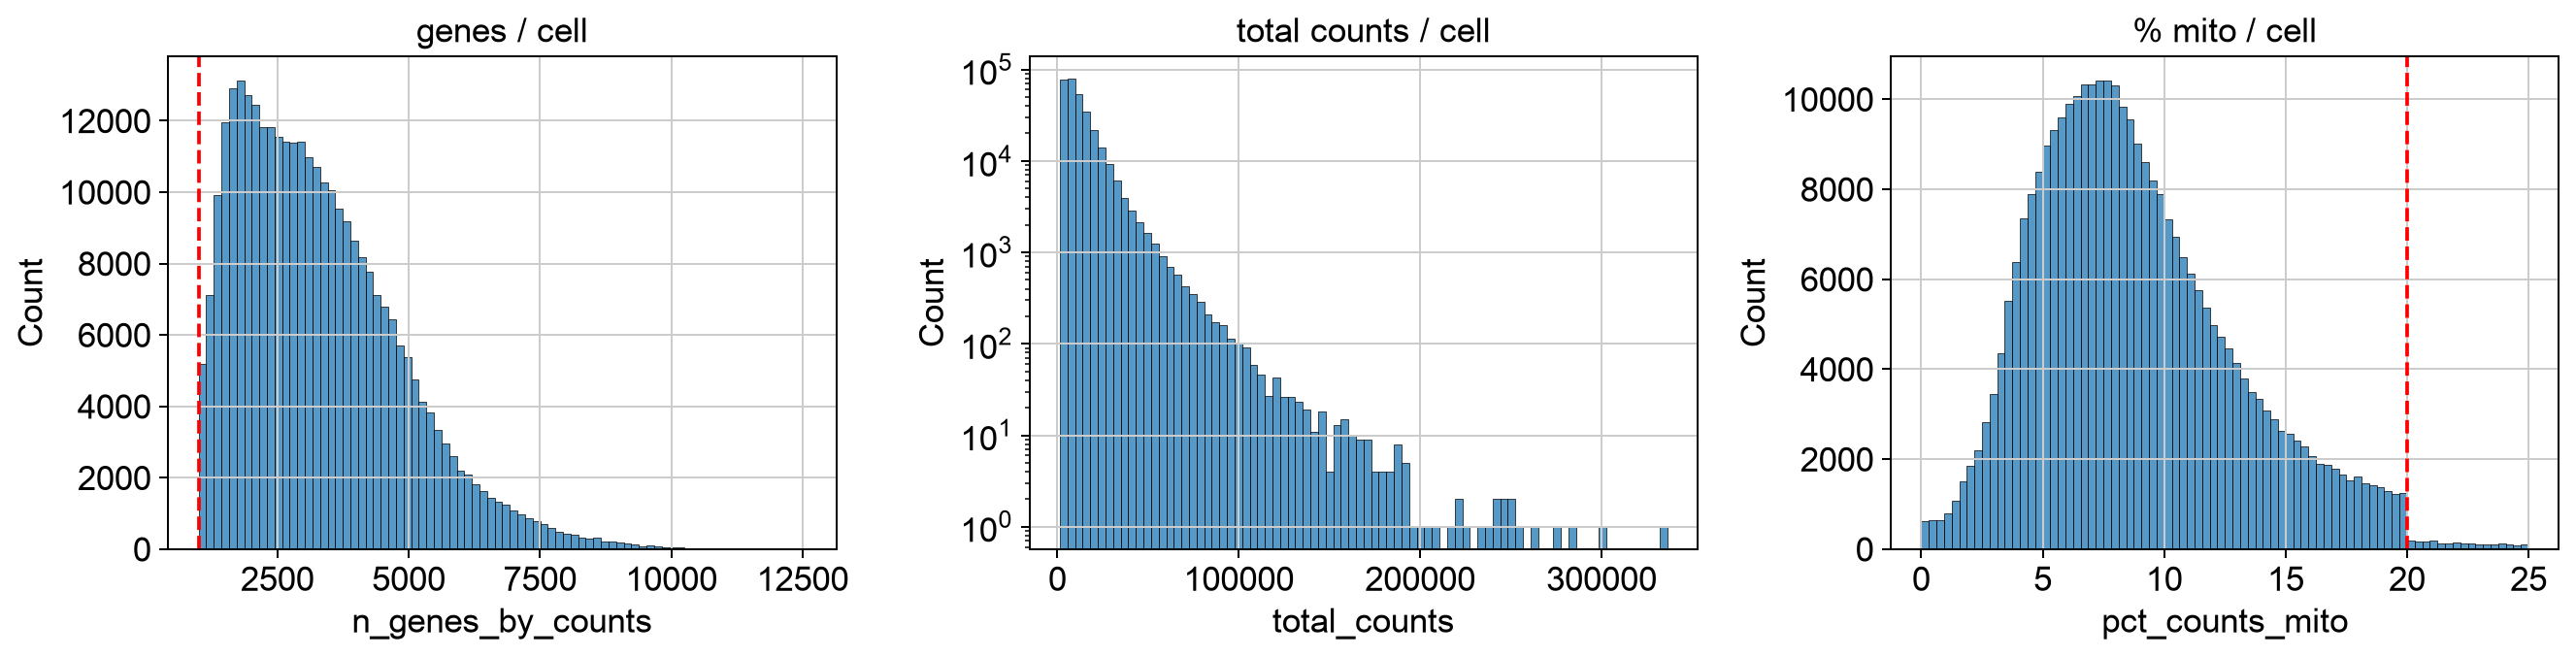

In [7]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(adata.obs["n_genes_by_counts"], bins=80, ax=axs[0]); axs[0].axvline(MIN_GENES, color="r", ls="--"); axs[0].set_title("genes / cell")
sns.histplot(adata.obs["total_counts"], bins=80, ax=axs[1]); axs[1].set_yscale("log"); axs[1].set_title("total counts / cell")
sns.histplot(adata.obs["pct_counts_mito"], bins=80, ax=axs[2]); axs[2].axvline(MAX_PCT_MITO, color="r", ls="--"); axs[2].set_title("% mito / cell")
plt.tight_layout(); plt.show()

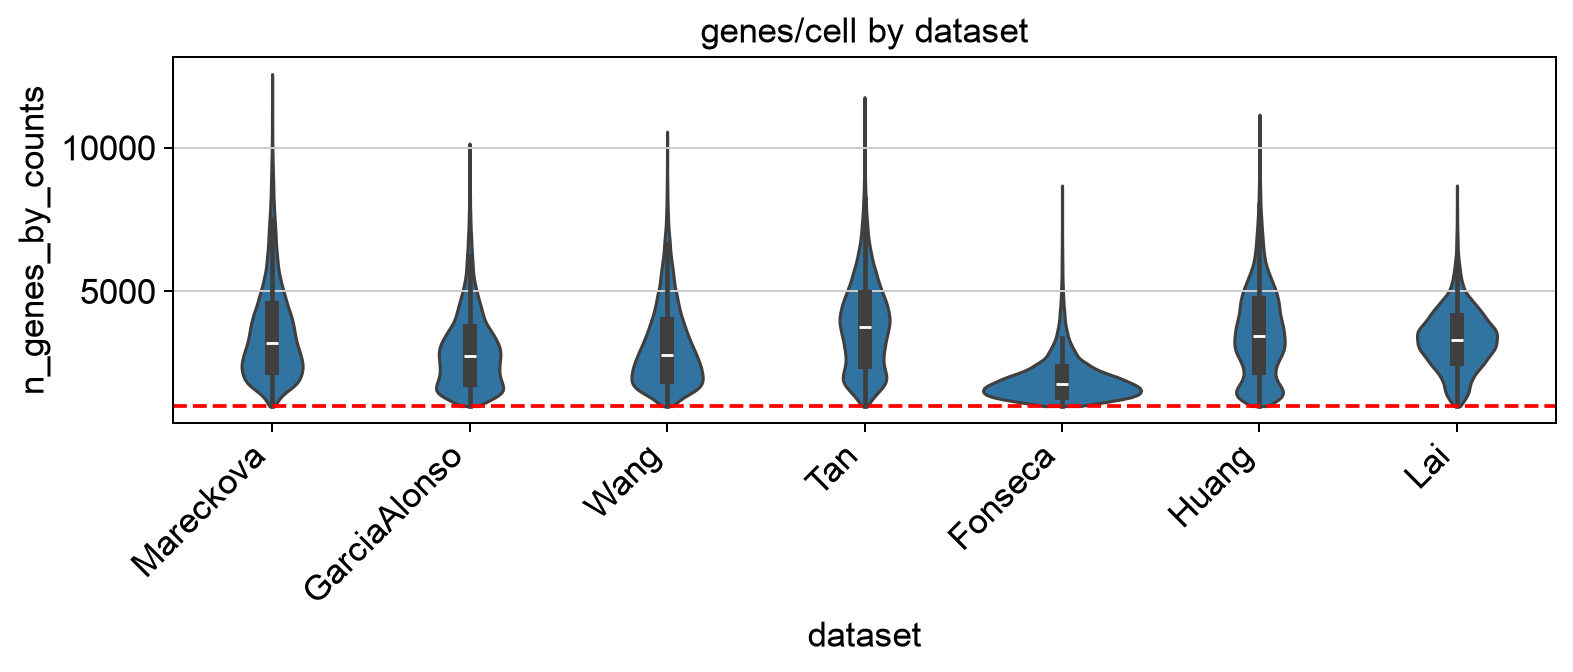

In [8]:
# QC per source dataset - where batch-specific quality problems surface
if DATASET_COL and DATASET_COL in adata.obs.columns:
    fig, ax = plt.subplots(figsize=(9, 4))
    sns.violinplot(data=adata.obs, x=DATASET_COL, y="n_genes_by_counts", ax=ax, cut=0)
    ax.axhline(MIN_GENES, color="r", ls="--"); ax.set_title("genes/cell by dataset"); plt.xticks(rotation=45, ha="right")
    plt.tight_layout(); plt.show()

In [9]:
# QC here is VALIDATION, not re-derivation. The published atlas ships already filtered by the authors
# (per-dataset QC on each dataset's own full gene set), and its scVI integration, embedding and cell
# annotations are all defined on the retained cells. We therefore do NOT re-filter -- we report where
# the shipped object sits relative to the paper's stated thresholds. The QC-provenance cell below shows
# why re-filtering on this object's metrics would not reproduce the authors' QC anyway.
n_low_genes = int((adata.obs["n_genes_by_counts"] < MIN_GENES).sum())
n_high_mito = int((adata.obs["pct_counts_mito"] > MAX_PCT_MITO).sum())
print(f"cells in object:                      {adata.n_obs}")
print(f"below {MIN_GENES} genes (paper floor):   {n_low_genes}  ({100*n_low_genes/adata.n_obs:.2f}%)")
print(f"above {MAX_PCT_MITO:.0f}% mito (paper ceiling): {n_high_mito}  ({100*n_high_mito/adata.n_obs:.2f}%)")
print("Cells are NOT dropped: the object is used as the published reference (validate, do not re-derive).")

cells in object:                      313527
below 1000 genes (paper floor):   0  (0.00%)
above 20% mito (paper ceiling): 2094  (0.67%)
Cells are NOT dropped: the object is used as the published reference (validate, do not re-derive).


### QC flag: the paper's stated thresholds vs the final, published object

The Methods (Mareckova et al. 2024, p. 15) state cells were excluded if they expressed fewer than 1,000 genes or had **mitochondrial content higher than 20%**, applied per dataset on each dataset's full gene set. Two facts about the distributed object are worth documenting, because they are why this notebook validates QC rather than re-deriving it:

1. The released object's `percent_mito` is **hard-capped at exactly 0.25 (25%)**, not 20%. Whatever the Methods text says, the distributed atlas was filtered at 25% mito.
2. The object ships only the **harmonized 17,736-gene intersection**, a smaller number of genes total than the per-dataset sets QC used. Metrics recomputed from these counts are systematically stricter (they undercount genes and inflate mito%) and reproduce **neither** stated threshold.

Together these mean the QC metric we could compute here is not the metric the authors filtered on, so re-filtering would drop cells the reference kept. The cell below shows the evidence.

In [10]:
# Evidence for the QC-provenance note above.
_mito_pct = adata.obs["pct_counts_mito"]     # percent scale (set in the QC cell); shipped raw value is this/100
print("Shipped .obs QC metrics (authors' per-dataset values, carried into the object):")
print(f"  n_genes: min = {adata.obs['n_genes_by_counts'].min():.0f}   (paper floor: 1000)")
print(f"  mito:    max = {_mito_pct.max():.2f}% = fraction {_mito_pct.max()/100:.4f}   "
      f"(paper states 20%; object hard-capped at 25%)\n")

# Recompute n_genes and mito from the shipped 17,736-gene counts and compare to the stored metrics.
rng = np.random.default_rng(SEED); idx = np.sort(rng.choice(adata.n_obs, 3000, replace=False))
Cqc = fetch_counts(adata[idx]); Cqc = Cqc.toarray() if hasattr(Cqc, "toarray") else np.asarray(Cqc)
mt = np.where(adata.var_names.str.upper().str.startswith("MT-"))[0]
rc_ngenes = (Cqc > 0).sum(1); rc_mito = Cqc[:, mt].sum(1) / Cqc.sum(1)
sh_ngenes = adata.obs["n_genes_by_counts"].values[idx]
sh_mito   = _mito_pct.values[idx] / 100.0
print("Recomputed from the harmonized 17,736-gene counts vs shipped .obs (n=3000 cells):")
print(f"  n_genes: recomputed < shipped for {100*(rc_ngenes < sh_ngenes).mean():.0f}% of cells; "
      f"median deficit {np.median(sh_ngenes - rc_ngenes):.0f} genes/cell  (deflates n_genes)")
print(f"  mito:    recomputed > shipped for {100*(rc_mito > sh_mito).mean():.0f}% of cells; "
      f"median excess {np.median(rc_mito - sh_mito):.4f} fraction  (inflates mito%)")
print("\n=> The harmonized object cannot reproduce the authors' per-dataset QC, and its stored mito is")
print("   capped at 25% not 20%. QC here is validation of a published reference; cells are not re-dropped.")

Shipped .obs QC metrics (authors' per-dataset values, carried into the object):
  n_genes: min = 1000   (paper floor: 1000)
  mito:    max = 25.00% = fraction 0.2500   (paper states 20%; object hard-capped at 25%)



Recomputed from the harmonized 17,736-gene counts vs shipped .obs (n=3000 cells):
  n_genes: recomputed < shipped for 100% of cells; median deficit 139 genes/cell  (deflates n_genes)
  mito:    recomputed > shipped for 100% of cells; median excess 0.0020 fraction  (inflates mito%)

=> The harmonized object cannot reproduce the authors' per-dataset QC, and its stored mito is
   capped at 25% not 20%. QC here is validation of a published reference; cells are not re-dropped.


**Normalization.** Preserve raw counts (needed later for pseudobulk differential expression), then normalize to a common depth and log-transform for visualization and marker work. The reference used scVI on the counts for the *integration* embedding; that embedding, if shipped in `.obsm`, is reused rather than recomputed. Re-running scVI on 313K cells is neither necessary nor a good use of the time budget when the integrated manifold already exists.

In [11]:
if BACKED:
    # Full atlas: X is already the authors' log-normalized matrix and raw counts stay on disk
    # (streamed via fetch_counts). Do not re-normalize, and do not copy counts/lognorm layers
    # into RAM (each would add ~8 GB). Expression work below reads log-norm from .X directly.
    print("BACKED mode: using the shipped log-normalized X; raw counts streamed on demand.")
else:
    # Subset: X holds raw counts. Preserve them, then normalize + log1p for expression work.
    if RAW_COUNTS_LAYER and RAW_COUNTS_LAYER in adata.layers:
        adata.layers["counts"] = adata.layers[RAW_COUNTS_LAYER].copy()
    elif adata.raw is not None and adata.raw.shape[1] == adata.n_vars:
        adata.layers["counts"] = adata.raw.X.copy()
    else:
        # assume .X currently holds counts (integer-like); guard against already-normalized X
        x = adata.X
        xmax = x.max() if not hasattr(x, "toarray") else x[:100].toarray().max()
        if float(xmax) > 30:  # heuristic: looks like counts
            adata.layers["counts"] = adata.X.copy()
        else:
            print("WARNING: could not locate raw counts. Pseudobulk DE needs counts - set RAW_COUNTS_LAYER.")

    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    adata.layers["lognorm"] = adata.X.copy()
    print("normalized and log1p done; raw counts preserved in .layers['counts'].")

BACKED mode: using the shipped log-normalized X; raw counts streamed on demand.


In [12]:
# HVGs (Seurat v3 flavor works on raw counts), for any recompute of embeddings.
if BACKED:
    # Full atlas: raw counts are not held in RAM and the shipped scVI/UMAP embedding is reused,
    # so HVG selection is not needed. (The immune re-clustering in 4b computes its own HVGs.)
    print("BACKED mode: skipping whole-atlas HVG (shipped embedding is reused downstream).")
else:
    try:
        sc.pp.highly_variable_genes(adata, n_top_genes=N_HVG, flavor="seurat_v3", layer="counts")
    except Exception as e:
        print("seurat_v3 HVG failed (", e, ") - falling back to default flavor on lognorm.")
        sc.pp.highly_variable_genes(adata, n_top_genes=N_HVG)
    print("HVGs:", int(adata.var['highly_variable'].sum()))

BACKED mode: skipping whole-atlas HVG (shipped embedding is reused downstream).


## 4. Cell type annotation

Two complementary passes:

- **4a. Validate the atlas annotations** against canonical and paper-defined markers. Trust, but verify.
- **4b. De novo re-annotation of the immune compartment** from raw counts, to demonstrate the full clustering-and-annotation workflow rather than only consuming shipped labels, and because the immune compartment (macrophages) is where the disease argument lives, so its annotation needs to be independently defensible.

The marker panel below is drawn directly from the paper's cell-state definitions plus standard lineage markers.

In [13]:
MARKERS = {
    # ---- lineage ----
    "Epithelial":        ["EPCAM", "KRT8", "KRT18", "CDH1"],
    "Stromal/Fibroblast":["PDGFRB", "DCN", "LUM", "COL6A3"],
    "Endothelial":       ["PECAM1", "VWF", "CLDN5"],
    "Perivascular":      ["ACTA2", "NOTCH3", "RGS5", "MYH11"],
    "Immune":            ["PTPRC"],
    # ---- epithelial states ----
    "SOX9 basalis (CDH2+)": ["SOX9", "CDH2", "AXIN2", "ALDH1A1"],
    "Luminal (LGR5+)":      ["LGR5"],
    "Ciliated":             ["FOXJ1", "PIFO", "TP73"],
    "preGlandular":         ["OPRK1", "CBR3", "SUFU", "HPRT1"],
    "preLuminal":           ["SULT1E1"],
    "MUC5B (likely cervical)": ["MUC5B", "TFF3", "SAA1", "BPIFB1"],
    # ---- stromal states ----
    "eStromal MMPs":     ["MMP1", "MMP10", "MMP3", "INHBA"],
    "dStromal early":    ["PLCL1"],
    "dStromal mid":      ["DKK1"],
    "dStromal late":     ["LEFTY2", "SMAD7"],
    # ---- immune states ----
    "uNK (NK)":          ["NCAM1", "KLRD1", "NKG7", "GNLY"],
    "Macrophage (uM)":   ["CD68", "CD14", "LYZ", "C1QA", "C1QB"],
    "uM1 (pro-inflamm.)":["IL1B", "EREG", "TNF"],
    "uM2 (anti-inflamm./TRM)": ["HMOX1", "FOLR2", "LYVE1"],
    "T cell":            ["CD3D", "CD3E", "CD8A"],
    "DC":                ["CLEC9A", "CD1C", "LILRA4"],
    "Mast":              ["TPSAB1", "CPA3", "MS4A2"],
    "B/Plasma":          ["MS4A1", "CD79A", "MZB1"],
}

def present(genes):
    return [g for g in genes if g in adata.var_names]


### 4a. Validate the shipped annotations

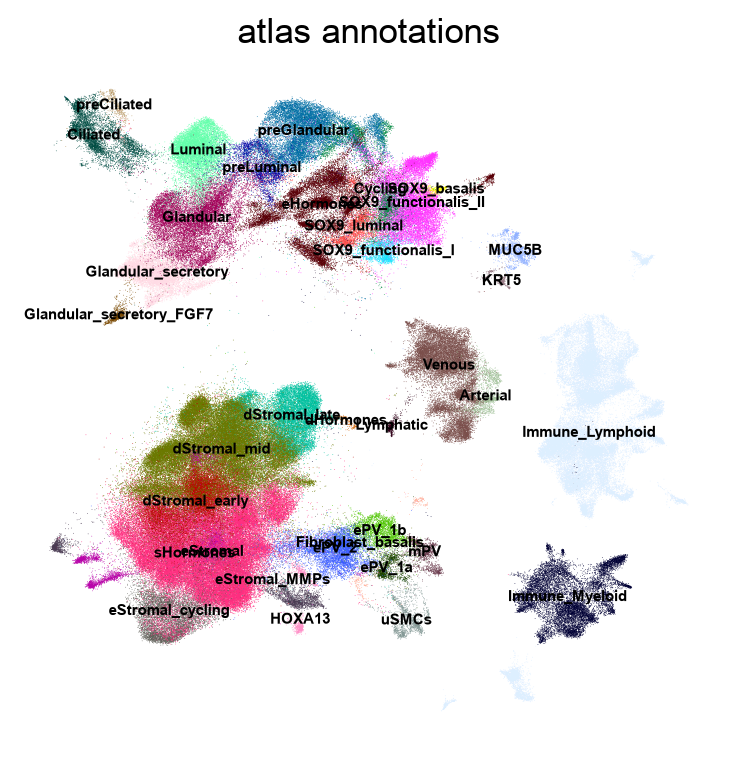

In [14]:
# UMAP: reuse the integrated embedding if present, else compute from HVGs
if "X_umap" not in adata.obsm:
    rep = "X_scVI" if "X_scVI" in adata.obsm else ("X_pca" if "X_pca" in adata.obsm else None)
    if rep is None:
        sc.pp.pca(adata, n_comps=50, use_highly_variable=True); rep = "X_pca"
    sc.pp.neighbors(adata, use_rep=rep, random_state=SEED)
    sc.tl.umap(adata, random_state=SEED)

if CELLTYPE_COL in adata.obs.columns:
    sc.pl.umap(adata, color=CELLTYPE_COL, legend_loc="on data", legend_fontsize=6, title="atlas annotations")

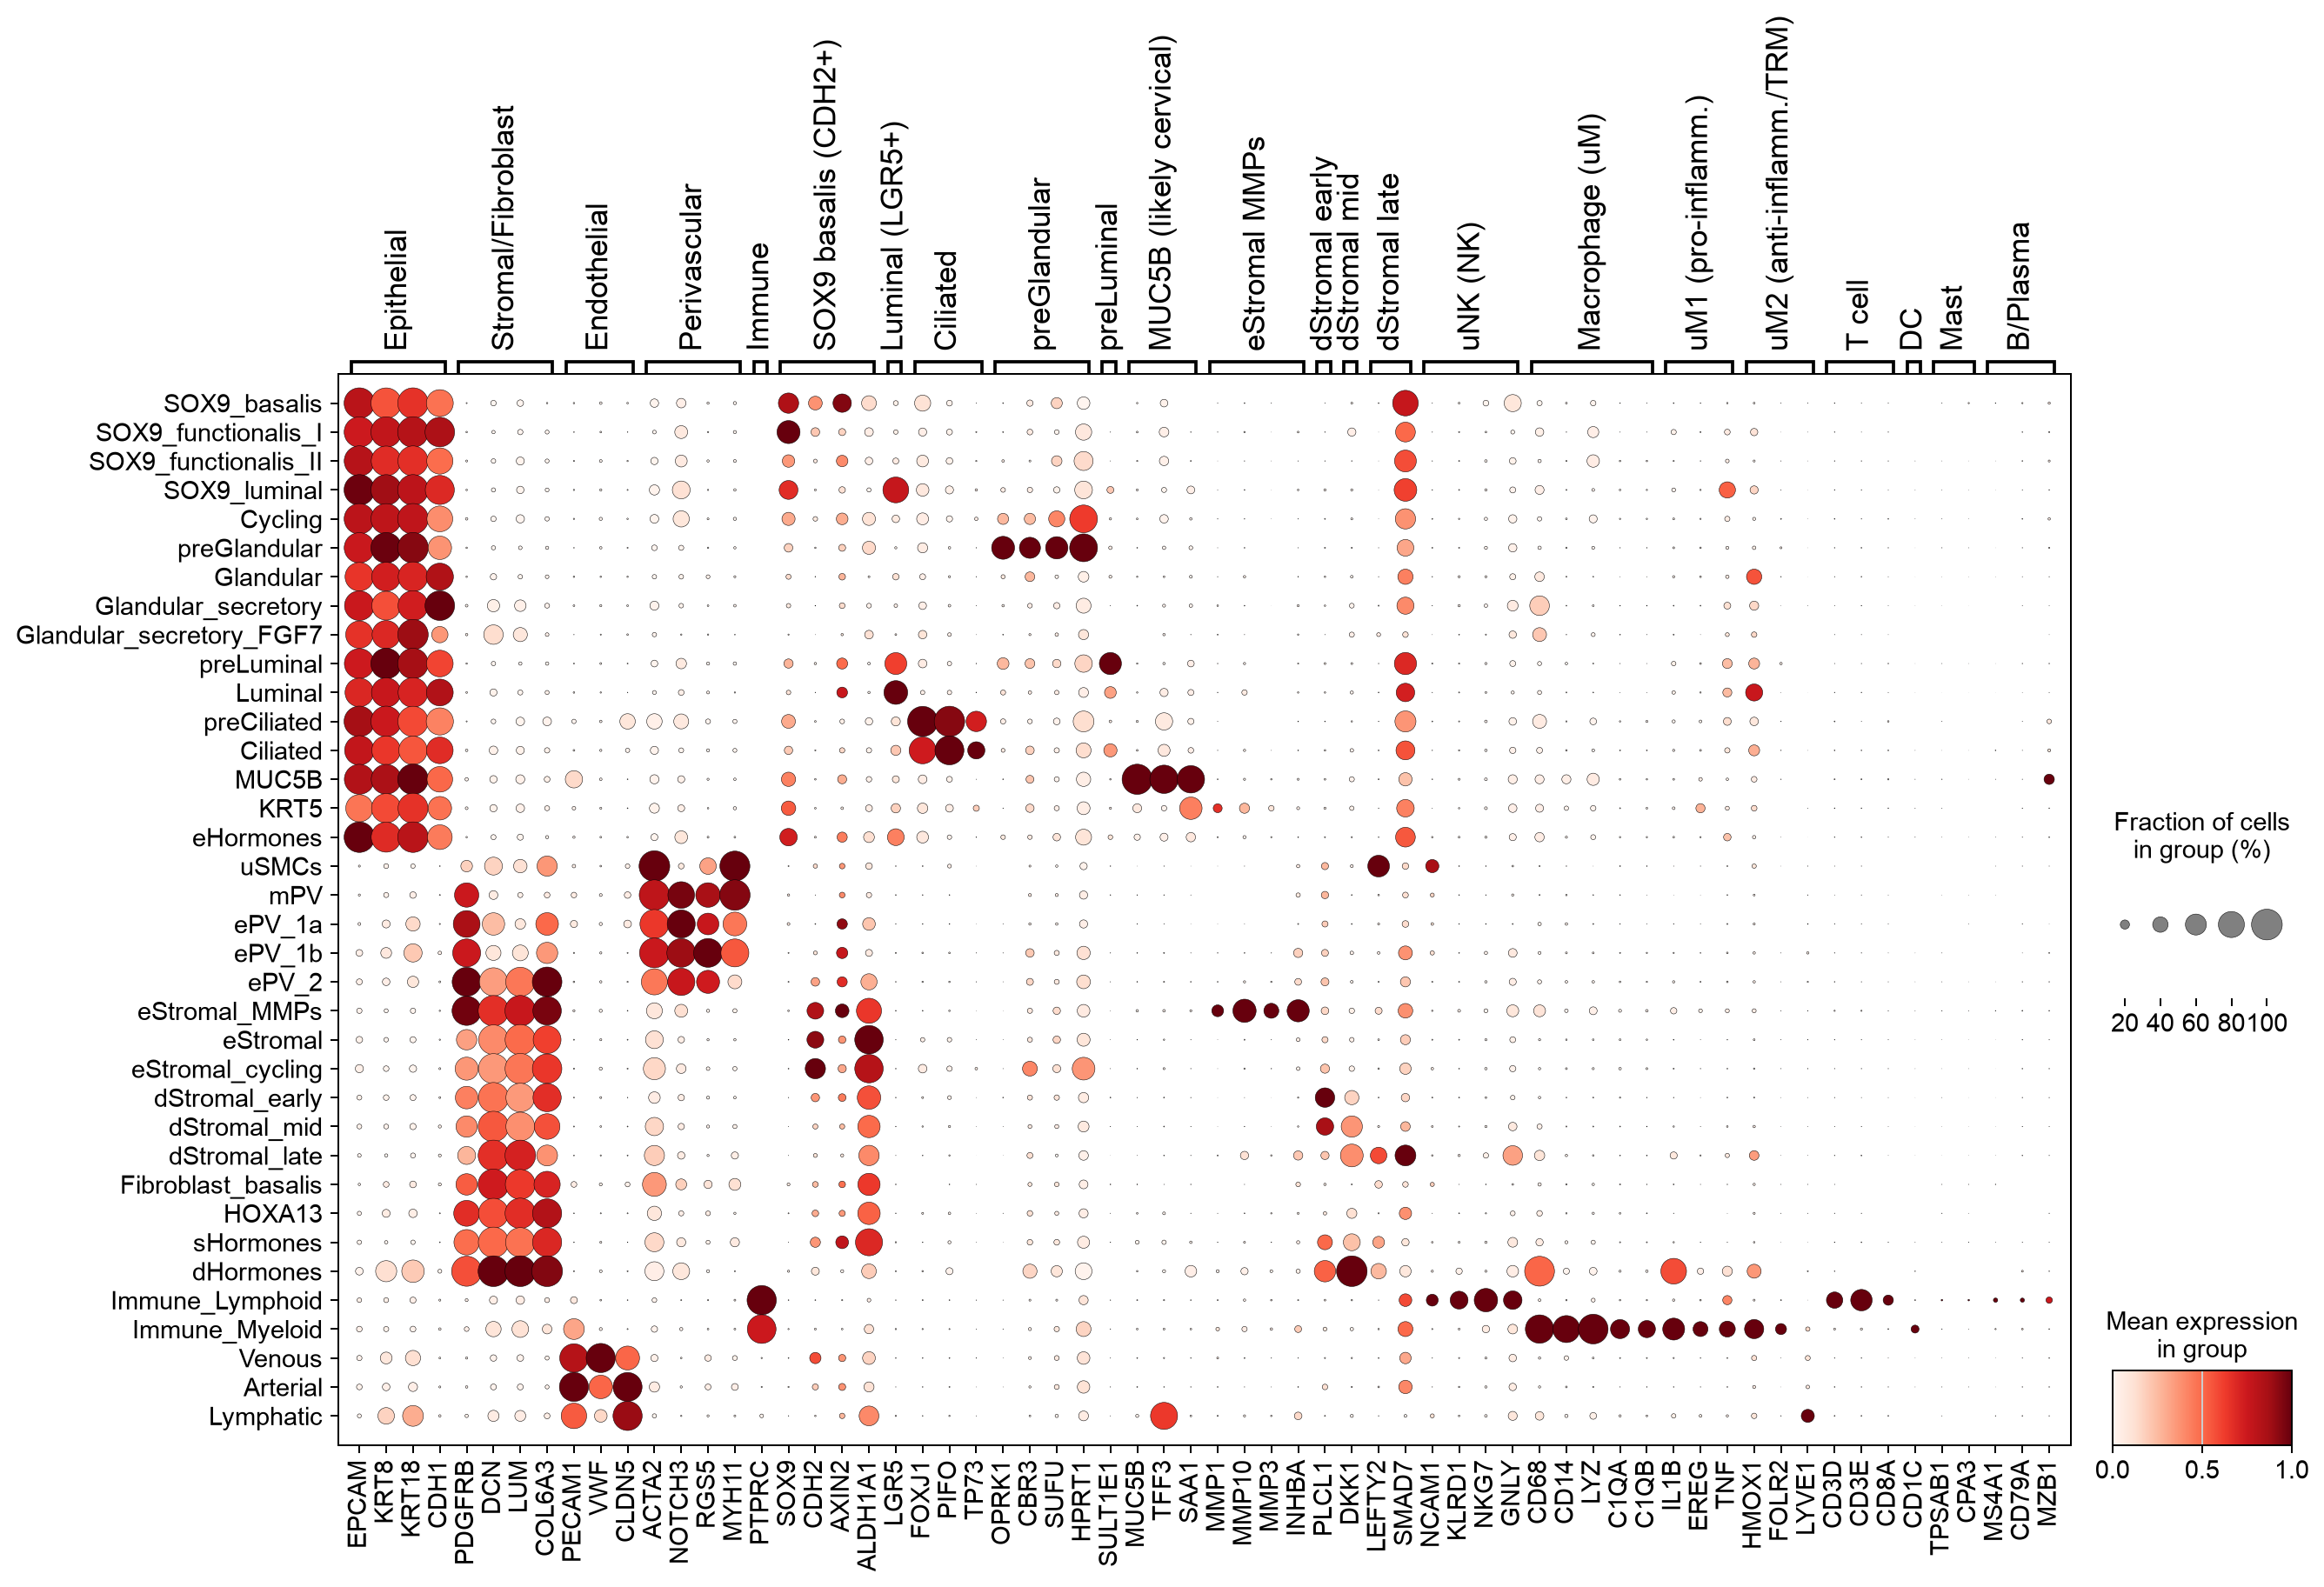

In [15]:
# marker dotplot across the shipped annotations - do the labels express their canonical markers?
if CELLTYPE_COL in adata.obs.columns:
    flat = {k: present(v) for k, v in MARKERS.items()}
    flat = {k: v for k, v in flat.items() if v}
    sc.pl.dotplot(adata, flat, groupby=CELLTYPE_COL, standard_scale="var",
                  dendrogram=False, figsize=(16, max(4, adata.obs[CELLTYPE_COL].nunique()*0.25)))

In [16]:
# lineage confidence via signature scoring (independent of the shipped labels)
for lin in ["Epithelial", "Stromal/Fibroblast", "Endothelial", "Perivascular", "Immune"]:
    g = present(MARKERS[lin])
    if g:
        sc.tl.score_genes(adata, g, score_name=f"score_{lin}")
score_cols = [c for c in adata.obs.columns if c.startswith("score_")]
if CELLTYPE_COL in adata.obs.columns and score_cols:
    display(adata.obs.groupby(CELLTYPE_COL)[score_cols].mean().round(2))

,score_Epithelial,score_Stromal/Fibroblast,score_Endothelial,score_Perivascular,score_Immune
celltype,,,,,
SOX9_basalis,1.00,-0.83,-0.10,-0.15,-0.29
SOX9_functionalis_I,1.27,-0.90,-0.12,-0.19,-0.33
SOX9_functionalis_II,1.05,-0.86,-0.11,-0.16,-0.34
SOX9_luminal,1.37,-0.92,-0.12,-0.17,-0.40
Cycling,1.11,-0.92,-0.14,-0.19,-0.37
preGlandular,1.29,-0.90,-0.13,-0.20,-0.33
Glandular,1.16,-0.74,-0.09,-0.18,-0.32
Glandular_secretory,1.18,-0.74,-0.09,-0.17,-0.35
Glandular_secretory_FGF7,1.16,-0.50,-0.05,-0.13,-0.25


**Cross-validation against an independent panel (Fonseca et al. 2023).** The dot plot and scores above use the reference's own markers plus canonical lineage genes. As an independent check, the panel below uses the major-cell-type markers from Fonseca et al. (*Nat Genet* 2023), Methods ("Identification of major cell types and epithelial subgroups"), a separate large endometriosis single-cell study. Concordance with a second lab's panel (epithelial keratins in the epithelial states, DCN/PDGFR/collagens in the stroma, LYZ/C1QA/MME in myeloid, CLDN5/PECAM1/CD34 in endothelial, CD2/CD3/CD8A in T cells, TYROBP/FCGR3A in NK, and so on) is stronger support for the shipped labels than any single panel. All of Fonseca's markers are present in the harmonized 17,736-gene space.

all Fonseca major-cell-type markers present in the harmonized gene set


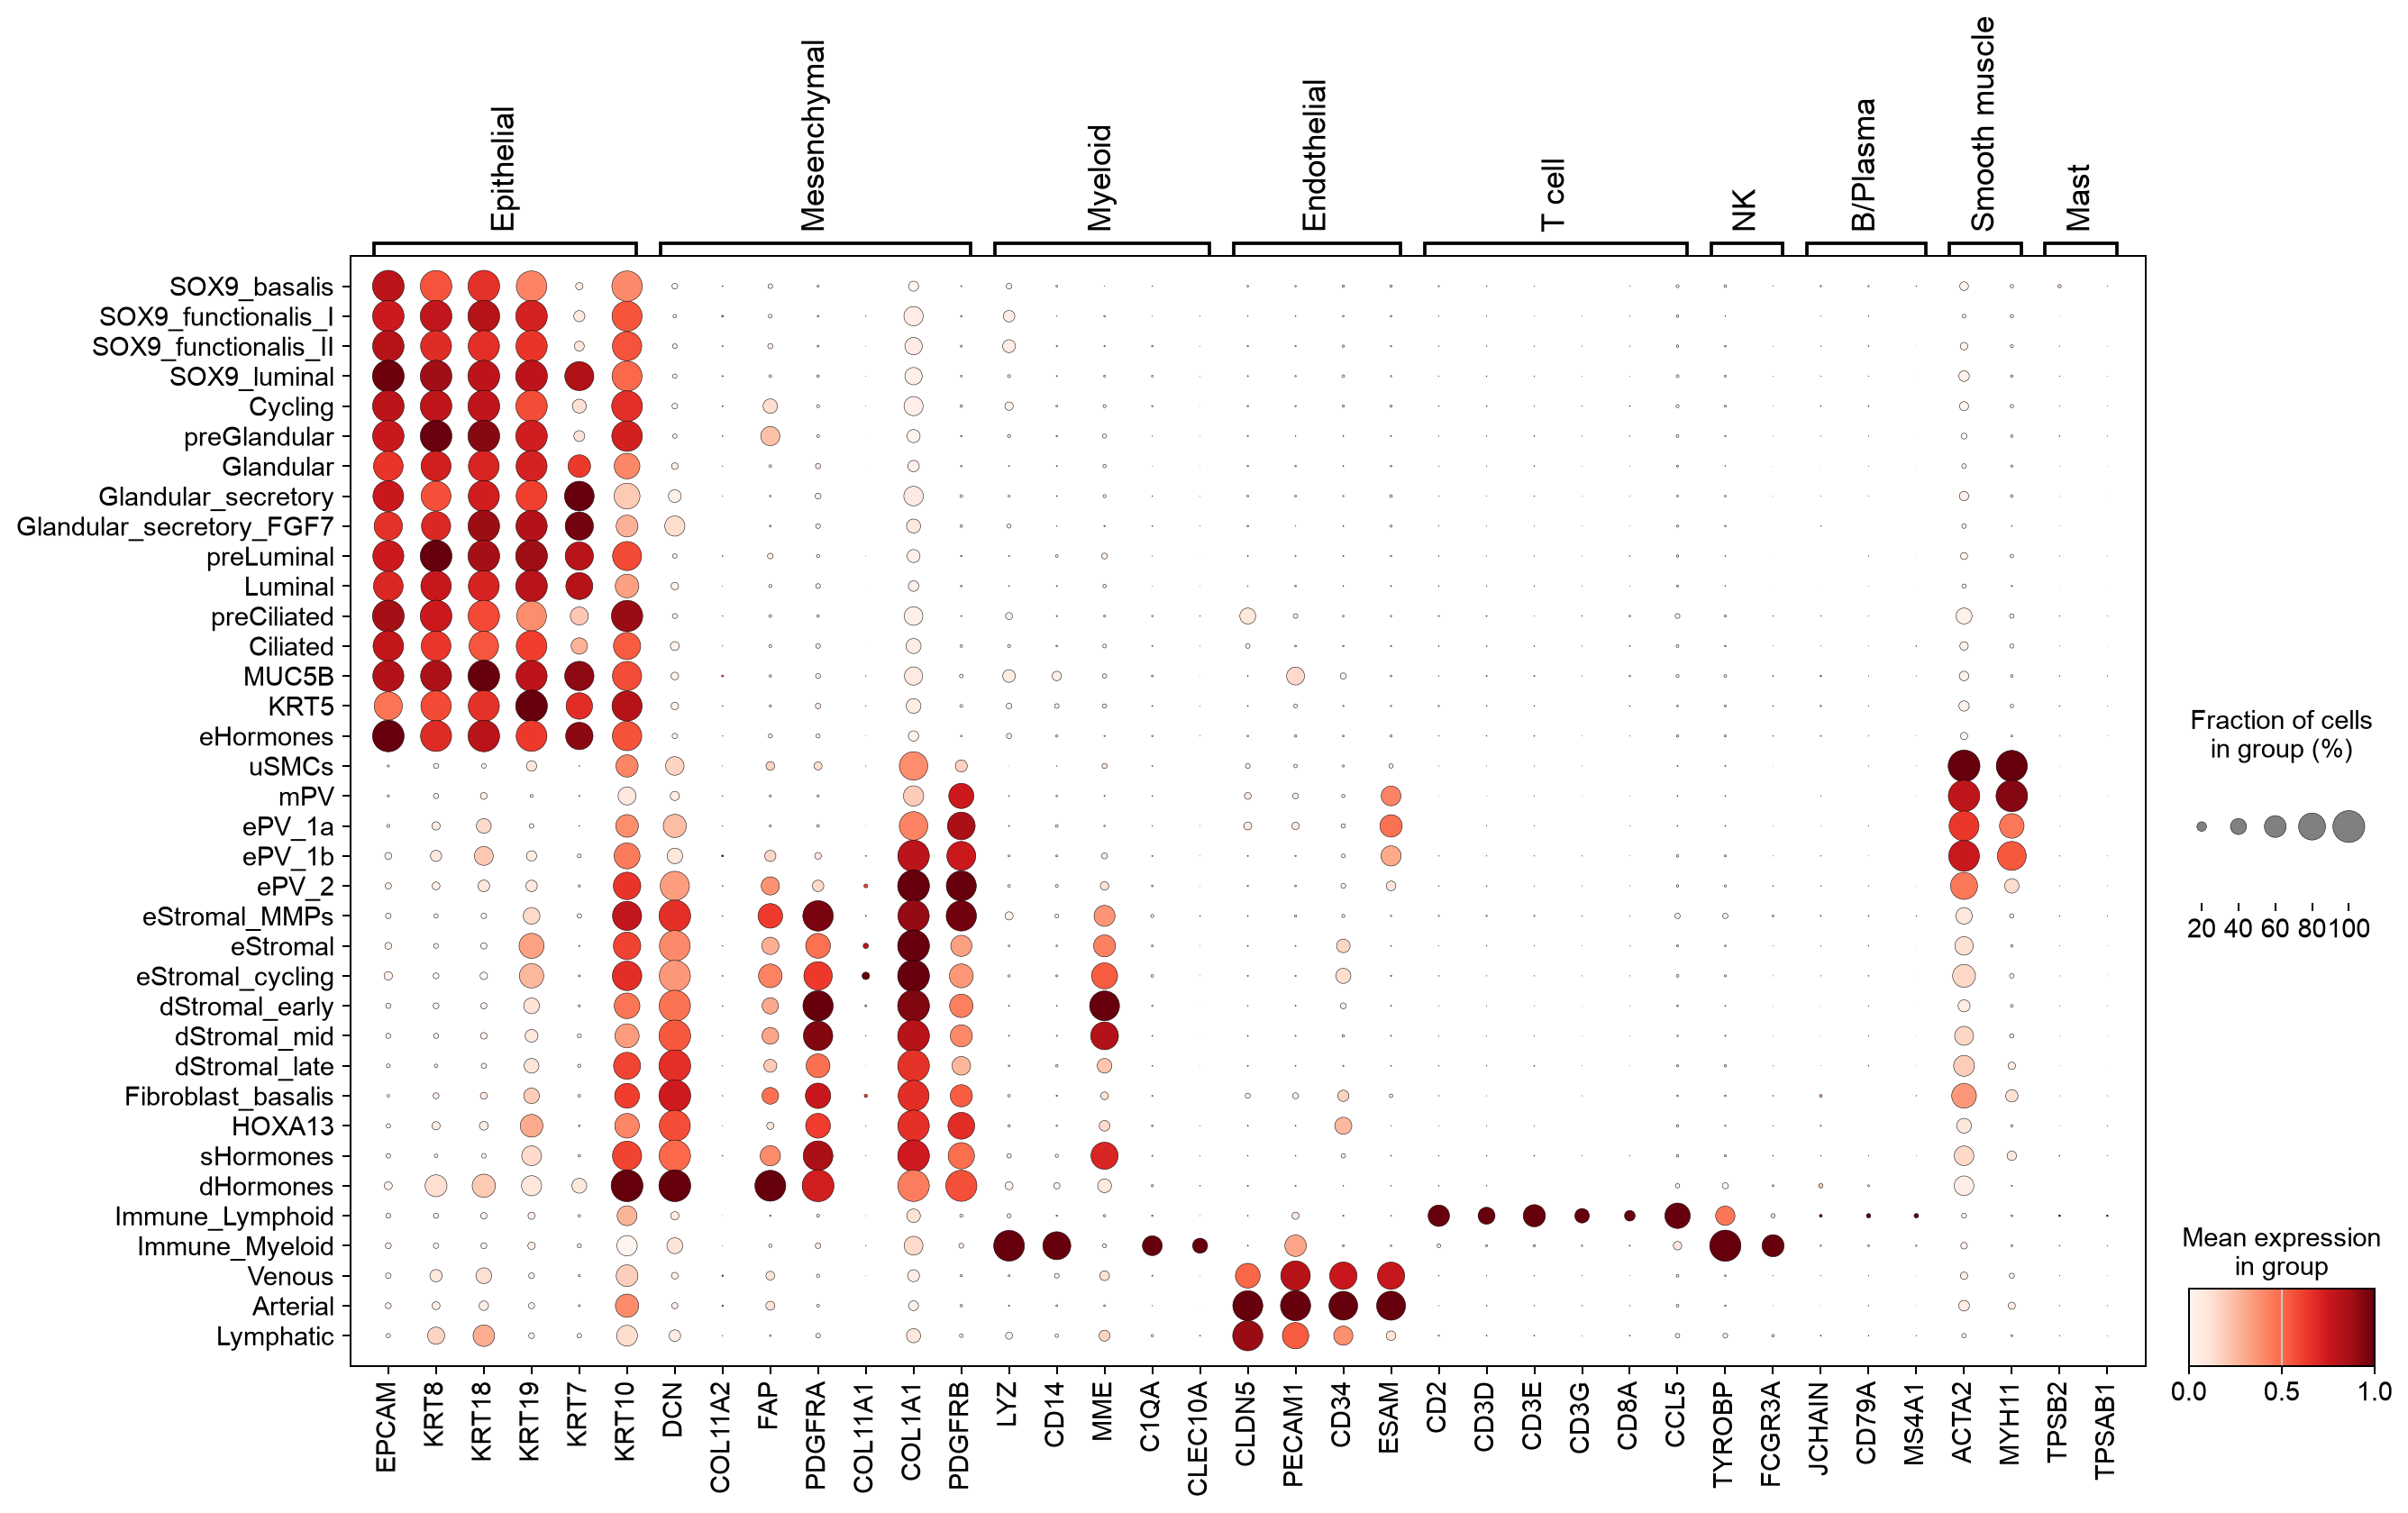

In [17]:
# Fonseca et al. 2023 major-cell-type markers (Methods). Expression across the shipped fine labels:
# each panel should light up in the matching lineage/state, cross-validating the annotation.
FONSECA_MARKERS = {
    "Epithelial":    ["EPCAM","KRT8","KRT18","KRT19","KRT7","KRT10"],
    "Mesenchymal":   ["DCN","COL11A2","FAP","PDGFRA","COL11A1","COL1A1","PDGFRB"],
    "Myeloid":       ["LYZ","CD14","MME","C1QA","CLEC10A"],
    "Endothelial":   ["CLDN5","PECAM1","CD34","ESAM"],
    "T cell":        ["CD2","CD3D","CD3E","CD3G","CD8A","CCL5"],
    "NK":            ["TYROBP","FCGR3A"],
    "B/Plasma":      ["JCHAIN","CD79A","MS4A1"],
    "Smooth muscle": ["ACTA2","MYH11"],
    "Mast":          ["TPSB2","TPSAB1"],
}
FONSECA_MARKERS = {k: [g for g in v if g in adata.var_names] for k, v in FONSECA_MARKERS.items()}
_absent = {k: [g for g in v if g not in adata.var_names] for k, v in FONSECA_MARKERS.items()}
_absent = {k: v for k, v in _absent.items() if v}
if _absent:
    print("Fonseca markers absent from the harmonized gene set:", _absent)
else:
    print("all Fonseca major-cell-type markers present in the harmonized gene set")
sc.pl.dotplot(adata, FONSECA_MARKERS, groupby=CELLTYPE_COL, standard_scale="var",
              figsize=(16, 9), show=True)

### 4b. De novo re-annotation of the immune compartment

In [18]:
# subset to immune cells (by shipped lineage if available, else by PTPRC signature / label match)
if LINEAGE_COL and LINEAGE_COL in adata.obs.columns:
    imm_mask = adata.obs[LINEAGE_COL].astype(str).str.contains("immune", case=False, na=False)
elif CELLTYPE_COL in adata.obs.columns:
    imm_terms = ("uM", "uNK", "NK", "macro", "T cell", "Tcell", "DC", "mast", "B cell", "plasma", "ILC", "lymph", "myeloid")
    imm_mask = adata.obs[CELLTYPE_COL].astype(str).str.contains("|".join(imm_terms), case=False, na=False)
else:
    imm_mask = adata[:, "PTPRC"].to_df()["PTPRC"] > 0

imm = adata[imm_mask].copy()
print("immune cells:", imm.n_obs)

immune cells: 45716


harmony batch correction on 'dataset' (7 datasets)


de novo immune clusters: 25


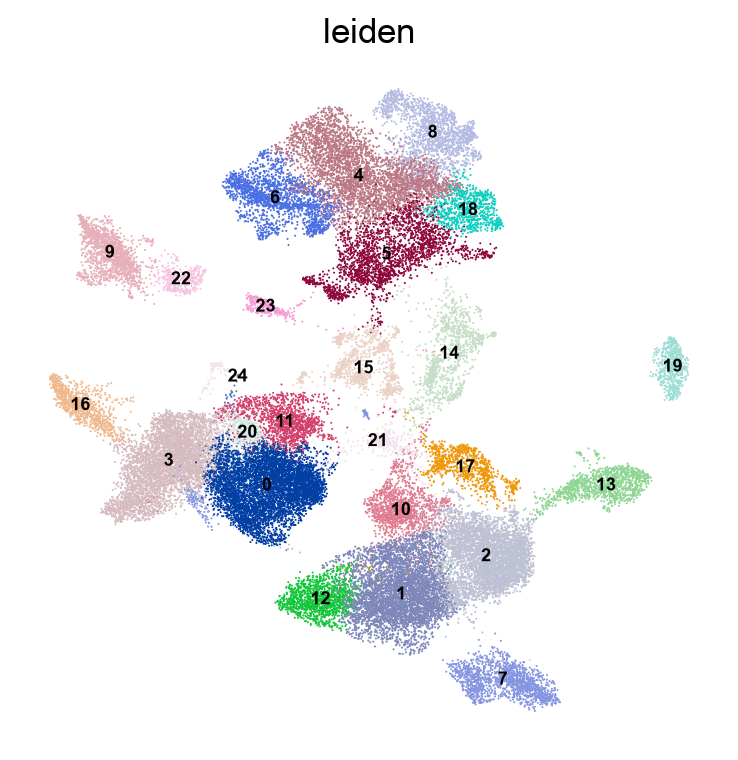

In [19]:
# renormalized, independent clustering of the immune subset from raw counts
imm.layers["counts"] = fetch_counts(imm)   # in-memory layer (subset) or streamed from disk (full atlas)
imm.X = imm.layers["counts"].copy()
imm.uns.pop("log1p", None)                 # imm inherited adata's log1p flag; reset before re-logging from counts
sc.pp.normalize_total(imm, target_sum=1e4); sc.pp.log1p(imm)
sc.pp.highly_variable_genes(imm, n_top_genes=2000)
imm_hvg = imm[:, imm.var["highly_variable"]].copy()
sc.pp.scale(imm_hvg, max_value=10)
sc.pp.pca(imm_hvg, n_comps=30, random_state=SEED)

# Batch-aware embedding across the source datasets. We call harmonypy directly rather than
# sc.external.pp.harmony_integrate: the scanpy wrapper is not compatible with harmonypy 2.0.
# NOTE: harmonypy 2.0 returns Z_corr already oriented as (n_cells x n_pcs) - unlike the old
# 0.0.x API which returned (n_pcs x n_cells) - so it is assigned to .obsm without transposing.
if DATASET_COL and DATASET_COL in imm_hvg.obs.columns and imm_hvg.obs[DATASET_COL].nunique() > 1:
    import harmonypy
    ho = harmonypy.run_harmony(imm_hvg.obsm["X_pca"], imm_hvg.obs, [DATASET_COL],
                               random_state=SEED, verbose=False)
    imm_hvg.obsm["X_pca_harmony"] = np.asarray(ho.Z_corr, dtype="float32")
    rep = "X_pca_harmony"
    print(f"harmony batch correction on '{DATASET_COL}' ({imm_hvg.obs[DATASET_COL].nunique()} datasets)")
else:
    rep = "X_pca"

sc.pp.neighbors(imm_hvg, use_rep=rep, random_state=SEED)
sc.tl.leiden(imm_hvg, resolution=1.0, random_state=SEED)
sc.tl.umap(imm_hvg, random_state=SEED)
imm.obs["leiden"] = imm_hvg.obs["leiden"].values
imm.obsm["X_umap"] = imm_hvg.obsm["X_umap"]
print("de novo immune clusters:", imm.obs["leiden"].nunique())
sc.pl.umap(imm, color="leiden", legend_loc="on data", legend_fontsize=7)

categories: 0, 1, 2, etc.
var_group_labels: uNK (NK), Macrophage (uM), uM1 (pro-inflamm.), etc.


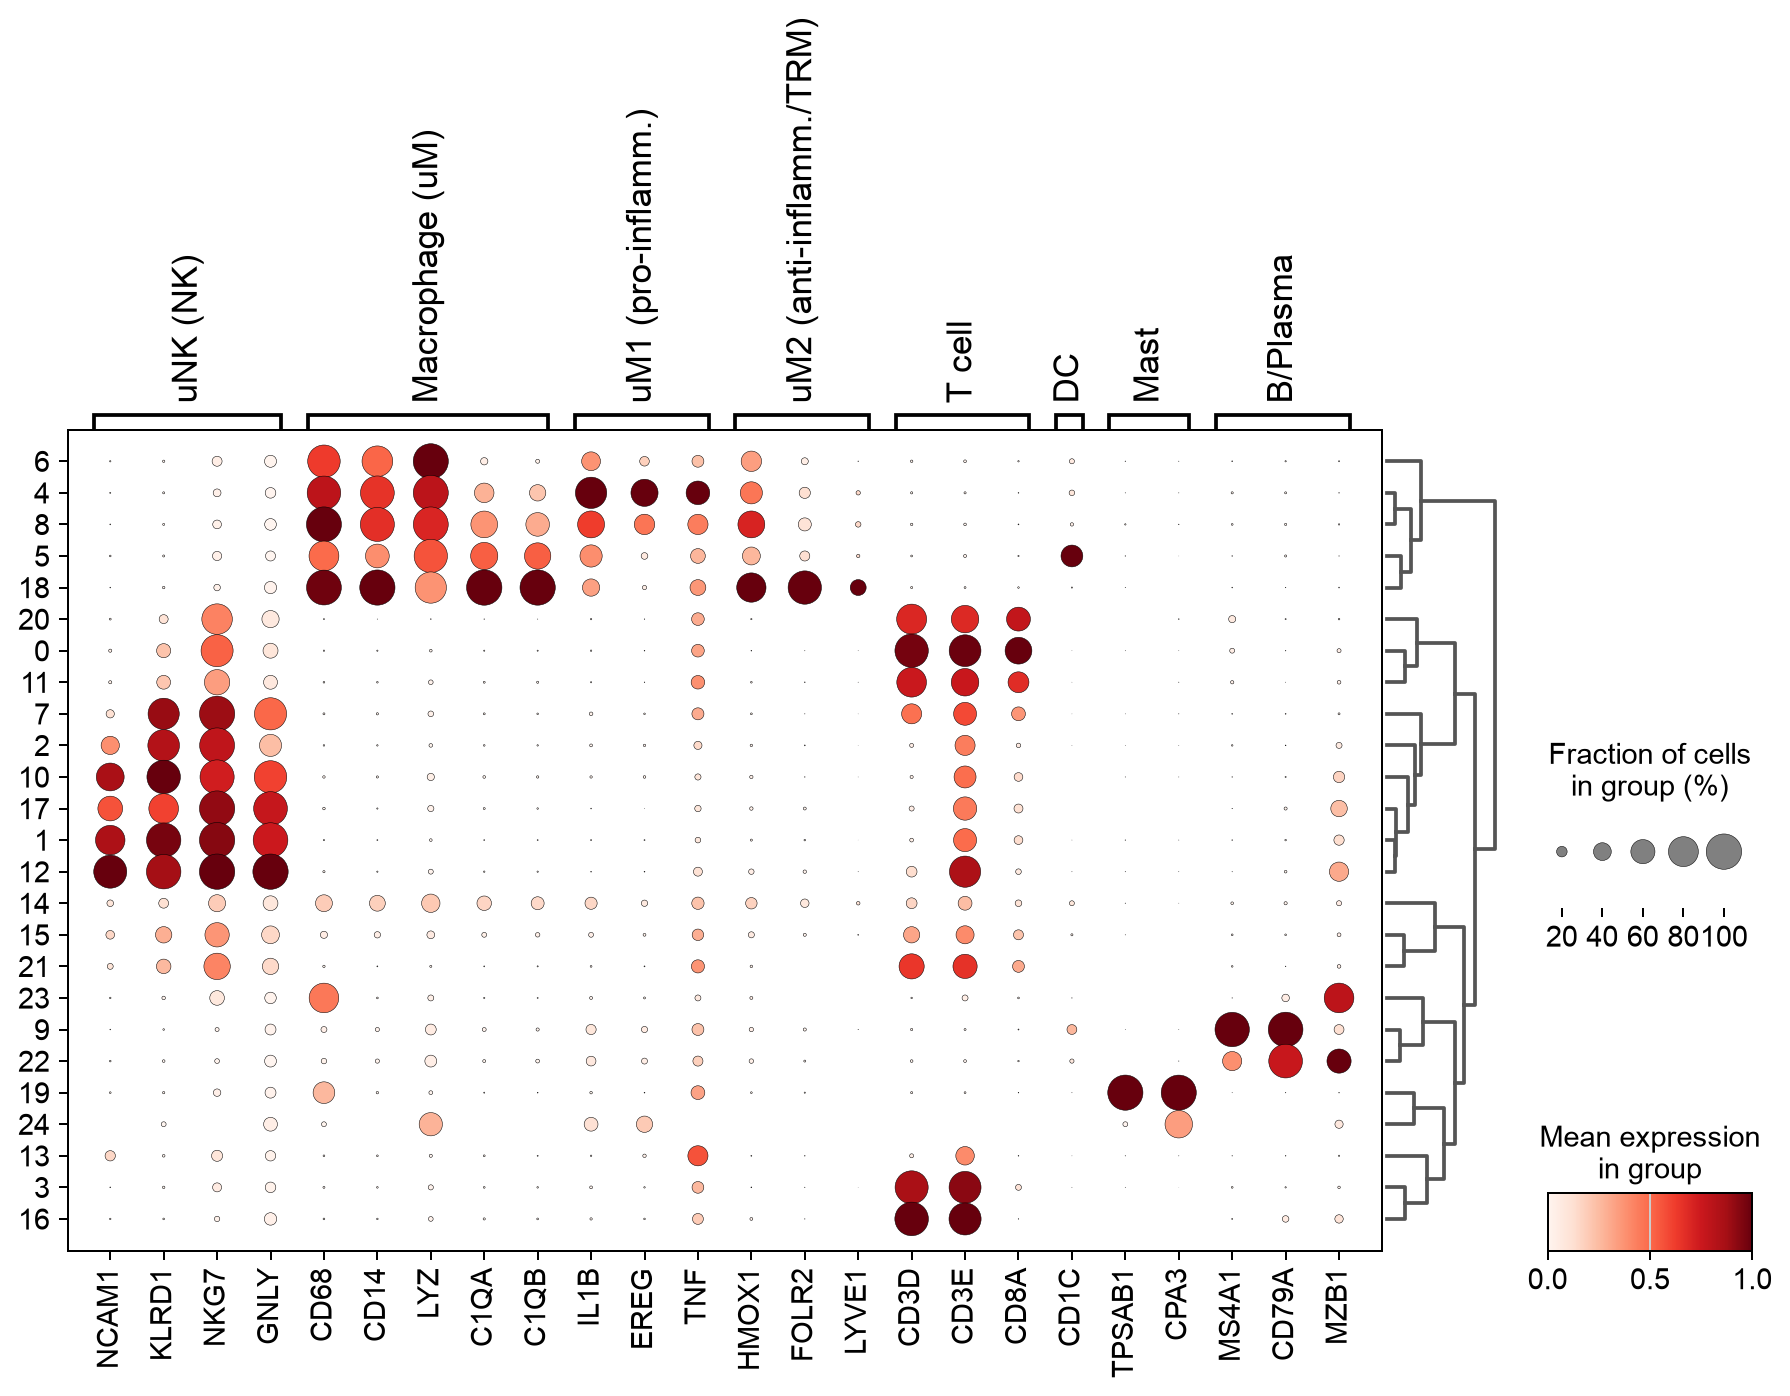

In [20]:
# annotate immune clusters by marker expression
imm_panel = {k: present(v) for k, v in MARKERS.items()
             if k in ["Macrophage (uM)", "uM1 (pro-inflamm.)", "uM2 (anti-inflamm./TRM)",
                      "uNK (NK)", "T cell", "DC", "Mast", "B/Plasma"]}
imm_panel = {k: v for k, v in imm_panel.items() if v}
sc.pl.dotplot(imm, imm_panel, groupby="leiden", standard_scale="var", dendrogram=True, figsize=(12, 6))

In [21]:
# Label clusters in two tiers. A single argmax over all panels fails here because the abundant
# pan-macrophage markers (CD68/CD14/LYZ) outscore the sparser uM1/uM2 subset markers, collapsing
# the split we need. So:
#   tier 1 -- coarse identity by argmax over the coarse panels only (macrophage / NK / T / DC / mast / B)
#   tier 2 -- within macrophage clusters, split uM1 vs uM2 by whichever subset score is higher
# This mirrors the paper's definition of uM1/uM2 as macrophage substates rather than separate lineages.
for name, g in imm_panel.items():
    if g: sc.tl.score_genes(imm, g, score_name=f"s::{name}")
S = imm.obs.groupby("leiden")[[f"s::{k}" for k in imm_panel]].mean()
S.columns = [c.replace("s::", "") for c in S.columns]

MAC, UM1, UM2 = "Macrophage (uM)", "uM1 (pro-inflamm.)", "uM2 (anti-inflamm./TRM)"
coarse_panels = [MAC, "uNK (NK)", "T cell", "DC", "Mast", "B/Plasma"]
coarse_best = S[coarse_panels].idxmax(axis=1)                     # cluster -> coarse label

# uM1 vs uM2 within macrophages: the two panels sit at different baseline scores (the uM1 markers
# IL1B/EREG/TNF are more broadly expressed than the uM2 markers), so a raw comparison sends every
# cluster to uM1. Compare on a standardized scale across the macrophage clusters instead, i.e. by
# relative enrichment, and print the basis so the assignment is auditable.
mac_clusters = coarse_best.index[coarse_best == MAC]
mac_sc = S.loc[mac_clusters, [UM1, UM2]]
mac_z = (mac_sc - mac_sc.mean()) / mac_sc.std(ddof=0).replace(0, 1)
print("macrophage cluster uM1/uM2 scores (raw, and standardized across macrophage clusters):")
print(pd.concat([mac_sc.round(3), mac_z.add_suffix(" [z]").round(2)], axis=1), "\n")
mac_sub = np.where(mac_z[UM1] >= mac_z[UM2], UM1, UM2)
fine = coarse_best.copy()
fine.loc[mac_clusters] = mac_sub

print("cluster -> label (two-tier; macrophage clusters split into uM1/uM2):")
print(fine.sort_index())
imm.obs["immune_annot"] = imm.obs["leiden"].map(fine).astype("category")

# concordance with the shipped coarse annotation (myeloid vs lymphoid) as a sanity check
if CELLTYPE_COL in imm.obs.columns:
    ct = pd.crosstab(imm.obs["immune_annot"], imm.obs[CELLTYPE_COL])
    print("\nde novo vs shipped (rows = de novo):")
    display(ct)

# Write the de novo immune labels back onto the full object so the disease DE (section 5) can use
# them. Non-immune cells stay NaN. This is the bridge between 4b and the macrophage DE in 5b.
adata.obs["immune_annot"] = imm.obs["immune_annot"].reindex(adata.obs_names).astype("category")
print("\nimmune_annot written to adata.obs for", int(adata.obs["immune_annot"].notna().sum()), "immune cells")

macrophage cluster uM1/uM2 scores (raw, and standardized across macrophage clusters):
        uM1 (pro-inflamm.)  uM2 (anti-inflamm./TRM)  uM1 (pro-inflamm.) [z]  \
leiden                                                                        
4                    1.665                    0.219                    1.88   
5                    0.086                    0.121                   -0.72   
6                    0.162                    0.069                   -0.60   
8                    0.634                    0.322                    0.18   
18                   0.075                    1.238                   -0.74   

        uM2 (anti-inflamm./TRM) [z]  
leiden                               
4                             -0.40  
5                             -0.63  
6                             -0.75  
8                             -0.17  
18                             1.96   

cluster -> label (two-tier; macrophage clusters split into uM1/uM2):
leiden
0               

celltype,Immune_Lymphoid,Immune_Myeloid
immune_annot,,
B/Plasma,2290,13
DC,583,526
Mast,1820,0
T cell,13840,11
uM1 (pro-inflamm.),11,7469
uM2 (anti-inflamm./TRM),3,3100
uNK (NK),15909,141



immune_annot written to adata.obs for 45716 immune cells


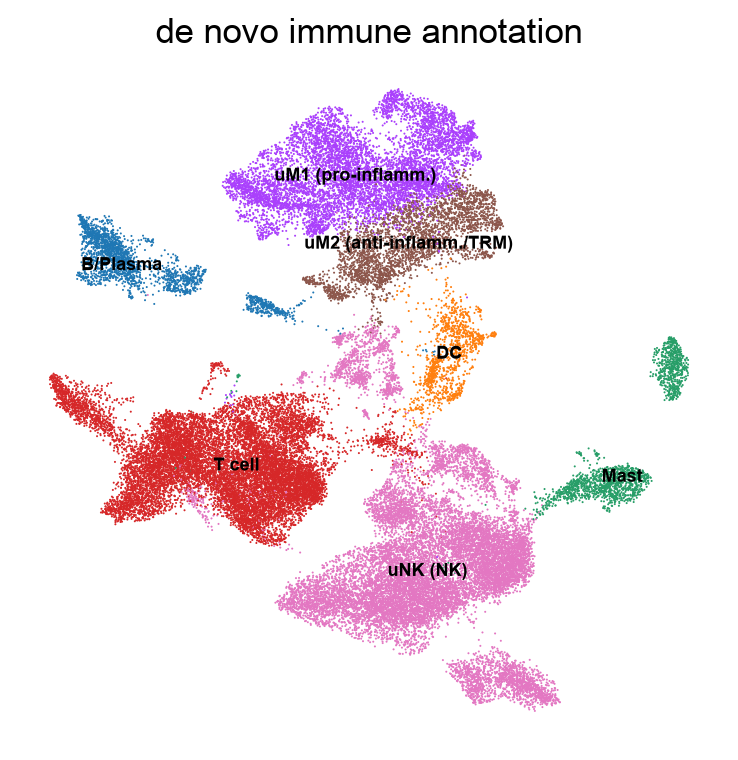

In [22]:
# de novo immune compartment, colored by the final two-tier annotation
sc.pl.umap(imm, color="immune_annot", legend_loc="on data", legend_fontsize=7,
           title="de novo immune annotation", frameon=False)

categories: B/Plasma, DC, Mast, etc.
var_group_labels: uNK (NK), Macrophage (uM), uM1 (pro-inflamm.), etc.


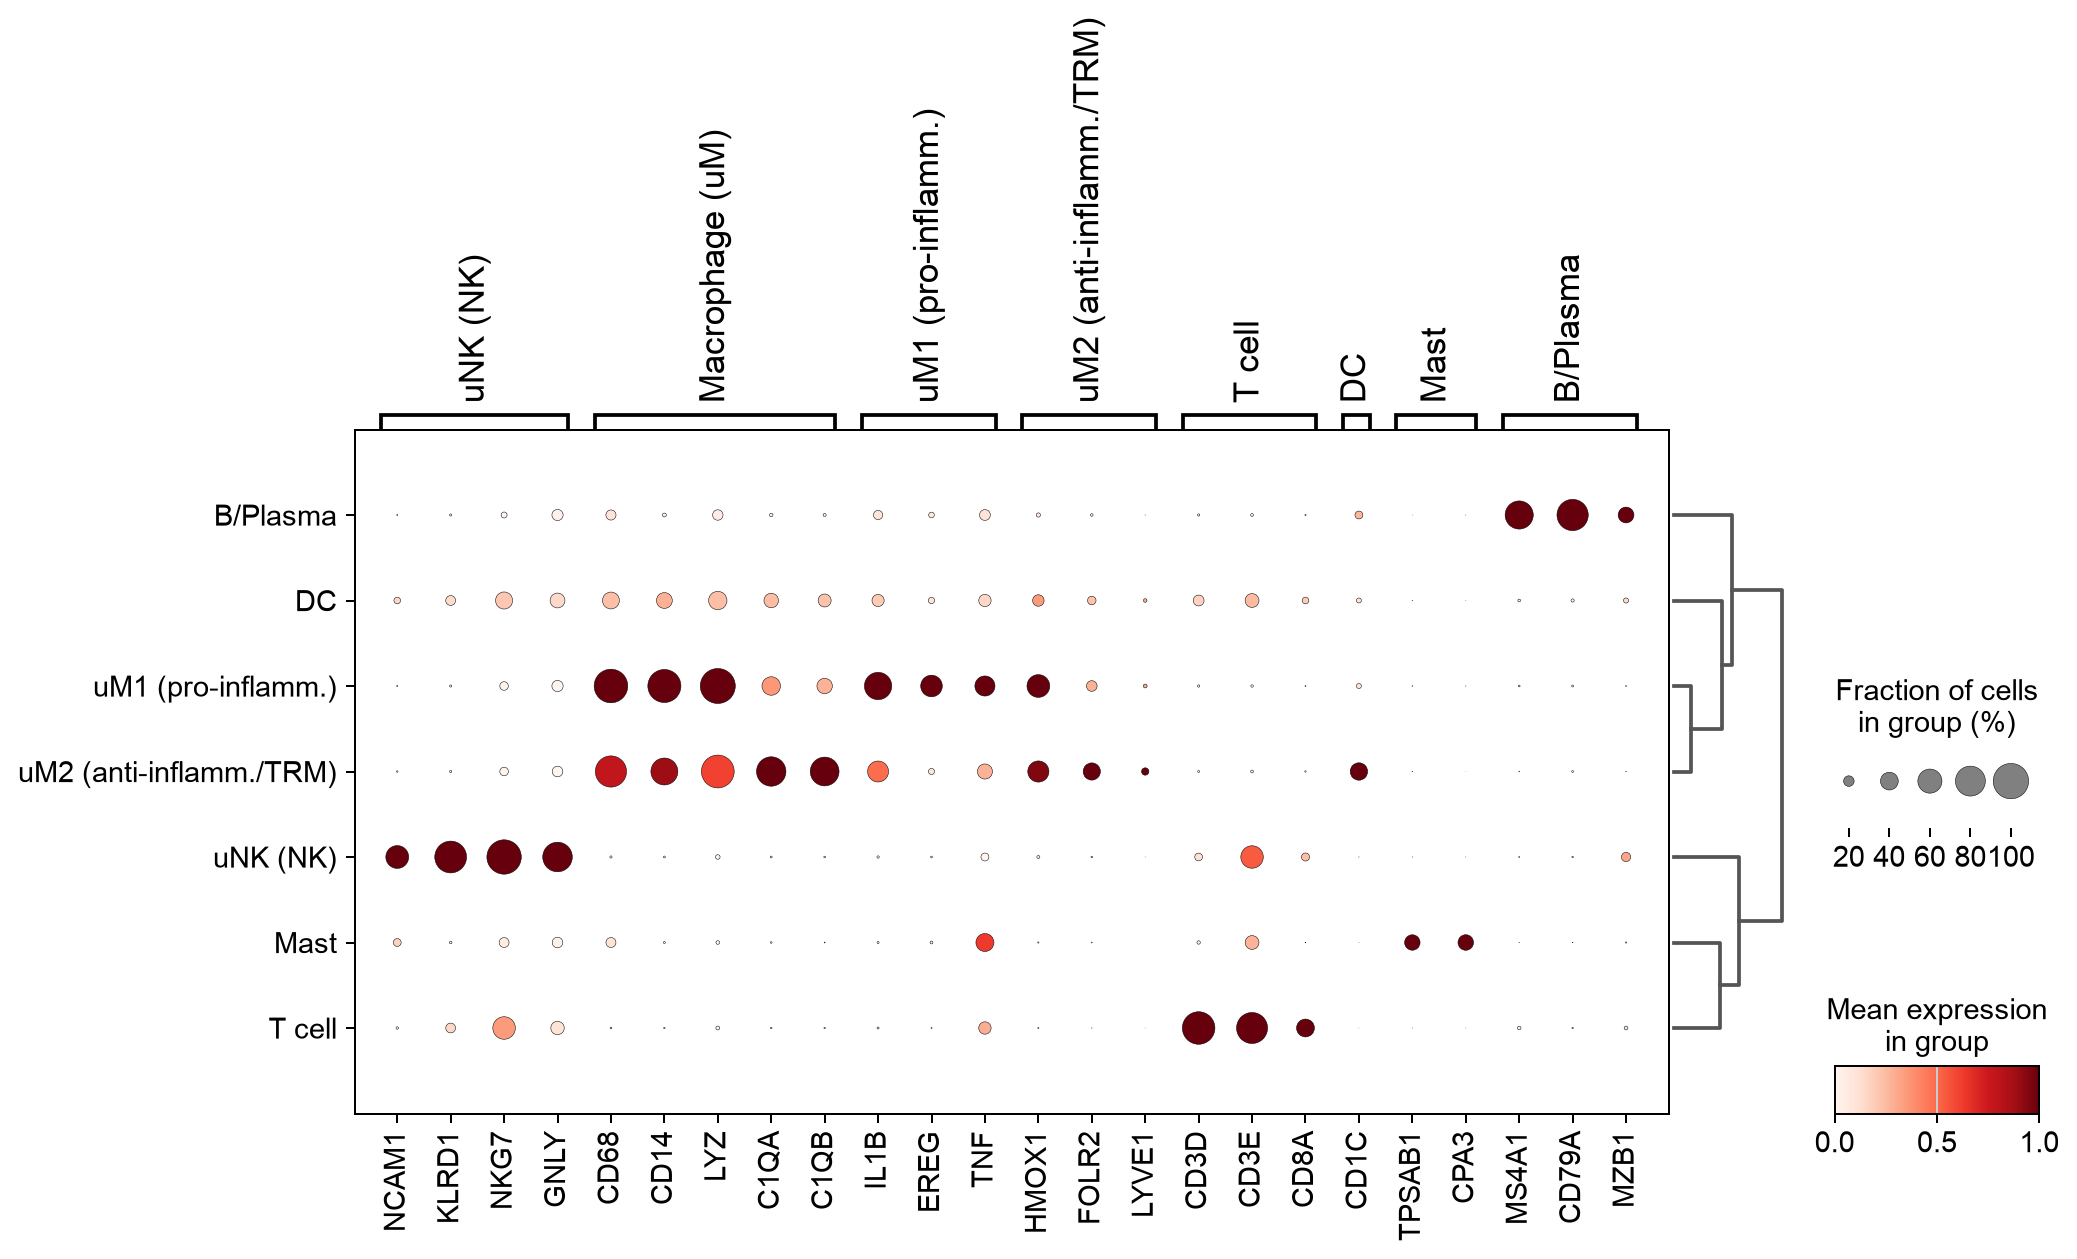

In [23]:
# marker expression by the final immune labels - each label should light up its own panel,
# and within macrophages uM1 (IL1B/EREG/TNF) should separate from uM2 (HMOX1/FOLR2/LYVE1)
sc.pl.dotplot(imm, imm_panel, groupby="immune_annot", standard_scale="var",
              dendrogram=True, figsize=(12, 5))

The de novo pass should reproduce the macrophage / uNK / T / DC / mast structure and, within macrophages, the uM1 (IL1B, EREG) vs uM2 (HMOX1, FOLR2, LYVE1) split. Concordance with the shipped labels is the check that the disease analysis below rests on a stable annotation rather than one particular label transfer.

## 5. Cell-type selection and (potential) disease signal discovery

### 5a. Composition (exploratory, treated with caution)

Cell-type proportions per donor, case vs control. **Caveat, stated up front:** the seven source datasets differ substantially in cell-type recovery, so composition shifts on the scRNA-seq atlas partly reflect technical recovery, not biology, which might be why Mareckova et al. used single-nuclei data for their differential abundance analysis. In any case, there is little evidence here of any significant composition shift between cases and controls. This is shown for completeness and to motivate cell-type focus, not as the primary evidence. For a differential abundance analysis akin to the one performed by Mareckova et al., see **section 8c**.

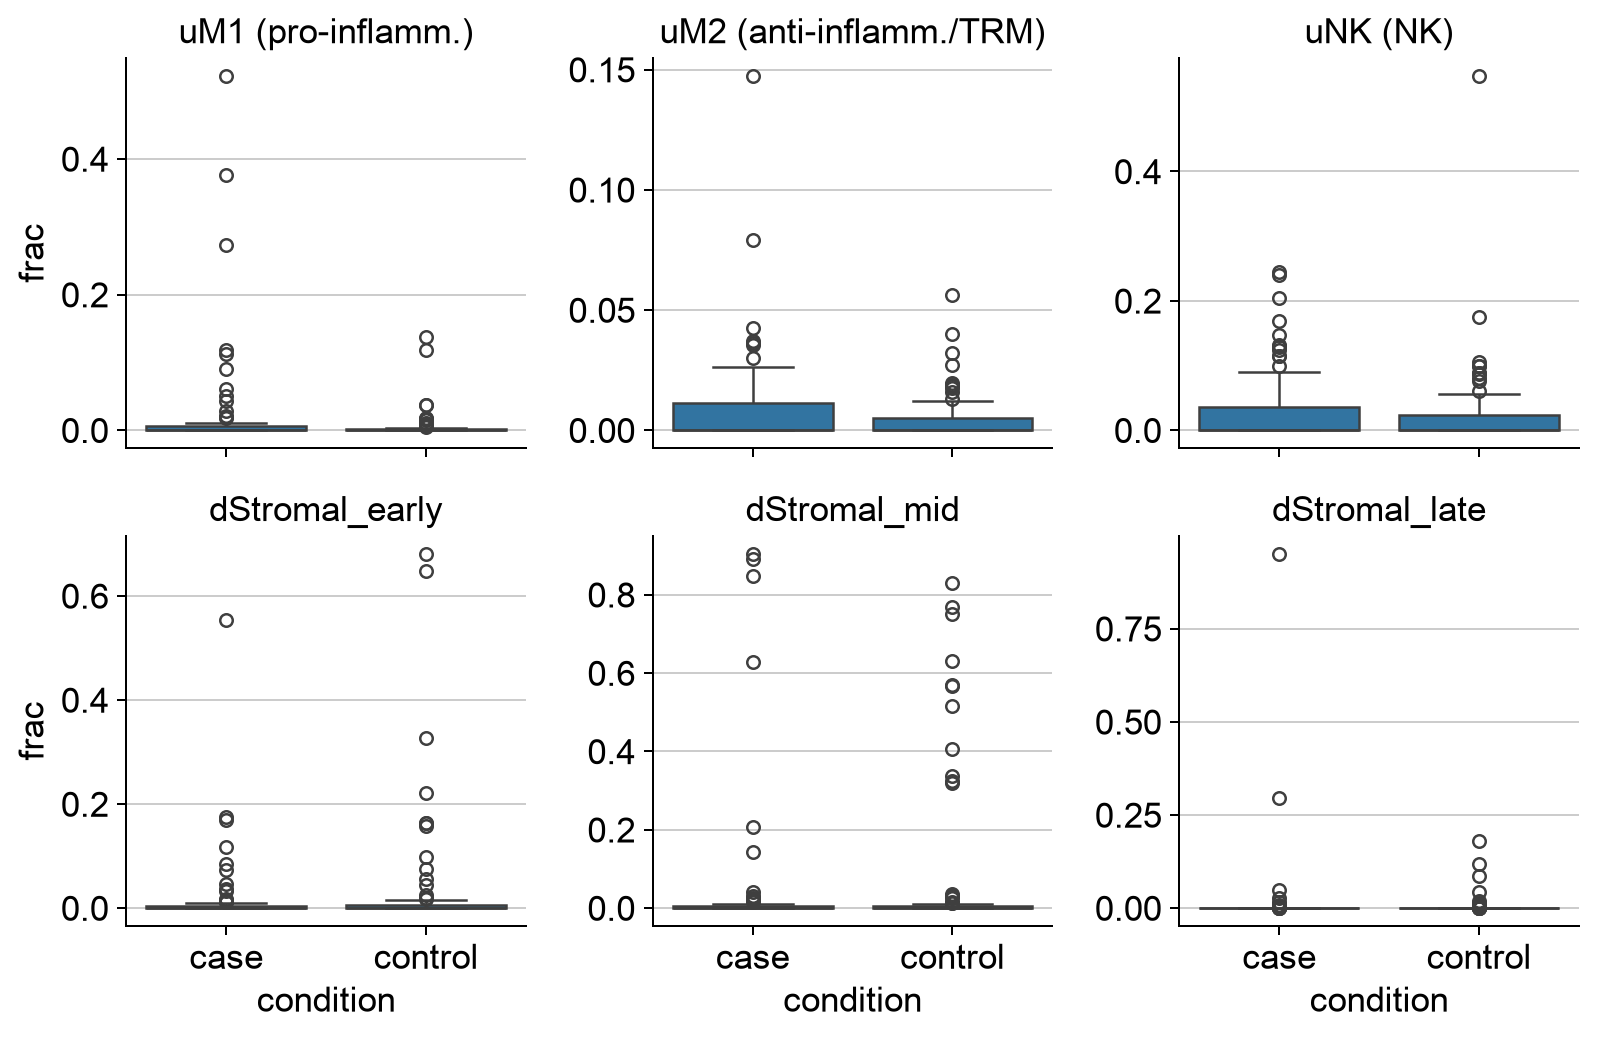

In [24]:
use = adata[adata.obs["use_for_contrast"]].copy()

# Composition is read on a COMBINED fine label: the de novo immune subsets (uM1/uM2/uNK/T/DC/...)
# substituted into the immune cells, with the shipped celltype kept everywhere else. This is what
# lets the macrophage compartments show up here at all -- the shipped coarse 'Immune_Myeloid' label
# hides them. Reminder (see markdown above): composition on this scRNA atlas is confounded by
# per-dataset recovery differences, so this is exploratory support, not the disease evidence.
COMP_COL = "celltype_fine"
_fine = use.obs[CELLTYPE_COL].astype("object").copy()
_m = use.obs["immune_annot"].notna().values
_fine[_m] = use.obs["immune_annot"].astype("object").values[_m]
use.obs[COMP_COL] = pd.Categorical(_fine)

prop = (use.obs.groupby([DONOR_COL, "condition"], observed=True)[COMP_COL]
        .value_counts(normalize=True).rename("frac").reset_index())

# focus on the implicated compartments: macrophage subsets and decidualized stroma.
# cast the facet column to str so only the present compartments get a panel (a categorical col
# would draw an empty panel for every unused level).
focus = prop[prop[COMP_COL].astype(str).str.contains("uM1|uM2|uNK|dStromal", case=True, na=False)].copy()
focus[COMP_COL] = focus[COMP_COL].astype(str)
if len(focus):
    order = ["uM1 (pro-inflamm.)", "uM2 (anti-inflamm./TRM)", "uNK (NK)",
             "dStromal_early", "dStromal_mid", "dStromal_late"]
    order = [c for c in order if c in set(focus[COMP_COL])]
    g = sns.catplot(data=focus, x="condition", y="frac", col=COMP_COL, col_order=order, kind="box",
                    col_wrap=3, height=3, sharey=False)
    g.set_titles("{col_name}"); plt.show()

In [25]:
# lightweight per-cell-type proportion test (Mann-Whitney across donors), FDR corrected
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

rows = []
for ctp, sub in prop.groupby(COMP_COL, observed=True):
    a = sub.loc[sub["condition"] == "case", "frac"]
    b = sub.loc[sub["condition"] == "control", "frac"]
    if len(a) >= 3 and len(b) >= 3:
        try:
            p = mannwhitneyu(a, b).pvalue
        except ValueError:
            p = np.nan
        rows.append((ctp, a.median() - b.median(), p))
res = pd.DataFrame(rows, columns=["cell_type", "median_diff(case-control)", "p"]).dropna()
res["FDR"] = multipletests(res["p"], method="fdr_bh")[1]
print("Composition shifts (exploratory; confounded by dataset recovery):")
display(res.sort_values("p").head(15))

Composition shifts (exploratory; confounded by dataset recovery):


,cell_type,median_diff(case-control),p,FDR
12,Lymphatic,0.000000,0.059508,0.927831
25,eHormones,0.000114,0.061233,0.927831
32,mPV,0.000000,0.081194,0.927831
17,SOX9_functionalis_II,0.000000,0.158360,0.927831
13,MUC5B,0.000000,0.182621,0.927831
26,ePV_1a,0.000000,0.191940,0.927831
33,preCiliated,0.000000,0.192100,0.927831
9,HOXA13,0.000000,0.193603,0.927831
15,SOX9_basalis,0.000000,0.253906,0.927831
21,dHormones,0.000000,0.306997,0.927831


### 5b. Within-cell-type differential expression: reproducing the reference's IGF1 hit

Mareckova et al. report IGF1 up in uM2 macrophages in their main results. Here I'm asking whether that hit is real or an artifact of their analysis choices:

- **Replication unit**: *donor* (one pseudosample per donor; the correct unit) vs *3 metacells per donor* (the authors split each donor into three random metacells, which triples the apparent replicate count but is not a recommended approach for pseudobulk differential expression analysis).
- **Design**: *naive-pooled* (`~ condition` across all datasets, what a quick re-analysis does) vs *batch-controlled* (`~ dataset + condition` restricted to datasets with both arms). The contrast is confounded by dataset-of-origin: several source datasets are entirely cases or entirely controls (crosstab below), so the naive-pooled design reads batch as biology.

The **paper-like** approach is *3-metacell + naive-pooled*; my **primary** is *donor + batch-controlled*. A gene is only credible if it also **reproduces across datasets** (section 8a), not merely reaches significance in one pooled fit.

The primary DE is reported twice, **without and with a hormone term** (`~ dataset + condition` vs `~ dataset + hormone + condition`), since exogenous-hormone treatment is confounded with case status (section 2). The adjusted fit reads the disease effect net of treatment; the two are shown side by side so the treatment contribution is visible rather than assumed.

In [26]:
# Donor-level pseudobulk + DESeq2. Axes varied to explain the reference's IGF1 hit:
#   replication : 'donor'    = one pseudosample per donor (correct; donor is the unit of replication)
#                 'metacell' = three random metacells per donor (the authors' choice; inflates replicates)
#   design      : 'naive'      = ~condition pooled across ALL datasets (what a naive re-analysis does)
#                 'controlled' = ~dataset+condition on datasets with BOTH arms (within-dataset contrast)
#   adjust_hormone : add a treated/untreated term (~ ... + hormone + condition) so the disease effect is
#                    read net of exogenous-hormone treatment, which is confounded with case status.
# The case/control contrast is confounded by dataset-of-origin: several source datasets are entirely
# cases or entirely controls (crosstab below), so 'naive' reads batch as biology. DE method is held at
# DESeq2 throughout so the comparison isolates replication and design, not the test.
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

donor_ct = (use.obs[[DONOR_COL, DATASET_COL, "condition"]].drop_duplicates()
            .groupby([DATASET_COL, "condition"], observed=True).size().unstack(fill_value=0))
BOTH_ARM = [d for d in donor_ct.index if donor_ct.loc[d].get("case", 0) >= 3
            and donor_ct.loc[d].get("control", 0) >= 3]
print("donors per dataset x condition (contrast cohort):"); print(donor_ct, "\n")
print("datasets usable for a within-dataset contrast (>=3 donors both arms):", BOTH_ARM)

def _pseudobulk(sub, replication="donor", seed=SEED):
    """Sum raw counts into pseudosamples -> (counts [pseudosample x gene], meta [condition, dataset, hormone])."""
    C = fetch_counts(sub)
    dons = sub.obs[DONOR_COL].astype(str).values
    cond = sub.obs["condition"].astype(str).values
    dset = sub.obs[DATASET_COL].astype(str).values
    horm = sub.obs["hormone"].astype(str).values
    rows, mats = [], []
    rng = np.random.default_rng(seed)
    for d in pd.unique(dons):
        idx = np.where(dons == d)[0]
        parts = [idx] if (replication == "donor" or len(idx) < 3) else np.array_split(rng.permutation(idx), 3)
        for k, part in enumerate(parts):
            if len(part) == 0:
                continue
            mats.append(np.asarray(C[part].sum(0)).ravel())
            rows.append((d if replication == "donor" else f"{d}__m{k}", cond[idx[0]], dset[idx[0]], horm[idx[0]]))
    counts = pd.DataFrame(np.vstack(mats), index=[r[0] for r in rows],
                          columns=sub.var_names).round().astype(int)
    meta = pd.DataFrame(rows, columns=["ps", "condition", DATASET_COL, "hormone"]).set_index("ps")
    return counts, meta

def run_de(sub, replication="donor", design="controlled", adjust_hormone=False):
    """DESeq2 case-vs-control under the chosen replication and design. adjust_hormone adds a treated/
    untreated term when it varies. Returns results sorted by padj, or None if <3 pseudosamples per arm."""
    s = sub if design == "naive" else sub[sub.obs[DATASET_COL].astype(str).isin(BOTH_ARM)].copy()
    counts, meta = _pseudobulk(s, replication=replication)
    vc = meta["condition"].value_counts()
    if vc.get("case", 0) < 3 or vc.get("control", 0) < 3:
        return None
    expr = (counts > 0).sum(0) >= max(3, int(0.5 * counts.shape[0]))     # gene filter
    counts = counts.loc[:, expr]
    factors = [] if design == "naive" else [DATASET_COL]
    if adjust_hormone and meta["hormone"].nunique() > 1:                 # skip if constant (else rank-deficient)
        factors = factors + ["hormone"]
    factors = factors + ["condition"]
    dds = DeseqDataSet(counts=counts, metadata=meta, design_factors=factors, quiet=True); dds.deseq2()
    st = DeseqStats(dds, contrast=["condition", "case", "control"], quiet=True); st.summary()
    return st.results_df.rename(columns={"log2FoldChange": "log2FC"}).sort_values("padj")

def de_single_dataset(sub, ds, replication="donor", adjust_hormone=False):
    """Case/control within ONE dataset (~condition [+ hormone]), for cross-dataset reproducibility checks."""
    return run_de(sub[sub.obs[DATASET_COL].astype(str) == ds].copy(), replication=replication,
                  design="naive", adjust_hormone=adjust_hormone)

print("\nhelpers ready: run_de(sub, replication, design, adjust_hormone), de_single_dataset(...)")

donors per dataset x condition (contrast cohort):
condition     case  control
dataset                    
Mareckova       22       12
GarciaAlonso     0        6
Wang             0       10
Tan              9        3
Fonseca          7        0
Huang            6        4
Lai              0        3 

datasets usable for a within-dataset contrast (>=3 donors both arms): ['Mareckova', 'Tan', 'Huang']

helpers ready: run_de(sub, replication, design, adjust_hormone), de_single_dataset(...)


In [27]:
# PRIMARY DE = donor-level, batch-controlled (~ dataset + condition on both-arm datasets), fit two ways:
#   WITHOUT hormone (~ dataset + condition)  and  WITH hormone (~ dataset + hormone + condition).
# Treatment is confounded with case status, so the adjusted fit reads the disease effect net of it.
compartments = {
    "uM2 macrophage":       use[use.obs["immune_annot"].astype(str) == "uM2 (anti-inflamm./TRM)"].copy(),
    "uM1 macrophage":       use[use.obs["immune_annot"].astype(str) == "uM1 (pro-inflamm.)"].copy(),
    "macrophage (uM1+uM2)": use[use.obs["immune_annot"].astype(str).str.contains("uM", na=False)].copy(),
    "decidualized stroma":  use[use.obs[CELLTYPE_COL].astype(str).str.contains("dStromal", na=False)].copy(),
}
de_ctrl = {name: run_de(sub, "donor", "controlled", adjust_hormone=False) for name, sub in compartments.items()}
de_adj  = {name: run_de(sub, "donor", "controlled", adjust_hormone=True)  for name, sub in compartments.items()}

def _igf1(r):
    if r is None or "IGF1" not in r.index: return "n/a"
    x = r.loc["IGF1"]; return f"{x['log2FC']:+.2f} (p={x['pvalue']:.3f}, padj={x['padj']:.3f})"
print(f"{'compartment':26s} | FDR<0.05 (unadj/adj) | IGF1 unadjusted  ->  IGF1 hormone-adjusted")
for name in compartments:
    ru, ra = de_ctrl[name], de_adj[name]
    nu = int((ru['padj'] < 0.05).sum()) if ru is not None else None
    na = int((ra['padj'] < 0.05).sum()) if ra is not None else None
    print(f"{name:26s} | {str(nu):>6} / {str(na):<6}     | {_igf1(ru)}  ->  {_igf1(ra)}")

# characterize the one compartment with a real count of hits (unadjusted primary): coherent program?
sig = de_ctrl["decidualized stroma"]; sig = sig[sig["padj"] < 0.05].copy()
IEG = {"FOS","FOSB","JUN","JUNB","JUND","EGR1","IER2","IER3","DUSP1","ATF3","NR4A1","NR4A2","NR4A3",
       "ZFP36","SGK1","BTG2","KLF6","MCL1","SOCS3","GADD45B","PPP1R15A","HSPA1A","HSPA1B","HSPB1","PLK3"}
EPI = {"DSG2","KRTCAP3","AGR3","RAB25","EPCAM","KRT8","KRT18","CDH1","PLLP"}
sig["class"] = ["IEG/handling" if g in IEG else "epithelial-contam." if g in EPI else "other" for g in sig.index]
print(f"\ndecidualized stroma hits ({len(sig)}, unadjusted primary): "
      f"{sig['class'].value_counts().to_dict()}; IGF1/IGF2 present: "
      f"{any(g in sig.index for g in ['IGF1','IGF2'])}")

compartment                | FDR<0.05 (unadj/adj) | IGF1 unadjusted  ->  IGF1 hormone-adjusted
uM2 macrophage             |      0 / 0          | +0.15 (p=0.734, padj=0.985)  ->  +0.30 (p=0.465, padj=0.962)
uM1 macrophage             |      0 / 0          | +0.07 (p=0.910, padj=0.999)  ->  +0.19 (p=0.718, padj=1.000)
macrophage (uM1+uM2)       |      0 / 0          | -0.02 (p=0.974, padj=0.999)  ->  +0.10 (p=0.808, padj=0.992)
decidualized stroma        |      2 / 8          | +0.17 (p=0.616, padj=0.971)  ->  +0.39 (p=0.214, padj=0.757)

decidualized stroma hits (2, unadjusted primary): {'other': 2}; IGF1/IGF2 present: False


In [28]:
# Centerpiece: does reproducing the reference's choices bring IGF1 back, and which choice does it?
# Vary replication x design and read the candidate genes in the two thesis compartments. DE = DESeq2.
GRID = [("metacell", "naive"), ("donor", "naive"), ("metacell", "controlled"), ("donor", "controlled")]
LAB  = {("metacell", "naive"):      "3-metacell / naive-pooled [paper-like]",
        ("donor", "naive"):         "donor / naive-pooled",
        ("metacell", "controlled"): "3-metacell / batch-controlled",
        ("donor", "controlled"):    "donor / batch-controlled [primary]"}
CAND = {"uM2 macrophage":      ["IGF1", "IL1B", "TNFRSF1B", "HMOX1"],
        "decidualized stroma": ["IGF1", "IGF2", "GREB1", "DKK1"]}

def _fmt(r, genes):
    if r is None: return pd.Series("insufficient", index=genes)
    return r.reindex(genes).apply(lambda x: f"{x['log2FC']:+.2f} (p={x['pvalue']:.3f})", axis=1)

for cname, genes in CAND.items():
    sub = compartments[cname]
    tab = pd.DataFrame({LAB[k]: _fmt(run_de(sub, *k), genes) for k in GRID})
    print(f"=== {cname}: log2FC (p) by replication x design ===")
    display(tab); print()

# Genome-wide, the number of FDR<0.05 hits under the paper-like recipe vs our primary. Pseudo-
# replication (3 metacells/donor) on a batch-confounded pooled contrast manufactures a flood of hits.
rows = []
for cname, sub in compartments.items():
    rp = run_de(sub, "metacell", "naive")
    ro = de_ctrl[cname]
    rows.append((cname,
                 int((rp["padj"] < 0.05).sum()) if rp is not None else None,
                 int((ro["padj"] < 0.05).sum()) if ro is not None else None))
fdr = pd.DataFrame(rows, columns=["compartment", "paper-like: 3-metacell, naive-pooled",
                                  "primary: donor, batch-controlled"]).set_index("compartment")
print("genes at FDR<0.05, paper-like vs primary:"); display(fdr)

=== uM2 macrophage: log2FC (p) by replication x design ===


,3-metacell / naive-pooled [paper-like],donor / naive-pooled,3-metacell / batch-controlled,donor / batch-controlled [primary]
IGF1,-0.17 (p=0.467),-0.12 (p=0.726),+0.10 (p=0.726),+0.15 (p=0.734)
IL1B,-0.03 (p=0.932),+0.30 (p=0.471),-0.45 (p=0.176),-0.72 (p=0.151)
TNFRSF1B,-0.03 (p=0.824),-0.11 (p=0.624),+0.20 (p=0.088),+0.22 (p=0.222)
HMOX1,-1.18 (p=0.000),-1.15 (p=0.009),-0.69 (p=0.025),-0.59 (p=0.201)


=== decidualized stroma: log2FC (p) by replication x design ===


,3-metacell / naive-pooled [paper-like],donor / naive-pooled,3-metacell / batch-controlled,donor / batch-controlled [primary]
IGF1,+0.00 (p=0.998),-0.04 (p=0.888),+0.19 (p=0.357),+0.17 (p=0.616)
IGF2,-0.71 (p=0.010),-0.92 (p=0.035),+0.09 (p=0.756),+0.01 (p=0.974)
GREB1,+0.04 (p=0.792),+0.00 (p=0.983),-0.41 (p=0.025),-0.44 (p=0.120)
DKK1,+0.02 (p=0.940),-0.15 (p=0.770),+0.25 (p=0.559),+0.13 (p=0.865)


genes at FDR<0.05, paper-like vs primary:


,"paper-like: 3-metacell, naive-pooled","primary: donor, batch-controlled"
compartment,,
uM2 macrophage,180,0
uM1 macrophage,1409,0
macrophage (uM1+uM2),741,0
decidualized stroma,397,2


A more principled differential expression analysis, with donor-level replication and dataset control, yields almost no hits.

### 5e. Beyond differential expression: is there any case/control structure at all?

Single-gene DE could in principle miss a signal spread thinly across many genes. So this section steps back to the sample level and asks the question three complementary ways, each built to expose the dataset confound rather than hide it:

- **(i) Unsupervised structure**: PCA of whole-donor pseudobulk, colored by condition and by dataset, with the variance in each component partitioned between the two (`eta^2`). If donors organize by dataset and not by disease, the confound is the dominant axis of variation.
- **(ii) Transfer**: a case/control classifier (PLS-DA, with random forest as a nonlinear check) trained on one both-arm dataset and tested on the other. A real disease signature should generalize across datasets; a batch-driven one will not. Scored against a label-permutation null. PLS-DA is the primary choice here: at ~66 donors and ~14k genes it is the right complexity (linear, regularized by a few components), it yields an interpretable supervised axis, and random forest serves as the nonlinear robustness check.
- **(iii) Aggregate programs**: known disease modules (IGF axis, inflammatory, decidualization) scored per donor and tested batch-controlled and for cross-dataset reproducibility, which is more powered than testing 14,000 single genes.

variance in each PC explained by dataset vs condition (eta^2):
  PC1 (40.2%): dataset=0.20  condition=0.00
  PC2 (14.5%): dataset=0.43  condition=0.01
  PC3 ( 7.7%): dataset=0.25  condition=0.00
  PC4 ( 6.1%): dataset=0.39  condition=0.00
  PC5 ( 4.8%): dataset=0.35  condition=0.00
  PC6 ( 3.1%): dataset=0.29  condition=0.04


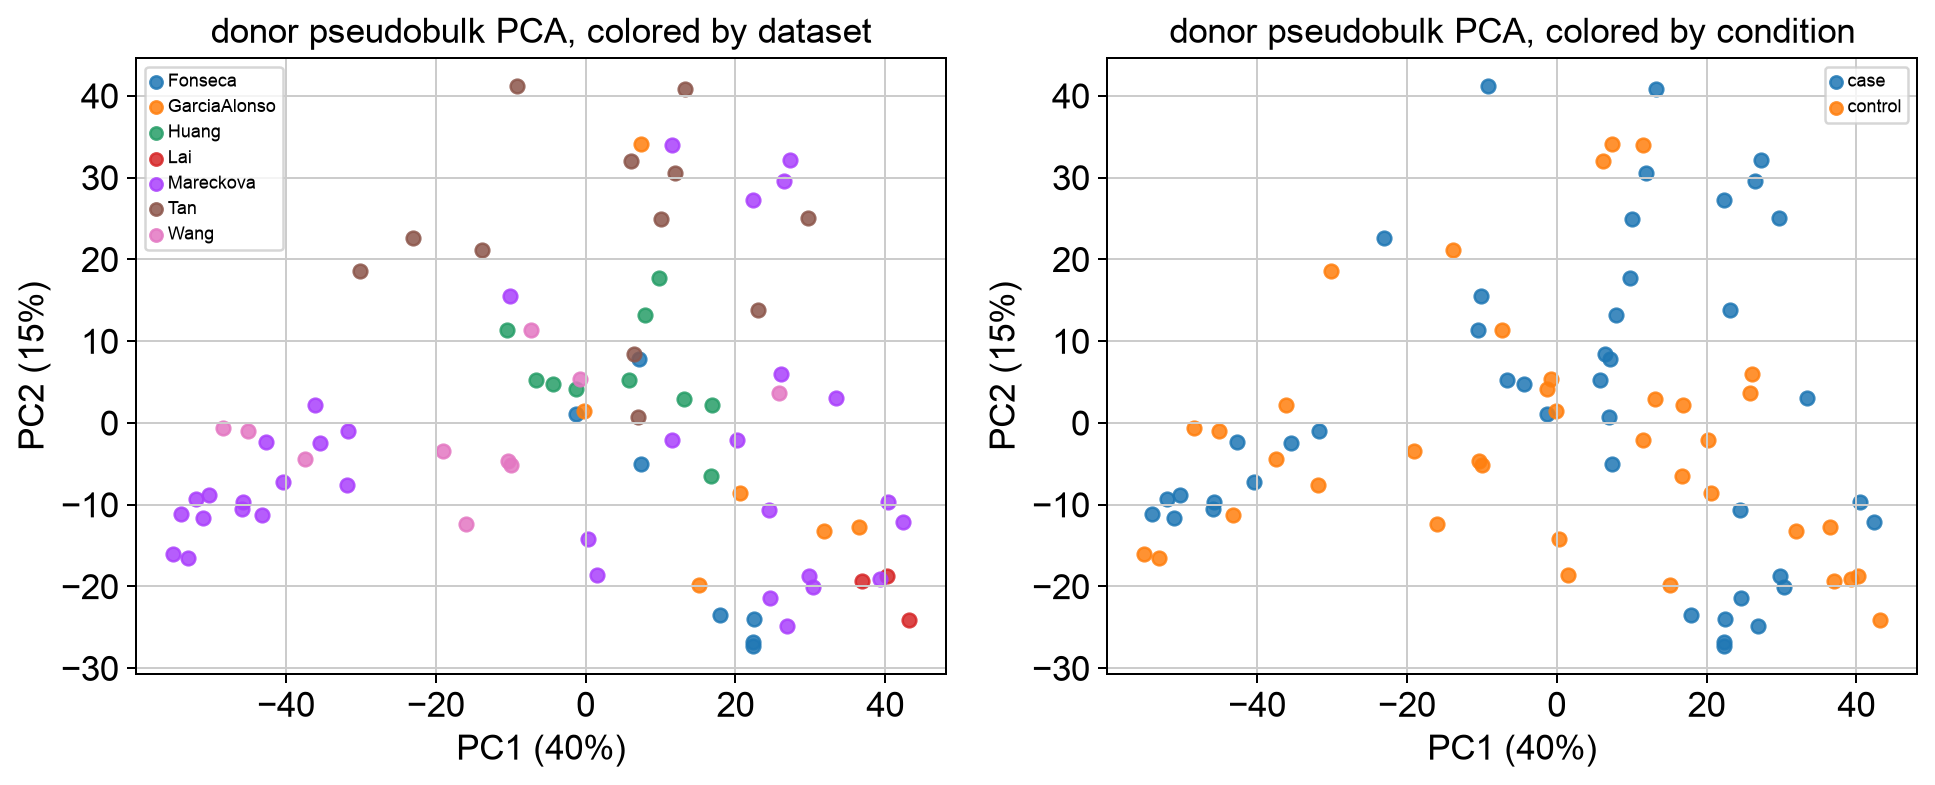

In [29]:
# 5e-i. Sample-level structure: whole-donor pseudobulk PCA, colored by condition vs dataset, with
# each component's variance partitioned between dataset and condition (eta^2).
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def donor_pseudobulk(sub):
    """One summed-count profile per donor (whole transcriptome) -> (log-CPM [donor x gene], meta)."""
    d = sub.obs[DONOR_COL].astype(str).values; donors = pd.unique(d)
    mat = np.vstack([np.asarray(fetch_counts(sub[d == x]).sum(0)).ravel() for x in donors])
    counts = pd.DataFrame(mat, index=donors, columns=sub.var_names).round().astype(int)
    m = (sub.obs[[DONOR_COL, "condition", DATASET_COL, "hormone"]].astype(str)
         .drop_duplicates(DONOR_COL).set_index(DONOR_COL).loc[donors])
    return np.log1p(counts.div(counts.sum(1), axis=0) * 1e6), m

logcpm_use, meta_use = donor_pseudobulk(use)
_hvg = lambda X, n=2000: X.var(0).sort_values(ascending=False).index[:n]
def _eta2(pc, groups):
    g = pd.Series(np.asarray(groups), index=pc.index); grand = pc.mean()
    return sum((g == l).sum() * (pc[g == l].mean() - grand) ** 2 for l in pd.unique(g)) / ((pc - grand) ** 2).sum()

Xz = StandardScaler().fit_transform(logcpm_use[_hvg(logcpm_use)])
pca = PCA(n_components=10, random_state=SEED).fit(Xz)
pcs = pd.DataFrame(pca.transform(Xz), index=logcpm_use.index, columns=[f"PC{i+1}" for i in range(10)])
print("variance in each PC explained by dataset vs condition (eta^2):")
for i in range(6):
    print(f"  PC{i+1} ({pca.explained_variance_ratio_[i]*100:4.1f}%): "
          f"dataset={_eta2(pcs.iloc[:, i], meta_use[DATASET_COL].values):.2f}  "
          f"condition={_eta2(pcs.iloc[:, i], meta_use['condition'].values):.2f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4.6))
for a, key, title in [(ax[0], DATASET_COL, "colored by dataset"), (ax[1], "condition", "colored by condition")]:
    for lev, s_ in meta_use.groupby(key):
        a.scatter(pcs.loc[s_.index, "PC1"], pcs.loc[s_.index, "PC2"], s=30, alpha=0.85, label=str(lev))
    a.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.0f}%)")
    a.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.0f}%)")
    a.set_title(f"donor pseudobulk PCA, {title}"); a.legend(fontsize=7, markerscale=0.9)
plt.tight_layout(); plt.show()

PLS-DA: Mareckova->Huang AUC=0.46 | Huang->Mareckova AUC=0.44 | permutation null mean=0.51, p(M->H)=0.630


RF: Mareckova->Huang AUC=0.19 | Huang->Mareckova AUC=0.44 | permutation null mean=0.51, p(M->H)=0.925


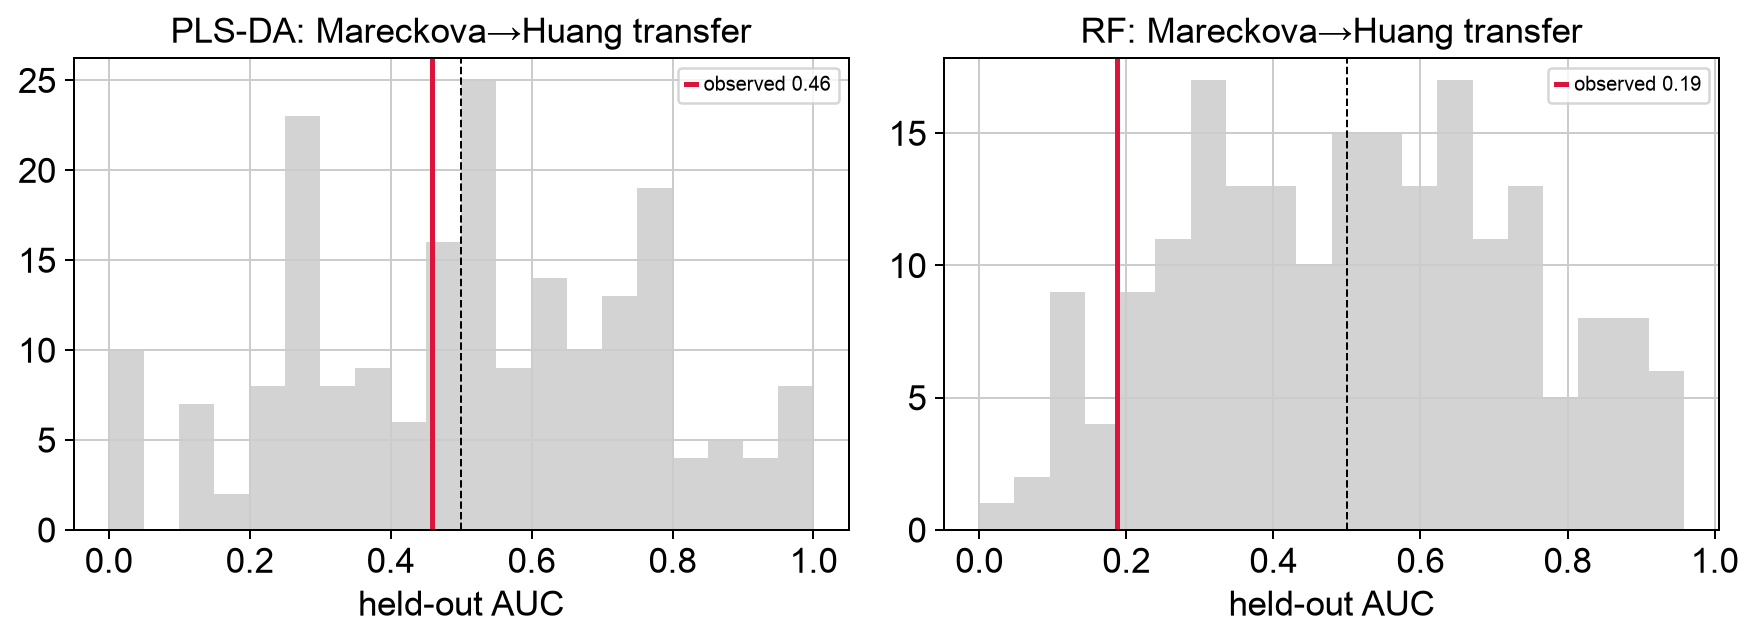

In [30]:
# 5e-ii. Does a case/control signature TRANSFER across datasets? Train on one both-arm dataset and
# predict the other (PLS-DA primary; random forest as a nonlinear check), against a label-permutation
# null. Real disease signal should generalize across batch; a dataset-confounded one will not.
from sklearn.cross_decomposition import PLSRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

def _score(Xtr, ytr, Xte, model):
    if model == "PLS-DA":
        return PLSRegression(n_components=2).fit(Xtr, ytr * 2.0 - 1).predict(Xte).ravel()
    return RandomForestClassifier(n_estimators=400, random_state=SEED, n_jobs=-1).fit(Xtr, ytr).predict_proba(Xte)[:, 1]

def _transfer(tr, te, model, yperm=None):
    ytr = (meta_use.loc[tr, "condition"] == "case").astype(int).values if yperm is None else yperm
    yte = (meta_use.loc[te, "condition"] == "case").astype(int).values
    hvg = _hvg(logcpm_use.loc[tr]); s = StandardScaler().fit(logcpm_use.loc[tr, hvg])   # fit on train only
    return roc_auc_score(yte, _score(s.transform(logcpm_use.loc[tr, hvg]), ytr,
                                     s.transform(logcpm_use.loc[te, hvg]), model))

Mi = meta_use.index[meta_use[DATASET_COL] == "Mareckova"]; Hi = meta_use.index[meta_use[DATASET_COL] == "Huang"]
rng = np.random.default_rng(SEED)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))
for j, model in enumerate(["PLS-DA", "RF"]):
    obsMH, obsHM = _transfer(Mi, Hi, model), _transfer(Hi, Mi, model)
    null = np.array([_transfer(Mi, Hi, model,
                     yperm=rng.permutation((meta_use.loc[Mi, "condition"] == "case").astype(int).values))
                     for _ in range(200)])
    print(f"{model}: Mareckova->Huang AUC={obsMH:.2f} | Huang->Mareckova AUC={obsHM:.2f} | "
          f"permutation null mean={null.mean():.2f}, p(M->H)={np.mean(null >= obsMH):.3f}")
    ax[j].hist(null, bins=20, color="lightgrey"); ax[j].axvline(0.5, color="k", lw=0.8, ls="--")
    ax[j].axvline(obsMH, color="crimson", lw=2, label=f"observed {obsMH:.2f}")
    ax[j].set_title(f"{model}: Mareckova→Huang transfer"); ax[j].set_xlabel("held-out AUC"); ax[j].legend(fontsize=8)
plt.tight_layout(); plt.show()

In [31]:
# 5e-iii. Aggregate disease programs (more powered than single genes): do known modules shift with
# condition, batch-controlled (~ dataset + condition), and in the SAME direction across both both-arm datasets?
import statsmodels.formula.api as smf
MODULES = {
    "IGF axis":        ["IGF1", "IGF2", "IGF1R", "IGFBP1", "IGFBP2", "IGFBP3", "IGFBP5", "IGFBP7", "INSR", "IRS2"],
    "Inflammatory":    ["IL1B", "TNF", "TNFRSF1B", "CEBPD", "NFKB1", "CXCL8", "IL6", "CCL2", "PTGS2", "IL1A", "CXCL1"],
    "Decidualization": ["IGFBP1", "PRL", "DKK1", "GREB1", "LEFTY2", "SMAD7", "FOXO1", "WNT4", "HAND2"],
}
Zc = (logcpm_use - logcpm_use.mean(0)) / (logcpm_use.std(0) + 1e-9)     # z per gene across donors
both = meta_use.index[meta_use[DATASET_COL].isin(BOTH_ARM)]
def _casediff(score, ds):
    idx = meta_use.index[meta_use[DATASET_COL] == ds]; s = score.loc[idx]; c = meta_use.loc[idx, "condition"]
    return s[c == "case"].mean() - s[c == "control"].mean()
rows = []
for name, genes in MODULES.items():
    g = [x for x in genes if x in Zc.columns]; score = Zc[g].mean(1)
    d = pd.DataFrame({"score": score.loc[both].values, "dataset": meta_use.loc[both, DATASET_COL].values,
                      "condition": meta_use.loc[both, "condition"].values,
                      "hormone": meta_use.loc[both, "hormone"].values})
    _fml = "score ~ dataset + condition" + (" + hormone" if d["hormone"].nunique() > 1 else "")
    p = smf.ols(_fml, data=d).fit().pvalues.get("condition[T.control]", np.nan)
    dM, dH = _casediff(score, "Mareckova"), _casediff(score, "Huang")
    rows.append((name, len(g), round(dM, 2), round(dH, 2), bool(np.sign(dM) == np.sign(dH)), round(p, 3)))
print("Per-donor module scores, case vs control (whole-donor pseudobulk):")
display(pd.DataFrame(rows, columns=["module", "n_genes", "Mareckova d(case-ctrl)", "Huang d",
                                    "same direction?", "batch-controlled p"]).set_index("module"))

Per-donor module scores, case vs control (whole-donor pseudobulk):


,n_genes,Mareckova d(case-ctrl),Huang d,same direction?,batch-controlled p
module,,,,,
IGF axis,10,0.00,-0.01,False,0.618
Inflammatory,11,0.23,0.43,True,0.938
Decidualization,9,0.16,-0.04,False,0.951


All three views agree with the differential-expression result:

- **PCA**: every leading component is explained by dataset (`eta^2` ~ 0.2 to 0.5) and essentially none by condition (~0), and condition does not structure the variation even within Mareckova alone. The "eyeball test" reveals clustering by study but not by condition.
- **Transfer**: the classifier does not generalize across datasets: a model trained to separate case from control in one dataset performs at or below chance on the other, no better than shuffled labels, under both PLS-DA and random forest.
- **Modules**: no disease module shows a reproducible, batch-controlled shift; the inflammatory module even points in opposite directions in the two datasets.

So the negative result is not an artifact of single-gene testing. At the resolution this atlas supports, endometriosis case/control differences are not separable from dataset-of-origin by unsupervised structure, supervised transfer, or aggregate gene programs. This strengthens the conclusion from the differential-expression analysis (5b, and the reproducibility and method cross-checks in 8a–8b), namely that the disease signal here is confounded with batch, not a specific gene the differential-expression analysis missed.

### 5f. What about Mareckova alone?

A fair objection to everything above is that the pooling confound is what buried the DE signal. So this section runs the within-cell-type DE on the single best dataset in isolation: **Mareckova**, the reference's own newly-generated data (one lab, one protocol), which has both arms (18 case, 12 control donors overall). **This removes the cross-dataset confound entirely.**

In [32]:
# DE within Mareckova alone (donor-level, ~condition [+ hormone]), then test whether its hits reproduce
# in Huang. Mareckova carries treated + untreated cases and untreated controls, so it is the cleanest
# single-dataset hormone adjustment; Huang has no treated donors, so the hormone term is dropped there.
# de_single_dataset() reuses the section-5b machinery restricted to one dataset.
IEG = {"FOS","FOSB","JUN","JUNB","JUND","EGR1","IER2","IER3","DUSP1","ATF3","NR4A1","NR4A2","NR4A3",
       "ZFP36","SGK1","BTG2","KLF6","MCL1","SOCS3","GADD45B","PPP1R15A","HSPA1A","HSPA1B","HSPB1","PLK3"}
EPI = {"DSG2","KRTCAP3","AGR3","RAB25","EPCAM","KRT8","KRT18","CDH1","PLLP"}
_cls = lambda g: "IEG/handling" if g in IEG else "epithelial-contam." if g in EPI else "other"

rows = []
for cname in ["uM2 macrophage", "macrophage (uM1+uM2)", "decidualized stroma"]:
    sub = compartments[cname]
    ndon = sub[sub.obs[DATASET_COL].astype(str) == "Mareckova"].obs[DONOR_COL].nunique()
    rM = de_single_dataset(sub, "Mareckova", adjust_hormone=True)
    if rM is None:
        rows.append((cname, ndon, "insufficient", "-", "-", "-")); continue
    rH = de_single_dataset(sub, "Huang", adjust_hormone=True)
    hit = rM.index[rM["padj"] < 0.05]
    art = f"{np.mean([_cls(g) != 'other' for g in hit])*100:.0f}%" if len(hit) else "-"
    if rH is not None and len(hit):
        common = hit.intersection(rH.index)
        rep = int((rH.loc[common, "padj"] < 0.05).sum()) if len(common) else 0
        agr = f"{(np.sign(rM.loc[common,'log2FC'])==np.sign(rH.loc[common,'log2FC'])).mean()*100:.0f}%" if len(common) else "-"
        repro = f"{rep}/{len(common)} (dir {agr})"
    else:
        repro = "Huang underpowered"
    igf1 = f"{rM.loc['IGF1','log2FC']:+.2f} (p={rM.loc['IGF1','pvalue']:.2f})" if "IGF1" in rM.index else "NA"
    rows.append((cname, ndon, len(hit), art, repro, igf1))
print("Mareckova-only DE (single dataset, hormone-adjusted, no cross-dataset confound):")
display(pd.DataFrame(rows, columns=["compartment","Mareckova donors","hits FDR<0.05","% artifact-class",
        "reproduce in Huang (FDR<0.05)","IGF1 (Mareckova)"]).set_index("compartment"))

# detail: the top Mareckova stromal hits and how each fares in Huang (sign flips / loss of significance)
sub = compartments["decidualized stroma"]
rM, rH = de_single_dataset(sub, "Mareckova", adjust_hormone=True), de_single_dataset(sub, "Huang", adjust_hormone=True)
top = rM[rM["padj"] < 0.05].head(10).copy()
top["class"] = [_cls(g) for g in top.index]
top["Huang log2FC"] = rH.reindex(top.index)["log2FC"]; top["Huang padj"] = rH.reindex(top.index)["padj"]
print("\nTop Mareckova-only stromal hits vs their Huang result:")
display(top[["log2FC", "padj", "class", "Huang log2FC", "Huang padj"]].round(3))

Mareckova-only DE (single dataset, hormone-adjusted, no cross-dataset confound):


,Mareckova donors,hits FDR<0.05,% artifact-class,reproduce in Huang (FDR<0.05),IGF1 (Mareckova)
compartment,,,,,
uM2 macrophage,26,14,21%,0/14 (dir 14%),+0.38 (p=0.53)
macrophage (uM1+uM2),26,0,-,Huang underpowered,+0.08 (p=0.89)
decidualized stroma,24,16,56%,0/16 (dir 25%),-0.01 (p=0.98)



Top Mareckova-only stromal hits vs their Huang result:


,log2FC,padj,class,Huang log2FC,Huang padj
IER2,-1.885,0.001,IEG/handling,-0.422,1.0
SOCS3,-2.454,0.001,IEG/handling,0.684,1.0
JUNB,-2.057,0.001,IEG/handling,-0.167,1.0
GADD45B,-2.493,0.001,IEG/handling,0.473,1.0
PLK3,-3.316,0.002,IEG/handling,0.031,1.0
SLPI,4.490,0.007,other,-1.735,1.0
FBXO32,1.853,0.022,other,-0.159,1.0
FOSB,-1.446,0.022,IEG/handling,0.468,1.0
ZFP36,-1.957,0.022,IEG/handling,-0.003,1.0
SCGB2A1,3.660,0.040,other,0.930,1.0


Even using just the Mareckova dataset alone, I can't replicate their finding. Mareckova-only DE does produce some hits, but they are dominated by immediate-early and epithelial-contamination genes rather than a coherent disease signature, IGF1 remains non-significant, and crucially **almost none of the Mareckova hits reproduce in Huang** (few reach significance there, and there is little directional agreement). 

### 5h. Differential expression across all cell types, and a second disease signature (Fonseca et al. 2023)

The brief asks to select a dysregulated cell type and derive a signature. Sections 5b–5f (with the supplementary reproducibility, method, and abundance checks in section 8) focused on the compartments the reference's GWAS and abundance analyses implicate (macrophages, decidualized stroma) and found no reproducible disease signal. To be sure that focus did not miss a signal elsewhere, this section runs the primary DE (donor-level, batch-controlled, hormone-adjusted) on **every** cell type, and for each asks the question that decides everything here: does the case/control signal **reproduce** across the two independent both-arm datasets (Mareckova and Huang)?

It also brings in a second study as an external anchor. Fonseca et al. (*Nat Genet* 2023) profiled endometriosis lesions and reported that, within superficial peritoneal lesions, endometrial-type epithelium overexpressed **CRIP1** and **IGFBP7** with enrichment of translation-associated (secretory) pathways. HECA is eutopic endometrium rather than ectopic lesion, so this is a cross-tissue test, but it gives an externally-defined epithelial signature to look for rather than one read off this dataset (and IGFBP7 is itself an IGF-axis gene, tying back to the earlier thread).

In [33]:
# Primary DE (donor, batch-controlled, hormone-adjusted) for EVERY fine cell type, each with its
# Mareckova-vs-Huang reproducibility r. Pseudobulk is built once per cell type and reused across the
# three fits, so the whole scan is cheap. Cell types with too few donors per arm are skipped.
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

def _celltype_pb(sub):
    """donor-level pseudobulk for one cell type across ALL datasets (one counts fetch)."""
    C = fetch_counts(sub); dons = sub.obs[DONOR_COL].astype(str).values
    src = sub.obs[["condition", DATASET_COL, "hormone"]].astype(str); rows, mats = [], []
    for d in pd.unique(dons):
        idx = np.where(dons == d)[0]; mats.append(np.asarray(C[idx].sum(0)).ravel())
        r = src.iloc[idx[0]]; rows.append((d, r["condition"], r[DATASET_COL], r["hormone"]))
    counts = pd.DataFrame(np.vstack(mats), index=[x[0] for x in rows], columns=sub.var_names).round().astype(int)
    meta = pd.DataFrame(rows, columns=["ps","condition",DATASET_COL,"hormone"]).set_index("ps")
    return counts, meta

def _de(counts, meta, donors, extra):
    """DESeq2 case-vs-control on a chosen donor subset; extra factors added only where they vary."""
    m = meta.loc[donors]; vc = m["condition"].value_counts()
    if vc.get("case",0) < 3 or vc.get("control",0) < 3: return None
    c = counts.loc[donors]; c = c.loc[:, (c > 0).sum(0) >= max(3, int(0.5*c.shape[0]))]
    fac = [f for f in extra if m[f].nunique() > 1] + ["condition"]
    try:
        dds = DeseqDataSet(counts=c, metadata=m, design_factors=fac, quiet=True); dds.deseq2()
        st = DeseqStats(dds, contrast=["condition","case","control"], quiet=True); st.summary()
        return st.results_df.rename(columns={"log2FoldChange":"log2FC"})
    except Exception:
        return None                                   # degenerate tiny cell types just get skipped

cts = use.obs["celltype_fine"].astype(str)
de_all, rows = {}, []
for ct in cts.value_counts().index:
    sub = use[cts.values == ct]
    counts, meta = _celltype_pb(sub)
    rp = _de(counts, meta, meta.index[meta[DATASET_COL].isin(BOTH_ARM)], [DATASET_COL, "hormone"])
    if rp is None:
        rows.append((ct, int((cts==ct).sum()), None, None)); continue
    de_all[ct] = rp
    rM = _de(counts, meta, meta.index[meta[DATASET_COL]=="Mareckova"], ["hormone"])
    rH = _de(counts, meta, meta.index[meta[DATASET_COL]=="Huang"], [])
    rr = np.nan
    if rM is not None and rH is not None:
        common = rM.index.intersection(rH.index)
        if len(common) >= 50: rr = np.corrcoef(rM.loc[common,"log2FC"], rH.loc[common,"log2FC"])[0,1]
    rows.append((ct, int((cts==ct).sum()), int((rp["padj"] < 0.05).sum()), round(rr,3) if rr==rr else np.nan))

scan = (pd.DataFrame(rows, columns=["celltype","n_cells","hits_FDR05","Mar_Huang_r"])
        .set_index("celltype").dropna(subset=["hits_FDR05"]))
scan["hits_FDR05"] = scan["hits_FDR05"].astype(int)
print(f"cell types tested (>=3 donors/arm in both-arm datasets): {len(scan)}\n")
print("top cell types by primary FDR<0.05 hits, with cross-dataset reproducibility:")
display(scan.sort_values("hits_FDR05", ascending=False).head(12))
print(f"max Mareckova-vs-Huang r across ALL cell types = {scan['Mar_Huang_r'].max():.2f} "
      f"(a reproducible signature would need a strongly positive r); "
      f"the high-hit cell types have r that is NaN or negative -> within-dataset artifacts.")

cell types tested (>=3 donors/arm in both-arm datasets): 35

top cell types by primary FDR<0.05 hits, with cross-dataset reproducibility:


,n_cells,hits_FDR05,Mar_Huang_r
celltype,,,
preGlandular,11784,2536,NaN
preLuminal,2734,75,NaN
Ciliated,4923,37,-0.180
uNK (NK),15612,10,0.007
eHormones,14191,3,-0.046
Luminal,10226,2,-0.143
dStromal_early,16673,2,0.010
Venous,12031,2,-0.068
Arterial,935,1,0.066


max Mareckova-vs-Huang r across ALL cell types = 0.08 (a reproducible signature would need a strongly positive r); the high-hit cell types have r that is NaN or negative -> within-dataset artifacts.


epithelial compartment: 89092 cells, 78 donors
whole-transcriptome Mareckova-vs-Huang r = -0.24  (anti-correlated, like every other compartment)
Fonseca superficial-epithelium signature, tested in HECA eutopic epithelium:


,primary log2FC,primary p,Mareckova log2FC,Huang log2FC
CRIP1,0.637,0.003,1.134,0.308
IGFBP7,0.186,0.660,0.929,-2.030
IGF1,0.747,0.119,1.431,-0.600
IGFBP1,NaN,NaN,NaN,-4.721
PAEP,0.911,0.281,1.320,-4.053
SLPI,0.319,0.429,1.008,-2.108
translation(RPS/RPL) mean,-0.173,NaN,-0.240,0.253


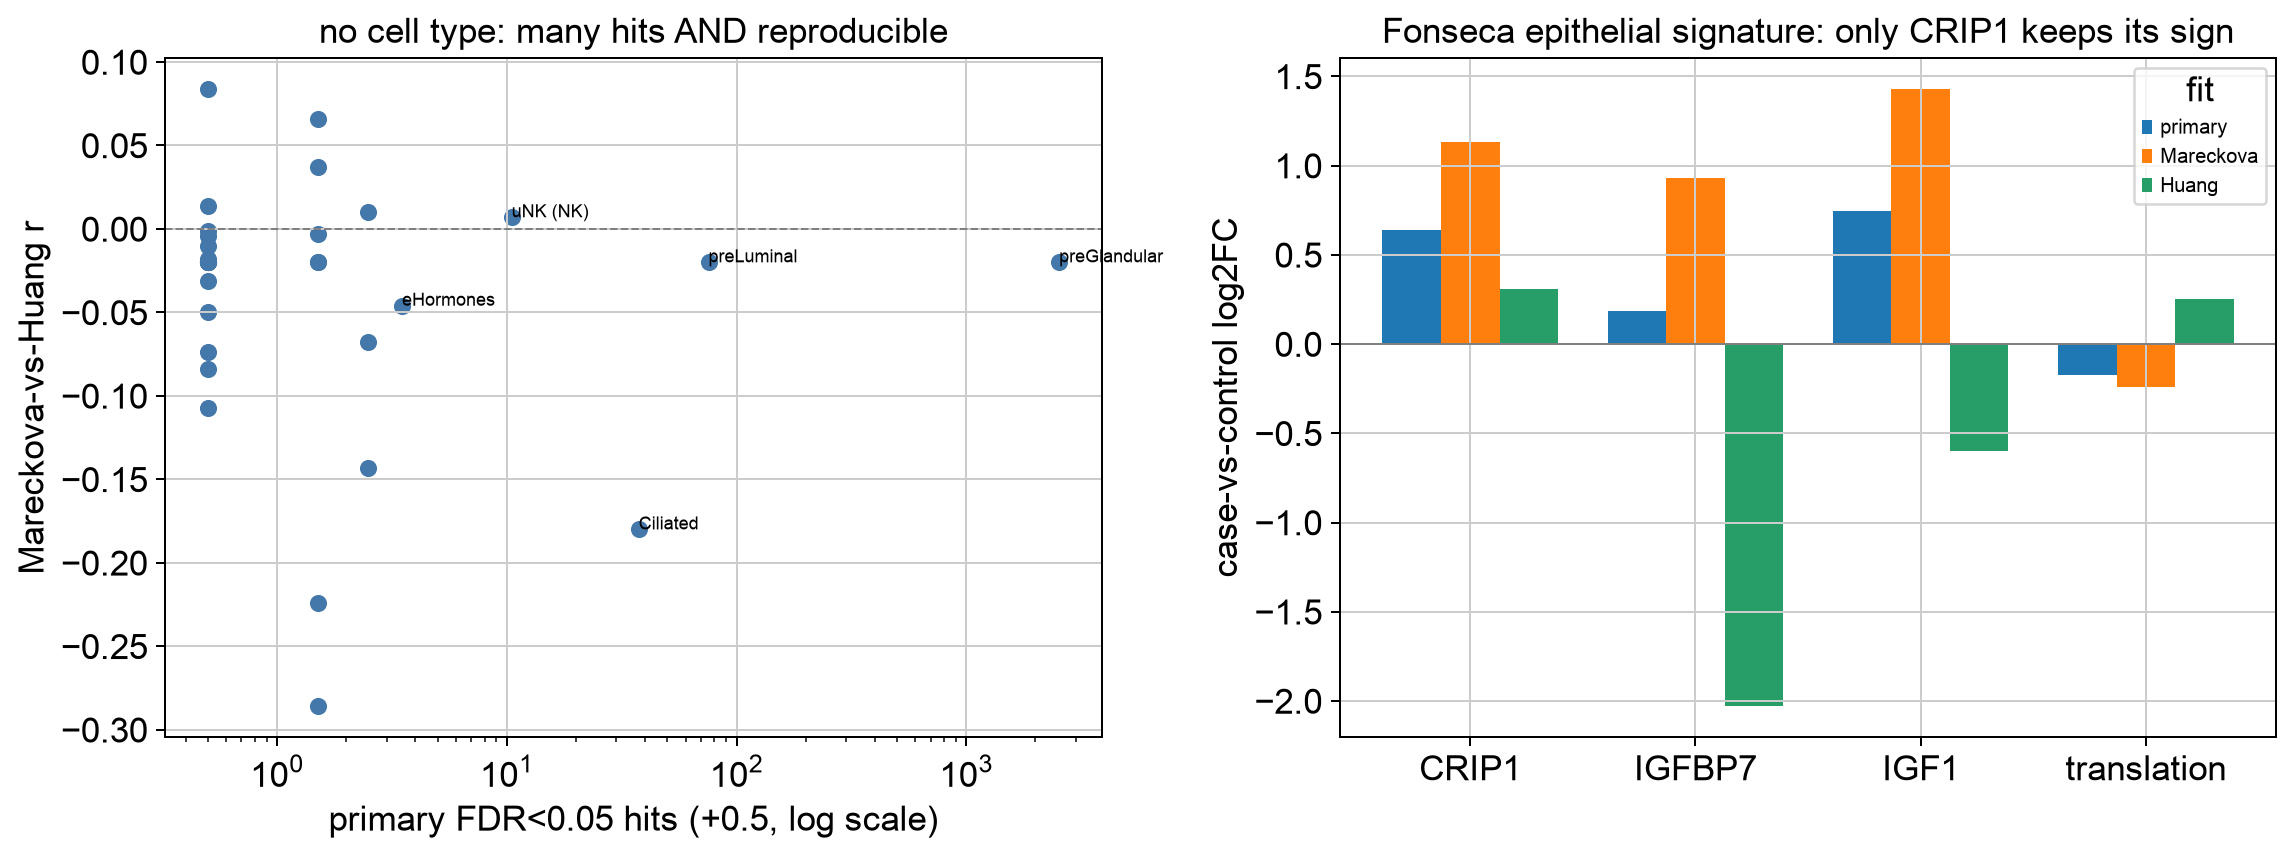

In [34]:
# Fonseca localized the superficial-lesion signature to endometrial-type EPITHELIUM. Test it on the
# whole epithelial compartment here (more power): CRIP1, IGFBP7, and a translation/ribosomal program,
# in the pooled batch-controlled fit and in each dataset alone.
epi = use[use.obs[LINEAGE_COL].astype(str) == "Epithelial"].copy()
cc, mm = _celltype_pb(epi)
eP = _de(cc, mm, mm.index[mm[DATASET_COL].isin(BOTH_ARM)], [DATASET_COL, "hormone"])
eM = _de(cc, mm, mm.index[mm[DATASET_COL]=="Mareckova"], ["hormone"])
eH = _de(cc, mm, mm.index[mm[DATASET_COL]=="Huang"], [])
_c = eM.index.intersection(eH.index); epi_r = np.corrcoef(eM.loc[_c,"log2FC"], eH.loc[_c,"log2FC"])[0,1]
transl = [g for g in cc.columns if g.startswith(("RPS","RPL"))]                      # translation program
_fc = lambda r, s: (r.loc[s,"log2FC"] if (r is not None and s in r.index) else np.nan)
_pv = lambda r, s: (r.loc[s,"pvalue"] if (r is not None and s in r.index) else np.nan)

genes = ["CRIP1","IGFBP7","IGF1","IGFBP1","PAEP","SLPI"]
tab = pd.DataFrame({"primary log2FC":[_fc(eP,g) for g in genes], "primary p":[_pv(eP,g) for g in genes],
                    "Mareckova log2FC":[_fc(eM,g) for g in genes], "Huang log2FC":[_fc(eH,g) for g in genes]},
                   index=genes)
tab.loc["translation(RPS/RPL) mean"] = [eP.reindex(transl)["log2FC"].mean(), np.nan,
                                        eM.reindex(transl)["log2FC"].mean(), eH.reindex(transl)["log2FC"].mean()]
print(f"epithelial compartment: {epi.n_obs} cells, {epi.obs[DONOR_COL].nunique()} donors")
print(f"whole-transcriptome Mareckova-vs-Huang r = {epi_r:.2f}  (anti-correlated, like every other compartment)")
print("Fonseca superficial-epithelium signature, tested in HECA eutopic epithelium:")
display(tab.round(3))

# figure: (A) every cell type -- hits vs reproducibility; (B) the Fonseca genes across the two datasets
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].scatter(scan["hits_FDR05"] + 0.5, scan["Mar_Huang_r"].fillna(-0.02), s=34, c="#4477aa")
ax[0].set_xscale("log"); ax[0].axhline(0, color="grey", lw=0.8, ls="--")
for ct in scan.sort_values("hits_FDR05").tail(5).index:
    ax[0].annotate(ct, (scan.loc[ct,"hits_FDR05"] + 0.5, scan["Mar_Huang_r"].fillna(-0.02)[ct]), fontsize=7)
ax[0].set_xlabel("primary FDR<0.05 hits (+0.5, log scale)"); ax[0].set_ylabel("Mareckova-vs-Huang r")
ax[0].set_title("no cell type: many hits AND reproducible")
labels = ["CRIP1","IGFBP7","IGF1","translation"]
series = {"primary":  [_fc(eP,"CRIP1"),_fc(eP,"IGFBP7"),_fc(eP,"IGF1"),eP.reindex(transl)["log2FC"].mean()],
          "Mareckova":[_fc(eM,"CRIP1"),_fc(eM,"IGFBP7"),_fc(eM,"IGF1"),eM.reindex(transl)["log2FC"].mean()],
          "Huang":    [_fc(eH,"CRIP1"),_fc(eH,"IGFBP7"),_fc(eH,"IGF1"),eH.reindex(transl)["log2FC"].mean()]}
x = np.arange(len(labels)); w = 0.26
for i,(k,v) in enumerate(series.items()): ax[1].bar(x + (i-1)*w, v, w, label=k)
ax[1].axhline(0, color="grey", lw=0.8); ax[1].set_xticks(x); ax[1].set_xticklabels(labels)
ax[1].set_ylabel("case-vs-control log2FC"); ax[1].legend(fontsize=8, title="fit")
ax[1].set_title("Fonseca epithelial signature: only CRIP1 keeps its sign")
plt.tight_layout(); plt.show()

Two things come out of the full scan.

First, **no cell type yields a reproducible disease signature.** The cell types with the most differentially expressed genes (pre-glandular, pre-luminal, ciliated epithelium) are exactly the ones whose control arm is thin in the smaller both-arm datasets, so those large hit counts are within-dataset artifacts that cannot be cross-validated (their reproducibility r is undefined or negative). Across every cell type the Mareckova-vs-Huang fold-change correlation stays near or below zero. This is the section-5 negative made comprehensive: the confounding is not specific to the macrophage and stromal compartments, it is a property of the atlas.

Second, the externally-defined Fonseca signature only partly survives. In the epithelial compartment the whole-transcriptome fold-changes still anti-correlate between the two datasets, and IGFBP7, IGF1 and the translation program all flip sign from one dataset to the other. **CRIP1 is the single exception:** it is case-up in the pooled fit and keeps its direction in both datasets (strongly in Mareckova, weakly in Huang), echoing Fonseca's superficial-lesion epithelium even though the tissue here is eutopic. It is a suggestive lead, not an established signature, being nominally significant rather than genome-wide, and carried mostly by one dataset.

So the least-worst answer to "which cell type, which signature" is: **endometrial secretory/luminal epithelium, marked by CRIP1**, offered as a hypothesis to test rather than a result this atlas establishes.

### 5i. A bulk EndMT signature under single-cell resolution (Liang et al. 2025)

Liang et al. (*Sci Rep* 2025) report an endothelial-mesenchymal transition (EndMT) signature in **bulk** eutopic endometrium (GSE120103, 18 vs 18), with hub genes FGF2, ITGB1, VIM, NR4A1, MAPK1, SMAD1, TUBB3 and CDH11, and propose FGF2 -> TGF-beta/SMAD as the driver of an endothelial-to-mesenchymal shift. Bulk tissue cannot separate true EndMT (endothelial cells acquiring a mesenchymal program) from ordinary stromal signal, because these genes are also highly expressed in the large mesenchymal compartment. Single-cell can, so this section asks two things: are the EndMT genes dysregulated **specifically in endothelial cells** (Venous/Arterial/Lymphatic), and does any of it hold to the same cross-dataset reproducibility bar used throughout section 5? (`_celltype_pb`/`_de` are the pseudobulk + DESeq2 helpers defined in 5h.)

In [35]:
# Liang et al. 2025 EndMT hub genes, tested at single-cell resolution. Bulk cannot tell EndMT
# (endothelium turning mesenchymal) from stromal signal because these genes are highly expressed in
# the large stromal compartment; single-cell can. Test them (i) in the endothelial compartment and
# (ii) in a whole-atlas pseudobulk (the single-cell analog of Liang's bulk contrast), each with the
# same cross-dataset reproducibility bar.
import scipy.sparse as sp
LIANG_HUB = ["FGF2","ITGB1","VIM","NR4A1","MAPK1","SMAD1","TUBB3","CDH11"]        # Liang hub genes
ENDO_ID = [g for g in ["CLDN5","PECAM1","CDH5","VWF"] if g in use.var_names]       # endothelial identity
MESEN   = [g for g in ["VIM","CDH2","CDH11","FN1","ACTA2","TAGLN","COL1A1","COL3A1"] if g in use.var_names]

# (i) endothelial compartment: primary (batch-controlled, hormone-adjusted) + each dataset alone
endo = use[use.obs[LINEAGE_COL].astype(str) == "Endothelial"]
cc, mm = _celltype_pb(endo)
nP = _de(cc, mm, mm.index[mm[DATASET_COL].isin(BOTH_ARM)], [DATASET_COL, "hormone"])
nM = _de(cc, mm, mm.index[mm[DATASET_COL] == "Mareckova"], ["hormone"])
nH = _de(cc, mm, mm.index[mm[DATASET_COL] == "Huang"], [])
_c = nM.index.intersection(nH.index); endo_r = np.corrcoef(nM.loc[_c,"log2FC"], nH.loc[_c,"log2FC"])[0,1]
_g = lambda r, s: (r.loc[s,"log2FC"] if (r is not None and s in r.index) else np.nan)
_p = lambda r, s: (r.loc[s,"pvalue"] if (r is not None and s in r.index) else np.nan)

# (ii) whole-atlas pseudobulk = single-cell analog of Liang's bulk endometrium contrast
cc2, mm2 = _celltype_pb(use)
bP = _de(cc2, mm2, mm2.index[mm2[DATASET_COL].isin(BOTH_ARM)], [DATASET_COL, "hormone"])

endmt = pd.DataFrame({
    "endo primary lfc":[_g(nP,g) for g in LIANG_HUB], "endo primary p":[_p(nP,g) for g in LIANG_HUB],
    "endo Mareckova":[_g(nM,g) for g in LIANG_HUB], "endo Huang":[_g(nH,g) for g in LIANG_HUB],
    "whole-atlas lfc":[_g(bP,g) for g in LIANG_HUB], "whole-atlas p":[_p(bP,g) for g in LIANG_HUB],
}, index=LIANG_HUB).round(3)
print(f"endothelial cells {endo.n_obs}, donors {endo.obs[DONOR_COL].nunique()}; "
      f"endothelial whole-transcriptome Mareckova-vs-Huang r = {endo_r:.2f}")
print("Liang EndMT hub genes -- endothelial-specific DE vs whole-atlas pseudobulk (case-vs-control):")
display(endmt)

# where do the EndMT genes actually live? mean log-norm by lineage -- the key disambiguation
show = [g for g in LIANG_HUB + ["CLDN5","PECAM1","VWF","DCN","PDGFRB"] if g in use.var_names]
Xg = use[:, show].X; Xg = Xg.toarray() if sp.issparse(Xg) else np.asarray(Xg)
bylin = pd.DataFrame(Xg, columns=show).groupby(use.obs[LINEAGE_COL].astype(str).values).mean().round(2)
print("mean log-norm expression by lineage -- VIM/CDH11/FGF2 are stromal, not endothelial:")
display(bylin)

# EndMT directional score (mesenchymal-up minus endothelial-down) in endothelial cells, case vs control
Xm = endo[:, MESEN].X; Xe = endo[:, ENDO_ID].X
Xm = Xm.toarray() if sp.issparse(Xm) else np.asarray(Xm)
Xe = Xe.toarray() if sp.issparse(Xe) else np.asarray(Xe)
sdf = pd.DataFrame({"score": Xm.mean(1) - Xe.mean(1), "condition": endo.obs["condition"].astype(str).values,
                    "dataset": endo.obs[DATASET_COL].astype(str).values, "donor": endo.obs[DONOR_COL].astype(str).values})
perdon = sdf.groupby(["dataset","donor","condition"], observed=True)["score"].mean().reset_index()
print("per-donor EndMT score, case vs control (both-arm datasets) -- no consistent case-up shift:")
display(perdon[perdon["dataset"].isin(BOTH_ARM)].groupby(["dataset","condition"], observed=True)["score"].mean().unstack().round(3))

endothelial cells 13387, donors 74; endothelial whole-transcriptome Mareckova-vs-Huang r = -0.07
Liang EndMT hub genes -- endothelial-specific DE vs whole-atlas pseudobulk (case-vs-control):


,endo primary lfc,endo primary p,endo Mareckova,endo Huang,whole-atlas lfc,whole-atlas p
FGF2,0.261,0.584,-0.022,-0.121,0.300,0.602
ITGB1,0.125,0.230,0.084,0.304,0.113,0.380
VIM,-0.038,0.752,-0.229,0.423,0.052,0.853
NR4A1,0.113,0.770,0.255,0.738,-0.641,0.104
MAPK1,0.082,0.403,-0.046,0.253,0.153,0.113
SMAD1,0.074,0.509,0.015,0.029,-0.214,0.163
TUBB3,-0.084,0.759,-0.502,0.571,-0.235,0.548
CDH11,-0.113,0.663,0.008,0.204,0.178,0.771


mean log-norm expression by lineage -- VIM/CDH11/FGF2 are stromal, not endothelial:


,FGF2,ITGB1,VIM,NR4A1,MAPK1,SMAD1,TUBB3,CDH11,CLDN5,PECAM1,VWF,DCN,PDGFRB
Endothelial,0.07,1.99,3.57,0.83,0.35,1.35,0.21,0.40,1.17,1.62,2.27,0.12,0.02
Epithelial,0.01,1.31,1.80,1.30,0.28,0.22,0.14,0.01,0.01,0.01,0.01,0.08,0.01
Immune,0.01,0.94,2.66,0.76,0.48,0.03,0.04,0.06,0.01,0.29,0.03,0.30,0.06
Mesenchymal,0.20,1.53,3.58,0.65,0.29,0.13,0.41,1.02,0.01,0.01,0.02,2.31,0.72


per-donor EndMT score, case vs control (both-arm datasets) -- no consistent case-up shift:


condition,case,control
dataset,,
Huang,-0.658,-0.568
Mareckova,-0.687,-0.656
Tan,-0.871,-1.072


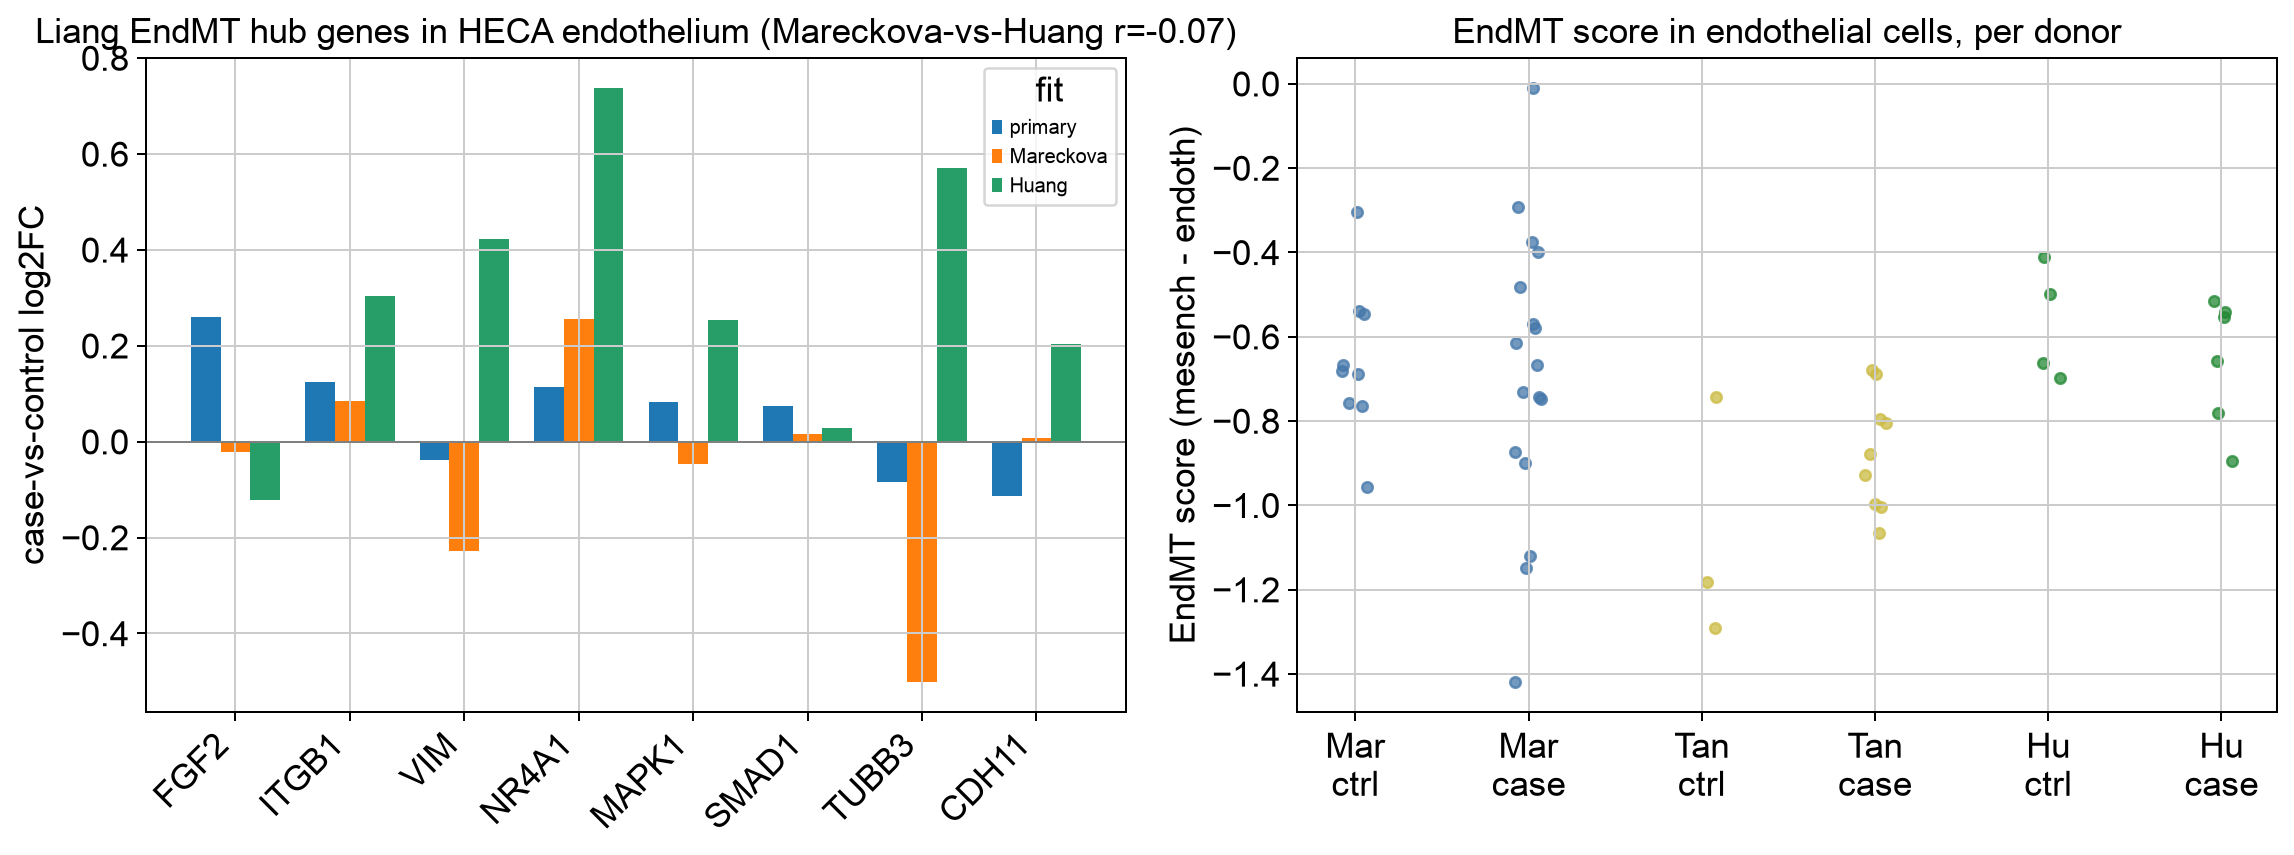

In [36]:
# (A) Liang hub genes in the endothelial compartment: do the two datasets even agree in direction?
# (B) EndMT score per endothelial donor, case vs control, per dataset.
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
x = np.arange(len(LIANG_HUB)); w = 0.26
for i, (k, col) in enumerate([("primary","endo primary lfc"), ("Mareckova","endo Mareckova"), ("Huang","endo Huang")]):
    ax[0].bar(x + (i-1)*w, endmt[col].values, w, label=k)
ax[0].axhline(0, color="grey", lw=0.8); ax[0].set_xticks(x); ax[0].set_xticklabels(LIANG_HUB, rotation=45, ha="right")
ax[0].set_ylabel("case-vs-control log2FC"); ax[0].legend(fontsize=8, title="fit")
ax[0].set_title(f"Liang EndMT hub genes in HECA endothelium (Mareckova-vs-Huang r={endo_r:.2f})")
palette = {"Mareckova":"#4477aa", "Tan":"#ccbb44", "Huang":"#228833"}; rng = np.random.default_rng(0)
for i, ds in enumerate(["Mareckova","Tan","Huang"]):
    d = perdon[perdon["dataset"] == ds]
    for j, cond in enumerate(["control","case"]):
        v = d[d["condition"] == cond]["score"].values
        ax[1].scatter(np.full(len(v), i*2 + j) + rng.uniform(-0.08, 0.08, len(v)), v, s=18, c=palette[ds], alpha=0.75)
ax[1].set_xticks(range(6)); ax[1].set_xticklabels(["Mar\nctrl","Mar\ncase","Tan\nctrl","Tan\ncase","Hu\nctrl","Hu\ncase"])
ax[1].set_ylabel("EndMT score (mesench - endoth)"); ax[1].set_title("EndMT score in endothelial cells, per donor")
plt.tight_layout(); plt.show()

The bulk EndMT signature does not transfer to HECA as a genuine endothelial transition. VIM, CDH11 and FGF2 are expressed mainly in the mesenchymal compartment, not the endothelium, so a whole-tissue increase in these genes in bulk endometrium is most parsimoniously stromal signal rather than endothelium turning mesenchymal. Tested where EndMT would actually occur, in endothelial cells, the hub genes are non-significant and point in opposite directions between Mareckova and Huang (whole-transcriptome r near zero). The whole-atlas pseudobulk (the single-cell analog of the bulk contrast) is mixed and mostly non-significant while the EndMT directional score does not increase in cases in any reproducible way. ITGB1 is the one hub gene with a weak case-up direction in endothelium in both datasets. Single-cell resolution reassigns a bulk "EndMT" signal to the stromal compartment, a distinction the bulk study could not make, and, consistent with every other externally-defined signature tested here, none of it survives the reproducibility requirement.

### 5j. Gene-set enrichment (GSEA): are subtle programs coordinately shifted, and do they reproduce?

Single-gene DE tests one gene at a time and module means average a handful; GSEA is more sensitive to a *coordinated* shift, which is what an early precursor signal would look like. It ranks the whole transcriptome by the case/control statistic and asks whether a program's genes sit toward the top (case-up) or bottom. We run a preranked GSEA on the DESeq2 Wald statistic, per compartment, against ten curated programs (EMT, TGF-β, inflammation, angiogenesis, hypoxia, EndMT, basalis/Wnt, decidualization, IGF-axis, secretory), motivated by the precursor hypothesis in section 6 (early fibrotic/EMT/growth remodeling in the functionalis and stroma). The enrichment score is implemented directly (weighted running-sum ES, gene-set permutation null) because `decoupler`'s GSEA returned only enrichment signs on these inputs. As everywhere, the bar is not significance in the pooled fit but **reproducibility**: does a program enrich in the same direction in both Mareckova and Huang?

In [37]:
# Preranked GSEA (weighted ES, gene-set permutation null) on the case/control DESeq2 Wald statistic,
# per compartment. Reuses _celltype_pb/_de from 5h. Reproducibility = same NES sign in Mareckova & Huang.
PROGRAMS = {
 "EMT":["VIM","FN1","CDH2","SNAI1","SNAI2","ZEB1","ZEB2","TWIST1","MMP2","MMP14","SPARC","TAGLN","ACTA2","S100A4","POSTN","LOXL1","LOXL2","TIMP1","COL1A1","COL1A2","COL3A1","COL5A1","COL6A3","FBN1","THBS1","THBS2","TGFBI","SERPINE1","FBLN1","LUM","DCN","ITGB1","CALD1","TPM1","TPM2","PDGFRB","CDH11","WNT5A","SPARCL1"],
 "TGFb":["TGFB1","TGFBR1","SMAD2","SMAD3","SMAD4","SMAD6","SMAD7","SERPINE1","SKIL","SKI","JUNB","ID1","ID2","ID3","THBS1","BMP2","BMPR2","LTBP2","PMEPA1","TGFBI","FURIN","WWTR1"],
 "Inflammatory":["IL1B","IL1A","IL6","TNF","CXCL8","CXCL1","CXCL2","CXCL3","CCL2","CCL20","PTGS2","NFKB1","NFKBIA","TNFAIP3","TNFAIP6","SOCS3","IL18","CCL5","CXCL10","CXCL11","IRF1","STAT1","ICAM1","SELE","TLR2","NLRP3","IL1R1","CSF1","PLAUR"],
 "Angiogenesis":["VEGFA","VEGFB","VEGFC","KDR","FLT1","PGF","ANGPT2","TEK","NRP1","ESM1","CDH5","DLL4","NOTCH4","HEY1","ROBO4","APLN","CXCR4","TIE1","PECAM1","VWF","CLDN5","ANGPT1"],
 "Hypoxia":["HIF1A","VEGFA","SLC2A1","LDHA","PGK1","ENO1","ALDOA","PDK1","CA9","BNIP3","ADM","EGLN3","NDRG1","HK2","PFKL","P4HA1","LOX","VLDLR","PLOD2","DDIT4"],
 "EndMT_Liang":["FGF2","ITGB1","VIM","NR4A1","MAPK1","SMAD1","TUBB3","CDH11","SOX4","SOX7","ROBO4","KITLG","PARP1","SNAI1","SNAI2","ZEB1","ACTA2","FN1","CDH2","TAGLN"],
 "Basalis_Wnt":["SOX9","CDH2","AXIN2","ALDH1A1","WNT7A","WNT5A","LGR5","TCF7L2","LEF1","ASCL2","RNF43","ZNRF3","NOTUM","BMP7","ID2","KRT5","TP63","WIF1","DKK1"],
 "Decidualization":["IGFBP1","PRL","DKK1","GREB1","LEFTY2","SMAD7","FOXO1","WNT4","HAND2","PROK1","LIF","IL15","SGK1","ZBTB16","HOXA10","HOXA11","CEBPB","BMP2"],
 "IGF_axis":["IGF1","IGF2","IGF1R","IGFBP1","IGFBP2","IGFBP3","IGFBP5","IGFBP7","INSR","IRS1","IRS2","IGF2R","IGFBP4","IGFBP6","GREB1"],
 "Secretory_Fonseca":["CRIP1","IGFBP7","PAEP","SPP1","GPX3","DPP4","MT1F","MT1G","LGALS1","CXCL14","SCGB1D2","SCGB2A1","SCGB2A2","MUC1","LIF"],
}
PROGRAMS = {k:[g for g in v if g in use.var_names] for k,v in PROGRAMS.items()}

def _prerank(stat, nperm=1000, seed=SEED):
    """preranked GSEA: NES = ES / mean(|ES_null| of same sign), p empirical (gene-set permutation)."""
    r = stat.dropna().sort_values(ascending=False)
    genes = r.index.to_numpy(); w = np.abs(r.to_numpy()); N = len(genes)
    posd = {g: i for i, g in enumerate(genes)}; rng = np.random.default_rng(seed)
    def es(idx):
        k = len(idx); hit = np.zeros(N); hit[idx] = w[idx]; hs = hit.sum()
        if hs == 0: return 0.0
        run = np.cumsum(hit/hs - (np.full(N, 1.0/(N-k)) * (hit == 0)))
        return run[np.argmax(np.abs(run))]
    out = {}
    for name, gs in PROGRAMS.items():
        idx = np.array([posd[g] for g in gs if g in posd], dtype=int)
        if len(idx) < 5: out[name] = (np.nan, np.nan); continue
        e = es(idx); null = np.array([es(rng.choice(N, len(idx), replace=False)) for _ in range(nperm)])
        same = null[null >= 0] if e >= 0 else null[null < 0]
        out[name] = (e/np.mean(np.abs(same)) if len(same) else np.nan,
                     ((np.sum(null >= e) if e >= 0 else np.sum(null <= e)) + 1)/(nperm+1))
    return out
def _gsea(res): return None if res is None else _prerank(res["stat"])

GCOMP = {"functionalis epi":["SOX9_functionalis_I","SOX9_functionalis_II","SOX9_luminal"],
 "glandular/luminal":["Glandular","Glandular_secretory","preGlandular","preLuminal","Luminal"],
 "eStromal":["eStromal","eStromal_MMPs","eStromal_cycling"], "dStromal":["dStromal_early","dStromal_mid","dStromal_late"],
 "endothelial":"ENDO", "whole-atlas":"ALL"}
grows = []
for cname, cells in GCOMP.items():
    sub = (use if cells == "ALL" else
           use[use.obs[LINEAGE_COL].astype(str) == "Endothelial"] if cells == "ENDO" else
           use[use.obs[CELLTYPE_COL].astype(str).isin(cells)])
    c, m = _celltype_pb(sub)
    P = _gsea(_de(c, m, m.index[m[DATASET_COL].isin(BOTH_ARM)], [DATASET_COL, "hormone"]))
    M = _gsea(_de(c, m, m.index[m[DATASET_COL] == "Mareckova"], ["hormone"]))
    H = _gsea(_de(c, m, m.index[m[DATASET_COL] == "Huang"], []))
    for s in PROGRAMS:
        grows.append((cname, s, round(P[s][0],2) if P else np.nan, round(P[s][1],3) if P else np.nan,
                      round(M[s][0],2) if M else np.nan, round(H[s][0],2) if H else np.nan))
gsea_res = pd.DataFrame(grows, columns=["compartment","program","NES_primary","p_primary","NES_Mar","NES_Hu"])
_ok = gsea_res[["NES_Mar","NES_Hu"]].notna().all(1)
gsea_res["concordant"] = np.where(_ok, np.where(np.sign(gsea_res["NES_Mar"]) == np.sign(gsea_res["NES_Hu"]), "same", "opp"), "-")
r_nes = np.corrcoef(gsea_res.loc[_ok,"NES_Mar"], gsea_res.loc[_ok,"NES_Hu"])[0,1]
print(f"programs significant in the pooled primary fit (p<0.05): {(gsea_res['p_primary']<0.05).sum()} of {len(gsea_res)}  "
      f"(GSEA is more sensitive than single-gene DE)")
print(f"but Mareckova-vs-Huang NES correlation = {r_nes:.2f}, and only {(gsea_res['concordant']=='same').sum()}/{int(_ok.sum())} "
      f"programs share a sign across the two datasets -- the pathway-level signal is dataset-confounded too.")
print("\nprograms significant in the primary fit AND case-up in BOTH datasets (the only directionally reproducible leads):")
display(gsea_res[(gsea_res.p_primary < 0.05) & (gsea_res.concordant == "same") & (gsea_res.NES_primary > 0)]
        [["compartment","program","NES_primary","p_primary","NES_Mar","NES_Hu"]].reset_index(drop=True))

programs significant in the pooled primary fit (p<0.05): 16 of 60  (GSEA is more sensitive than single-gene DE)
but Mareckova-vs-Huang NES correlation = -0.43, and only 22/60 programs share a sign across the two datasets -- the pathway-level signal is dataset-confounded too.

programs significant in the primary fit AND case-up in BOTH datasets (the only directionally reproducible leads):


,compartment,program,NES_primary,p_primary,NES_Mar,NES_Hu
0,functionalis epi,TGFb,1.35,0.045,0.90,1.63
1,functionalis epi,Angiogenesis,1.57,0.015,1.45,1.52
2,functionalis epi,IGF_axis,1.56,0.012,1.32,1.40
3,glandular/luminal,TGFb,1.47,0.033,1.59,0.80
4,dStromal,EndMT_Liang,1.49,0.034,1.22,1.35
5,endothelial,EMT,1.88,0.001,1.34,1.19
6,endothelial,Decidualization,1.67,0.013,1.13,0.95


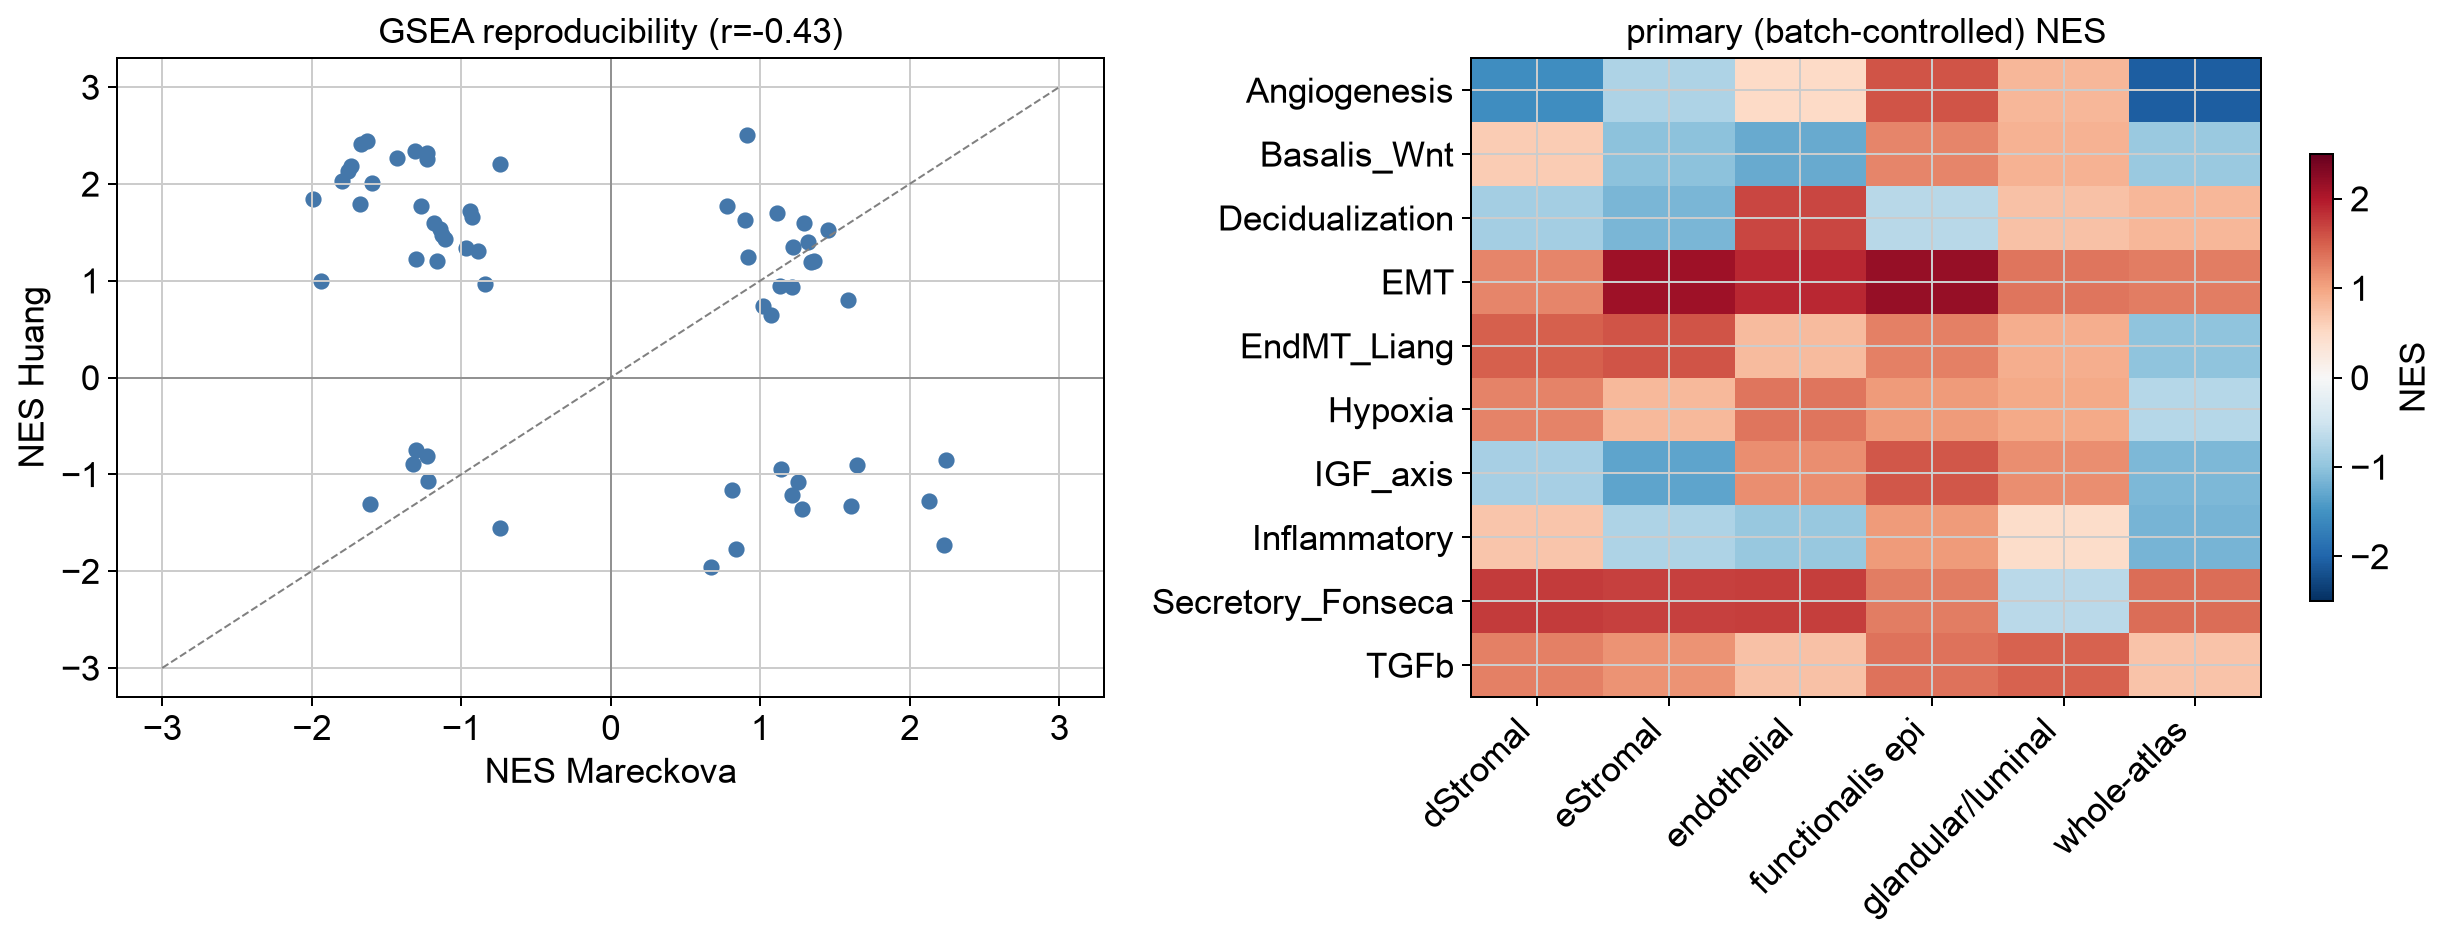

In [38]:
# (A) reproducibility: NES Mareckova vs NES Huang (off-diagonal = flips). (B) primary (pooled) NES heatmap.
fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))
ax[0].axhline(0, color="grey", lw=.6); ax[0].axvline(0, color="grey", lw=.6); ax[0].plot([-3,3],[-3,3],ls="--",color="grey",lw=.8)
ax[0].scatter(gsea_res.loc[_ok,"NES_Mar"], gsea_res.loc[_ok,"NES_Hu"], s=30, c="#4477aa")
ax[0].set_xlabel("NES Mareckova"); ax[0].set_ylabel("NES Huang"); ax[0].set_title(f"GSEA reproducibility (r={r_nes:.2f})")
piv = gsea_res.pivot(index="program", columns="compartment", values="NES_primary")
im = ax[1].imshow(piv.values, cmap="RdBu_r", vmin=-2.5, vmax=2.5, aspect="auto")
ax[1].set_xticks(range(len(piv.columns))); ax[1].set_xticklabels(piv.columns, rotation=45, ha="right")
ax[1].set_yticks(range(len(piv.index))); ax[1].set_yticklabels(piv.index)
ax[1].set_title("primary (batch-controlled) NES"); plt.colorbar(im, ax=ax[1], shrink=.7, label="NES")
plt.tight_layout(); plt.show()

GSEA is the most sensitive method applied here and it behaves accordingly: sixteen compartment-program combinations reach significance in the pooled, batch-controlled fit (the heatmap is mostly red, EMT and secretory especially). But the enrichment does not reproduce. Mareckova and Huang NES **anti-correlate** (r about −0.4), and fewer than half the programs even share a sign across the two datasets, the same dataset-confounding, now at the pathway level. The one biologically coherent exception sits exactly where section 6's precursor hypothesis predicts: in the **functionalis (SOX9) epithelium**, the TGF-β, angiogenesis and IGF-axis programs are all case-up in both datasets and significant in the primary fit, reading together as an early growth/remodeling program in the regenerative epithelium. With the overall anti-correlation and sixty tests, roughly this many concordant-and-significant hits are expected by chance, so it is a suggestive lead rather than an established signature, but the fact that the three cluster in one compartment along one coherent axis, rather than scattering, is what makes it worth naming. It is the honest best case: the most sensitive method finds a coherent early-TGF-β/growth program in exactly the compartment the tissue-of-origin logic points to, and it still does not clear the reproducibility bar in aggregate.

### 5k. Per-cell-type, within-dataset predictors: can any cell type classify endometriosis inside a single study?

Section 5e-ii asked whether a whole-transcriptome signature *transfers across* datasets (it does not). This asks the complementary, more forgiving question: within the single cleanest dataset (Mareckova), can a **per-cell-type** pseudobulk classifier even separate case from control? For each cell type we run leave-one-donor-out PLS-DA within Mareckova against a label-permutation null (is it separable at all?), then transfer the Mareckova-trained classifier to Huang (do the within-dataset predictors generalize?). If a real per-cell-type signal exists it should at least beat its own permutation null within Mareckova.

**Note:** I selected partial least squares discriminant analysis (PLS-DA) because of its historical performance (including my own experience) in identifying potential genomic biomarkers of interest from small n sample sizes.

In [39]:
# Per-cell-type WITHIN-Mareckova predictors. Leave-one-donor-out PLS-DA vs a label-permutation null,
# then transfer the Mareckova classifier to Huang. Pseudobulk = per-donor log-CPM within the cell type.
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

def _pb_logcpm(sub):
    C = fetch_counts(sub); don = sub.obs[DONOR_COL].astype(str).values
    cond = sub.obs["condition"].astype(str).values; dsv = sub.obs[DATASET_COL].astype(str).values
    mats, meta = [], []
    for d in pd.unique(don):
        i = np.where(don == d)[0]; mats.append(np.asarray(C[i].sum(0)).ravel()); meta.append((d, cond[i[0]], dsv[i[0]]))
    Mx = np.vstack(mats); cpm = Mx / np.clip(Mx.sum(1, keepdims=True), 1, None) * 1e6
    return np.log1p(cpm), pd.DataFrame(meta, columns=["donor","condition","dataset"]).set_index("donor")

def _hvg2(X, n=2000): v = X.var(0); return np.argsort(v)[::-1][:min(n, X.shape[1])]
def _lodo(X, y):                                     # leave-one-donor-out PLS-DA, HVG+scaler fit on train only
    n = len(y); pred = np.zeros(n)
    for i in range(n):
        tr = np.ones(n, bool); tr[i] = False; h = _hvg2(X[tr]); s = StandardScaler().fit(X[tr][:, h])
        pred[i] = PLSRegression(2).fit(s.transform(X[tr][:, h]), y[tr]*2.0-1).predict(s.transform(X[i:i+1][:, h])).ravel()[0]
    try: return roc_auc_score(y, pred)
    except Exception: return np.nan
def _transfer(Xtr, ytr, Xte, yte):
    h = _hvg2(Xtr); s = StandardScaler().fit(Xtr[:, h])
    p = PLSRegression(2).fit(s.transform(Xtr[:, h]), ytr*2.0-1).predict(s.transform(Xte[:, h])).ravel()
    try: return roc_auc_score(yte, p)
    except Exception: return np.nan

cts = use.obs["celltype_fine"].astype(str); rngk = np.random.default_rng(SEED); NPERM = 100; prows = []
for ct in cts.value_counts().index:
    sub = use[cts.values == ct]
    dd = sub.obs.groupby([DATASET_COL, "condition"], observed=True)[DONOR_COL].nunique().unstack(fill_value=0)
    gg = lambda ds, c: int(dd.loc[ds].get(c, 0)) if ds in dd.index else 0
    if not (gg("Mareckova","case") >= 4 and gg("Mareckova","control") >= 4 and gg("Huang","case") >= 3 and gg("Huang","control") >= 3):
        continue
    X, meta = _pb_logcpm(sub)
    Mi = meta["dataset"].values == "Mareckova"; Hi = meta["dataset"].values == "Huang"
    XM, yM = X[Mi], (meta["condition"].values[Mi] == "case").astype(int)
    XH, yH = X[Hi], (meta["condition"].values[Hi] == "case").astype(int)
    obs_auc = _lodo(XM, yM); null = np.array([_lodo(XM, rngk.permutation(yM)) for _ in range(NPERM)])
    prows.append((ct, int(Mi.sum()), round(obs_auc,2), round(float(np.nanmean(null)),2),
                  round((np.sum(null >= obs_auc)+1)/(NPERM+1),3), round(_transfer(XM, yM, XH, yH),2)))
pred = pd.DataFrame(prows, columns=["celltype","Mar_donors","withinMar_LODO_AUC","perm_null_AUC","perm_p","MarToHuang_AUC"])
print(f"cell types tested: {len(pred)} | separable within Mareckova (LODO beats label-permutation null, p<0.05): "
      f"{(pred['perm_p']<0.05).sum()} of {len(pred)}")
print(f"median Mareckova->Huang transfer AUC = {pred['MarToHuang_AUC'].median():.2f} (0.5 = chance); "
      f"within-Mar AUC vs transfer AUC correlation r = {np.corrcoef(pred['withinMar_LODO_AUC'],pred['MarToHuang_AUC'])[0,1]:.2f}")
display(pred.sort_values("perm_p").reset_index(drop=True))

cell types tested: 21 | separable within Mareckova (LODO beats label-permutation null, p<0.05): 1 of 21
median Mareckova->Huang transfer AUC = 0.46 (0.5 = chance); within-Mar AUC vs transfer AUC correlation r = 0.10


,celltype,Mar_donors,withinMar_LODO_AUC,perm_null_AUC,perm_p,MarToHuang_AUC
0,Arterial,20,0.62,0.33,0.040,0.75
1,DC,18,0.62,0.30,0.069,0.83
2,Ciliated,23,0.63,0.37,0.129,0.29
3,Cycling,26,0.64,0.44,0.168,0.28
4,dStromal_early,19,0.51,0.32,0.168,0.42
5,eHormones,33,0.52,0.41,0.257,0.46
6,ePV_2,24,0.47,0.34,0.267,0.33
7,uNK (NK),30,0.49,0.39,0.277,0.21
8,SOX9_functionalis_II,28,0.40,0.35,0.426,0.33
9,Venous,25,0.39,0.36,0.436,0.62


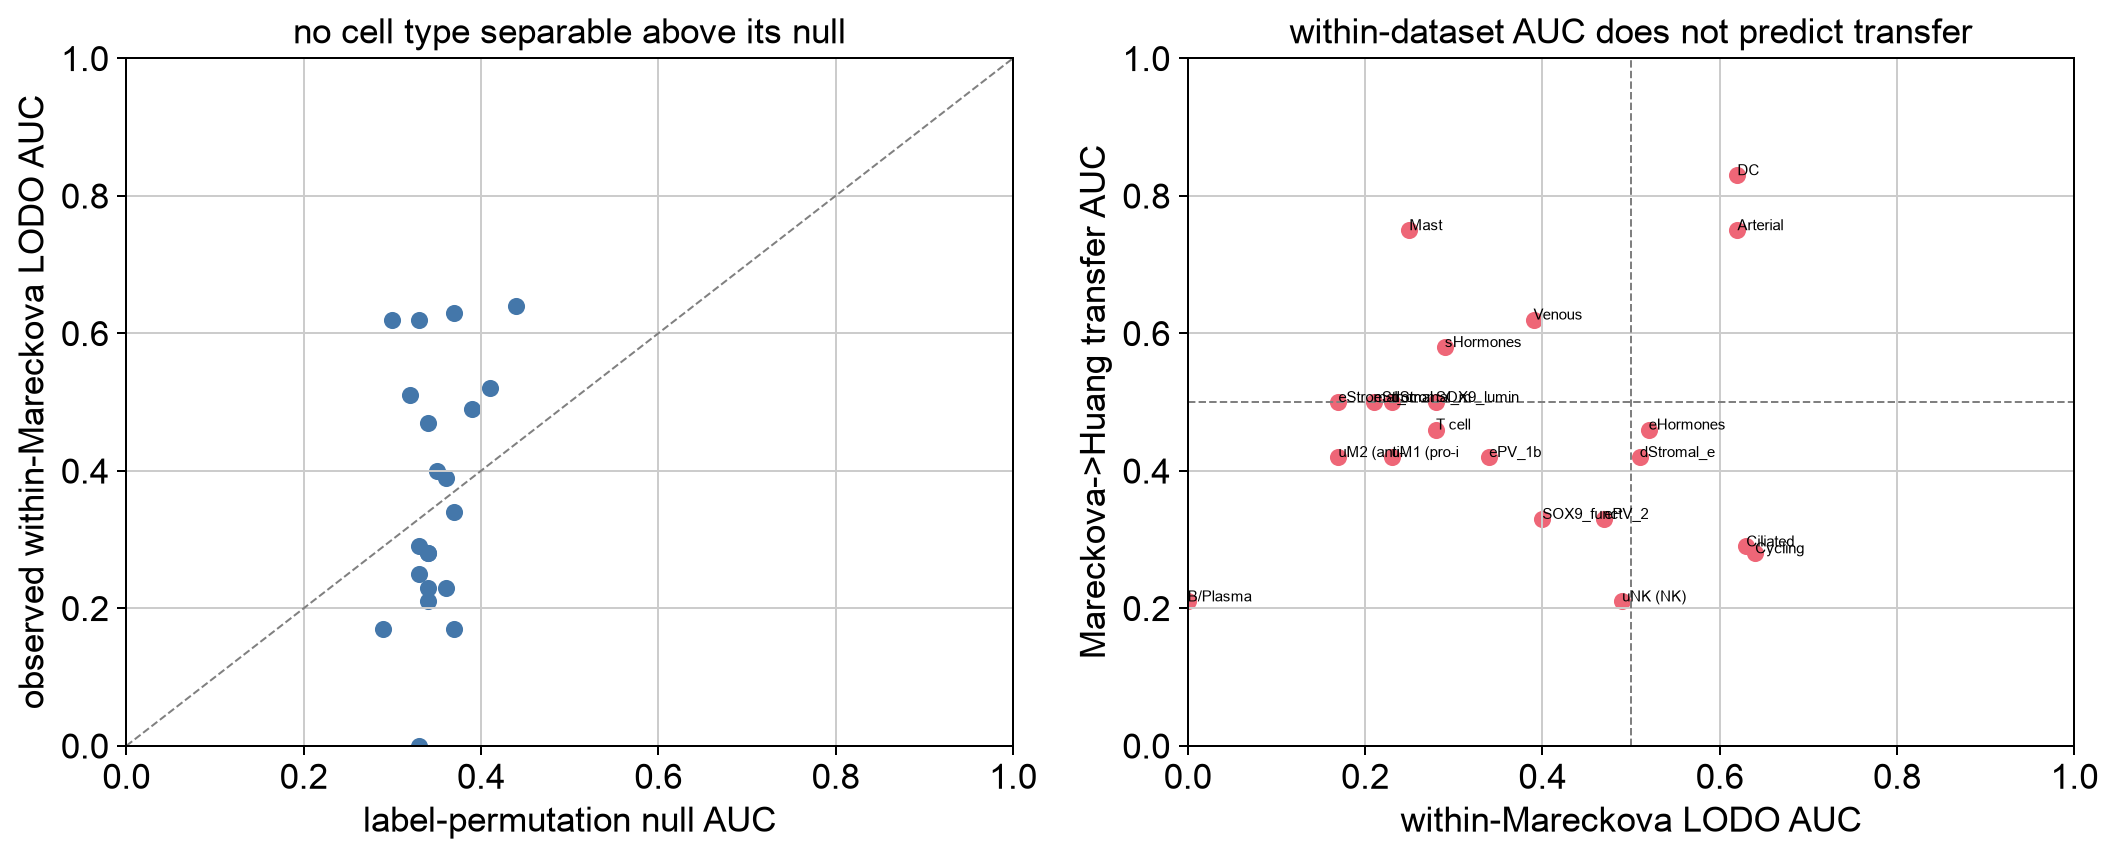

In [40]:
# (A) observed within-Mareckova LODO AUC vs its permutation-null mean (on the diagonal = not separable).
# (B) within-Mareckova AUC vs Mareckova->Huang transfer AUC (both clustered at chance).
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot([0,1],[0,1],ls="--",color="grey",lw=.8); ax[0].scatter(pred["perm_null_AUC"], pred["withinMar_LODO_AUC"], s=34, c="#4477aa")
ax[0].set_xlabel("label-permutation null AUC"); ax[0].set_ylabel("observed within-Mareckova LODO AUC")
ax[0].set_title("no cell type separable above its null"); ax[0].set_xlim(0,1); ax[0].set_ylim(0,1)
ax[1].axhline(0.5,color="grey",lw=.8,ls="--"); ax[1].axvline(0.5,color="grey",lw=.8,ls="--")
ax[1].scatter(pred["withinMar_LODO_AUC"], pred["MarToHuang_AUC"], s=34, c="#ee6677")
for _,r in pred.iterrows(): ax[1].annotate(r["celltype"][:10], (r["withinMar_LODO_AUC"], r["MarToHuang_AUC"]), fontsize=6)
ax[1].set_xlabel("within-Mareckova LODO AUC"); ax[1].set_ylabel("Mareckova->Huang transfer AUC")
ax[1].set_title("within-dataset AUC does not predict transfer"); ax[1].set_xlim(0,1); ax[1].set_ylim(0,1)
plt.tight_layout(); plt.show()

The result from this approach is also null. Of twenty-one cell types, exactly one (arterial endothelium) reaches nominal within-Mareckova significance (permutation p = 0.04). The two cell types with the highest transfer AUC (arterial endothelium 0.75, dendritic cells 0.83) are both small, noisy compartments and are not backed by within-Mareckova separability above its null AUC that would survive multiple testing. Across the board the median Mareckova-to-Huang transfer AUC is 0.46 (chance), and within-Mareckova separability does not predict transfer (r about 0.1). So a per-cell-type pseudobulk classifier cannot reliably distinguish endometriosis from control even inside the single cleanest dataset, let alone carry predictors that generalize to a second one. Leave-one-donor-out on twenty to thirty donors is a demanding, low-power test, so this is consistent with a genuinely subtle-or-absent signal rather than proof of absence. However, taken with the differential expression (5b, 5h), abundance (8c), and enrichment (5j) results, the per-cell-type predictor view points the same way.

## 6. Biological insight and therapeutic hypothesis

### The insight
Endometriosis doesn't seem to be cell type specific. The pathology may arise from a rewiring of programs within endometrium cells, and the per-gene effects are small. Mareckova et al. claim rewiring of decidualized stromal cells and macrophages and read an IGF-axis signal from it (IGF1 up in uM2 macrophages, the IGF program shifting in stroma).

The insight this reanalysis adds is that **on this atlas that signal is an artifact**. The seven source datasets are partly separated by condition (several are entirely cases or entirely controls), so case/control differential expression pooled across them reports dataset-of-origin as disease. When the design instead adjusts for dataset (and for exogenous-hormone treatment, which is confounded with case status) and uses only datasets that contain both arms:

- IGF1 does not reach significance in uM2 macrophages, uM1 macrophages, or decidualized stroma. Unadjusted it is flat and adjusting for hormone treatment moves it toward the reference's case-up direction in every compartment, and in stroma under limma-voom (see section 8b) it reaches p about 0.10, the closest any test comes, but it never clears FDR and never reproduces across datasets.
- The macrophage compartment yields no genes at FDR < 0.05.
- The stromal IGF2 effect that looks strong in a naive contrast is a dataset main effect and disappears under adjustment.
- Fold-changes fit independently in the two both-arm datasets (Mareckova, Huang) do not correlate (Pearson r near zero), so there is no reproducible disease signature to point at. The residual stromal hits are few, do not reproduce genome-wide, and are dominated by tissue-handling (immediate-early) and epithelial-contamination genes and do not include IGF1 or IGF2.
- Differential abundance behaves the same way. A within-dataset Milo test (section 8c) finds many differentially abundant neighborhoods in Mareckova and none in Huang, and the per-cell-type abundance shifts anti-correlate between the two datasets.
- The same holds across **every cell type**, not just the implicated ones. Running the primary DE on all cell types (section 5h), none combines a real hit count with cross-dataset reproducibility. For instance, the cell types with the most hits are simply those with the thinnest control arm in the smaller datasets.

I think the hard truth here is that this atlas, analyzed with donor-level replication and batch control, does not support the IGF1 story and does not yield a robust within-cell-type disease program. A signal may exist, but the data as assembled cannot separate it from batch. This does not depend on the differential-expression methodology employed as I have reproduced Mareckova et al.'s own limma-voom with three metacells per donor (section 8b), which returns the same IGF1 null and the same pseudo-replication inflation of hit counts, so the divergence from the reference is its design and replication choices, not the method.

To answer the brief's request to name a dysregulated cell type and signature directly, the hypothesis this atlas supports is **endometrial secretory/luminal epithelium marked by CRIP1**, the one compartment where an externally-defined gene (Fonseca's superficial-lesion CRIP1) holds its case-up direction across the two independent datasets. However, I offer it only as a hypothesis to test, not as a target this atlas establishes, and I would not build a program on it without the confirmation set out below.

**There is also a tissue-level reason this atlas is signal-poor, beyond the batch confounding.** HECA is **eutopic** endometrium, the pre-lesion field rather than the lesion, so any real disease signal here would be an **early precursor** program, not the established phenotype ectopic-lesion studies (like Fonseca et al. 2023) read out. Under the retrograde-menstruation and tissue-injury-repair models, that precursor would most plausibly sit in the basalis stem/progenitor compartment (SOX9, CDH2, AXIN2, ALDH1A1), the regenerative SOX9+ functionalis epithelium, or at the epithelial-stromal junction where TGF-beta-driven EMT initiates. This atlas is poorly positioned to observe any of that. The cohort is superficial (functionalis) biopsies, so the basalis is barely sampled (SOX9_basalis is essentially absent from the largest both-arm dataset and could not be tested in section 5h), and the epithelial-stromal junction is a spatial structure that dissociation destroys. Searching the compartments that *are* sampled with progressively more sensitive methods -- differential abundance (8c), an all-cell-type scan (5h), an external EndMT signature (5i), and coordinated-program GSEA (5j) -- the strongest and only directionally-reproducible hint is a TGF-beta / angiogenesis / IGF-axis program that is case-up in the functionalis epithelium of both datasets. That is consistent with an early remodeling signature in the regenerative epithelium, but it is faint and does not clear the reproducibility bar.

### A therapeutic hypothesis
The task asks for a potential therapeutic intervention. **IGF-1R inhibition remains a defensible hypothesis, but it rests on external evidence, not on this dataset**, and the two should not be conflated:

- **What supports it, independent of this atlas:** Forster et al. 2019 identified macrophage-derived IGF1 as a nerve-sensitizing factor in endometriosis, showing in a mouse model and in human tissue that disease-modified macrophages upregulate IGF1, that peritoneal-fluid IGF1 concentration correlates with patient pain scores, and that macrophage-derived IGF1 drives sprouting neurogenesis and sensitization in vitro. The IGF-1R inhibitor **linsitinib** partially reversed pain behavior in that mouse model (it reduced spontaneous abdominal grooming, though not every pain readout), and linsitinib carries clinical-stage safety and PK data from oncology trials, with the caveat that the IGF-1R class largely failed on efficacy there. Current hormonal therapies have real limitations for pain (recurrence on discontinuation, tolerability, incompatibility with conception, and a non-responding subset), and pain correlates poorly with lesion burden, which is what makes a peripheral neuro-immune target attractive. The IGF axis also recurs across independent single-cell studies (IGF1 in the reference; IGFBP7 and proliferative-stroma IGF1 in Fonseca et al. 2023), which is what keeps it a coherent node even though no single dataset reproduces it cleanly.
- **What this atlas does not provide:** the transcriptomic anchor for this hypothesis. Once the analysis controls for batch and for exogenous-hormone treatment, the IGF1 upregulation disappears. So IGF-1R should be carried as a mechanism-and-pain hypothesis to be tested directly, not as a target this dataset nominates.

### What it would take to nominate a target credibly from data like this
The more transferable deliverable from this reanalysis is the study and analysis design it implies:

1. **Balance condition within batch, and treatment across arms.** Case and control samples processed in the same datasets/runs, so dataset-of-origin is not confounded with condition, and exogenous-hormone treatment distributed across both arms (here it fell almost entirely on cases and had to be modeled as a covariate rather than balanced by design). This is what makes the DE interpretable.
2. **Matched processing across arms.** Consistent dissociation and handling, since immediate-early and stress genes (which dominate the residual "signal" here) track handling, not disease.
3. **Batch-aware DE with reproducibility as the bar.** Donor-level pseudobulk, dataset in the model (or a mixed model with dataset as a random effect), and a cross-dataset reproducibility requirement before a gene is called, rather than significance in one pooled fit.
4. **The right compartment and stage, with adequate depth.** Ectopic/peritoneal lesion tissue rather than only eutopic endometrium, and enough macrophage and decidualized-stromal cells per donor per arm to power the subset contrasts (both were sparse per donor here). For the precursor question specifically, this means whole-thickness (basalis-inclusive) sampling rather than superficial functionalis biopsies, and **spatial transcriptomics** (Visium/Xenium) to resolve the epithelial-stromal junction that dissociation destroys.
5. **Orthogonal confirmation.** Protein and spatial validation (IGF1 ISH/IF in lesion macrophages adjacent to nerve fibers) and a macrophage-to-sensory-neuron functional assay with IGF-1R inhibition, to connect any transcriptomic node to the pain phenotype.

## 7. Reproducibility notes

- **Data:** ArrayExpress `E-MTAB-14039`, scRNA-seq arm only (single-nuclei out of scope). Two objects are supported via the Config `USE_FULL_ATLAS` switch: the ~90k Zenodo subset for fast iteration and the full 313k atlas for the definitive run.
- **Memory (full atlas on 16 GB):** the object is loaded in a frugal backed mode. Only the log-normalized `X` is held in RAM (~3.5 GB); raw counts stay on disk and are streamed per compartment for pseudobulk (`fetch_counts`). Peak RAM stays well under 16 GB, so the whole pipeline runs on the full object.
- **Seeds:** fixed (`SEED = 0`) for PCA/neighbors/UMAP/Leiden and Harmony.
- **Determinism:** UMAP/Leiden are seeded but remain sensitive to library versions; cluster indices may shift across environments. The annotation is marker-anchored, so labels are stable even if cluster numbers are not.
- **Compute:** reuses the shipped scVI/UMAP embedding; the only from-scratch integration is a Harmony re-clustering of the immune subset (small). No full re-integration of the 313k atlas is required.
- **Differential expression:** donor-level pseudobulk with DESeq2 (`pydeseq2`), design `~ dataset + condition` restricted to datasets with both arms, and a cross-dataset reproducibility check as the standard for a hit. Exogenous-hormone donors are **retained, not excluded**, and treatment is modeled as a covariate: the primary contrast is reported both without and with a `hormone` term (`~ dataset + condition` vs `~ dataset + hormone + condition`), since treatment is confounded with case status (it falls almost entirely on cases; see section 2). Section 5b varies replication (donor vs 3-metacell) and design (naive-pooled vs batch-controlled) to show which choices manufacture the reference's hits.
- **limma-voom cross-check (8b):** the reference's exact method (edgeR TMM into voom into eBayes) is reproduced via `rpy2` and Bioconductor `limma`/`edgeR`, and returns the same IGF1 null (including with the hormone term), confirming the divergence is design/replication, not the DE test. This cell requires a system R with `limma`/`edgeR` installed plus `rpy2` (in the `jupyter-mcp` dependency group); it self-skips with a note if they are absent, so the notebook still runs without an R toolchain.
- **Differential abundance (8c):** a Milo-style within-dataset test (kNN neighborhoods on the shipped scVI latent, edgeR NB-GLM `~ hormone + condition`), run inside single datasets to avoid the cross-dataset recovery confound and compared across Mareckova and Huang for reproducibility. Implemented directly against edgeR because `milopy`/`pertpy` do not install against this notebook's scanpy/anndata/pandas versions; FDR is standard Benjamini-Hochberg rather than Milo's spatial FDR. Shares the 8b R requirement and self-skips without it.
- **Cell-type scan and external signature (5h):** the primary DE is additionally run on every fine cell type with a per-cell-type Mareckova-vs-Huang reproducibility check, and the Fonseca et al. (2023) superficial-lesion epithelial markers (CRIP1, IGFBP7) plus a translation program are tested in the epithelial compartment. Section 4a cross-validates the shipped annotation against Fonseca's major-cell-type marker panel. Section 5i tests a bulk EndMT signature (Liang et al. 2025) in the endothelial compartment vs a whole-atlas pseudobulk, using single-cell resolution to separate true EndMT from bulk stromal signal.
- **Config:** the only cell requiring edits is **Config**; run the inspection cell first to confirm the `.obs` schema.

## 8. Supplementary analyses

These are robustness and method cross-checks referenced from the main text, relocated from Section 5 to keep the disease-signal argument compact. **8a** establishes the cross-dataset reproducibility standard used throughout (per-gene fold-changes fit independently in Mareckova and Huang do not correlate). **8b** rules out a differential-expression method difference by reproducing the reference's limma-voom. **8c** is the within-dataset differential-abundance (Milo) analysis. The analyses and figures are unchanged; only the section labels moved (5c/5d/5g -> 8a/8b/8c).

### 8a. Cross-dataset reproducibility

Adjusting for dataset removes the confounded main effect, but the strongest test of whether a
case/control difference is *disease* rather than *batch* is reproducibility: fit the contrast
**independently within each dataset that has both arms** (Mareckova and Huang) and ask whether the
per-gene fold-changes agree. A real disease signature should correlate positively across datasets;
batch and noise will not. This is the check the naive analysis (and the atlas-level DE) skips.

decidualized stroma, case-control log2FC across 12692 genes, Mareckova vs Huang:
  pearson r = -0.077   spearman = -0.024   (a reproducible disease signature would be strongly positive)


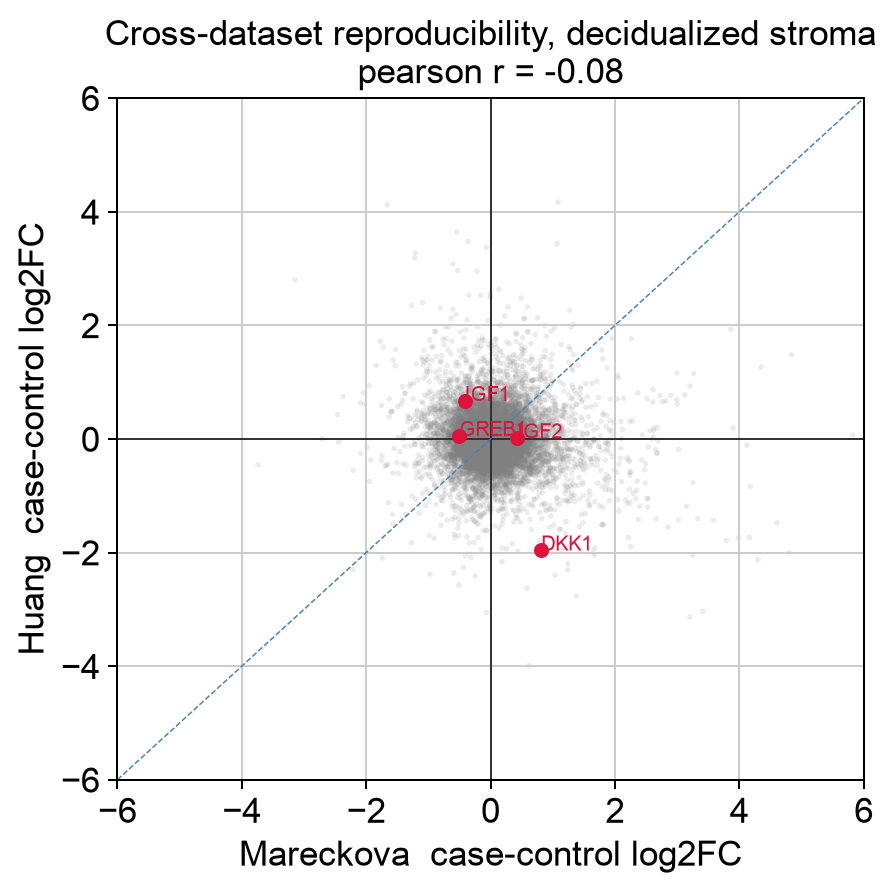

In [41]:
# Cross-dataset reproducibility in the best-powered compartment (decidualized stroma): fit case vs
# control WITHIN Mareckova and WITHIN Huang independently, then correlate the per-gene fold-changes.
from scipy.stats import pearsonr, spearmanr
sub = compartments["decidualized stroma"]
rM, rH = de_single_dataset(sub, "Mareckova"), de_single_dataset(sub, "Huang")
common = rM.index.intersection(rH.index)
x, y = rM.loc[common, "log2FC"], rH.loc[common, "log2FC"]
ok = np.isfinite(x) & np.isfinite(y); x, y = x[ok], y[ok]
pear, spear = pearsonr(x, y)[0], spearmanr(x, y)[0]
print(f"decidualized stroma, case-control log2FC across {len(x)} genes, Mareckova vs Huang:")
print(f"  pearson r = {pear:.3f}   spearman = {spear:.3f}   (a reproducible disease signature would be strongly positive)")

fig, ax = plt.subplots(figsize=(5.2, 5.2))
ax.scatter(x, y, s=5, alpha=0.15, color="grey", edgecolors="none")
for g in ["IGF1", "IGF2", "GREB1", "DKK1"]:
    if g in common:
        ax.scatter(rM.loc[g, "log2FC"], rH.loc[g, "log2FC"], color="crimson", s=25, zorder=3)
        ax.annotate(g, (rM.loc[g, "log2FC"], rH.loc[g, "log2FC"]), fontsize=8, color="crimson")
lim = 6
ax.axhline(0, lw=.6, color="k"); ax.axvline(0, lw=.6, color="k")
ax.plot([-lim, lim], [-lim, lim], lw=.6, ls="--", color="steelblue")
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.set_xlabel("Mareckova  case-control log2FC"); ax.set_ylabel("Huang  case-control log2FC")
ax.set_title(f"Cross-dataset reproducibility, decidualized stroma\npearson r = {pear:.2f}")
plt.tight_layout(); plt.show()

In [42]:
# Filter robustness: does re-applying the paper's stated 20% mito cut change the key genes? The
# 20-25% mito cells the object retains are ~0.7% and not IGF-driving, so it should not. Compare the
# primary donor/batch-controlled DE with and without the 20% cut, in each thesis compartment.
CHECK = {"uM2 macrophage": ["IGF1", "IL1B", "TNFRSF1B"], "decidualized stroma": ["IGF1", "IGF2", "DKK1"]}
for cname, genes in CHECK.items():
    full = de_ctrl[cname]
    sub  = compartments[cname]
    filt = run_de(sub[sub.obs["pct_counts_mito"] <= MAX_PCT_MITO].copy(), "donor", "controlled")
    tab = pd.DataFrame({
        "no-filter log2FC":            full.reindex(genes)["log2FC"],
        "no-filter p":                 full.reindex(genes)["pvalue"],
        f"<={MAX_PCT_MITO:.0f}% mito log2FC": (filt.reindex(genes)["log2FC"] if filt is not None else np.nan),
        f"<={MAX_PCT_MITO:.0f}% mito p":      (filt.reindex(genes)["pvalue"] if filt is not None else np.nan),
    }).round(3)
    print(f"=== {cname}: 20% mito filter vs no filter (primary donor / batch-controlled DE) ===")
    display(tab); print()

=== uM2 macrophage: 20% mito filter vs no filter (primary donor / batch-controlled DE) ===


,no-filter log2FC,no-filter p,<=20% mito log2FC,<=20% mito p
IGF1,0.152,0.734,0.151,0.736
IL1B,-0.719,0.151,-0.723,0.149
TNFRSF1B,0.218,0.222,0.210,0.245


=== decidualized stroma: 20% mito filter vs no filter (primary donor / batch-controlled DE) ===


,no-filter log2FC,no-filter p,<=20% mito log2FC,<=20% mito p
IGF1,0.172,0.616,0.172,0.617
IGF2,0.014,0.974,0.015,0.973
DKK1,0.128,0.865,0.124,0.869


### 8b. Ruling out a method difference: limma-voom reproduction

Everything above held the DE method at DESeq2, so a fair objection is that the IGF1 non-reproduction is just a DESeq2-vs-limma-voom artifact: the reference used **limma-voom** (edgeR TMM into voom into lmFit into eBayes) with three metacells per donor. This section reruns the same replication x design grid with the authors' exact method, via `rpy2` and Bioconductor `limma`/`edgeR`, so the method is no longer a confound.

Result: it is not the method. Under limma-voom, IGF1 is non-significant in every corner including the paper-like one (3-metacell, naive-pooled), and IGF2's stromal effect again lives only in the naive design and disappears under batch control. The pseudo-replication inflation is if anything larger under limma-voom for the well-powered stromal compartment. So the paper's IGF1 is not recovered by our pipeline under either method.

This cell requires R with `limma`/`edgeR` and `rpy2`; it prints a skip note and is a no-op if they are unavailable, so the rest of the notebook still runs without an R toolchain.

In [43]:
# limma-voom (the authors' method) via rpy2 + Bioconductor, to rule out a DE-method explanation.
# No-op with a note if R / limma / edgeR / rpy2 are unavailable, so the notebook still runs without them.
try:
    import rpy2.robjects as ro
    from rpy2.robjects import numpy2ri
    from rpy2.robjects.conversion import localconverter
    from rpy2.robjects.packages import importr
    importr("edgeR"); importr("limma")
    _HAVE_R = True
except Exception as e:
    _HAVE_R = False
    print("8b skipped: R with limma/edgeR and rpy2 not available (", type(e).__name__, ").")

if _HAVE_R:
    ro.r('''
    run_voom <- function(counts, cond, dataset, hormone, use_dataset, use_hormone) {
      suppressMessages({library(edgeR); library(limma)})
      cond <- factor(cond, levels=c("control","case"))        # coef 'condcase' = case vs control
      d <- calcNormFactors(DGEList(counts=counts))            # edgeR TMM
      terms <- "cond"
      if (use_hormone) terms <- c("factor(hormone)", terms)   # ~ [dataset +] [hormone +] cond
      if (use_dataset) terms <- c("factor(dataset)", terms)
      design <- model.matrix(as.formula(paste("~", paste(terms, collapse=" + "))))
      v <- voom(d, design); fit <- eBayes(lmFit(v, design))
      tt <- topTable(fit, coef="condcase", number=Inf, sort.by="none")   # sort.by="none" keeps input order
      data.frame(log2FC=tt$logFC, pvalue=tt$P.Value, padj=tt$adj.P.Val)
    }''')

    def run_de_limma(sub, replication="donor", design="controlled", adjust_hormone=False):
        """limma-voom analogue of run_de: same donor/metacell pseudobulk, naive/controlled design,
        and an optional treated/untreated term (added only when hormone varies)."""
        s = sub if design == "naive" else sub[sub.obs[DATASET_COL].astype(str).isin(BOTH_ARM)].copy()
        counts, meta = _pseudobulk(s, replication=replication)
        vc = meta["condition"].value_counts()
        if vc.get("case", 0) < 3 or vc.get("control", 0) < 3: return None
        expr = (counts > 0).sum(0) >= max(3, int(0.5 * counts.shape[0])); counts = counts.loc[:, expr]
        genes = counts.columns.to_list()
        use_horm = bool(adjust_hormone and meta["hormone"].nunique() > 1)
        cmat = np.ascontiguousarray(counts.T.to_numpy(dtype=float))          # genes x samples
        with localconverter(ro.default_converter + numpy2ri.converter):
            r_mat = ro.conversion.get_conversion().py2rpy(cmat)
        tt = ro.globalenv["run_voom"](r_mat, ro.StrVector(meta["condition"].astype(str).tolist()),
                                      ro.StrVector(meta[DATASET_COL].astype(str).tolist()),
                                      ro.StrVector(meta["hormone"].astype(str).tolist()),
                                      ro.vectors.BoolVector([design != "naive"]),
                                      ro.vectors.BoolVector([use_horm]))
        return pd.DataFrame({"log2FC": list(tt.rx2("log2FC")), "pvalue": list(tt.rx2("pvalue")),
                             "padj": list(tt.rx2("padj"))}, index=genes).sort_values("padj")

    _grid = [("metacell","naive"), ("donor","naive"), ("metacell","controlled"), ("donor","controlled")]
    _lab  = {("metacell","naive"):"3-mc/naive [paper-like]", ("donor","naive"):"donor/naive",
             ("metacell","controlled"):"3-mc/controlled", ("donor","controlled"):"donor/controlled [primary]"}
    _cand = {"uM2 macrophage": ["IGF1","IL1B","TNFRSF1B"], "decidualized stroma": ["IGF1","IGF2","GREB1","DKK1"]}
    for cname, genes in _cand.items():
        cols = {_lab[k]: run_de_limma(compartments[cname], *k).reindex(genes)
                        .apply(lambda x: f"{x['log2FC']:+.2f} (p={x['pvalue']:.3f})", axis=1) for k in _grid}
        print(f"=== limma-voom {cname}: log2FC (p) by replication x design ==="); display(pd.DataFrame(cols)); print()

    # limma-voom IGF1 under the primary design, without vs with the hormone term (mirrors DESeq2 in 5b)
    print("limma-voom IGF1, primary (donor / batch-controlled), without -> with hormone:")
    for cname in ["uM2 macrophage", "decidualized stroma"]:
        ru = run_de_limma(compartments[cname], "donor", "controlled", adjust_hormone=False)
        ra = run_de_limma(compartments[cname], "donor", "controlled", adjust_hormone=True)
        _f = lambda r: (f"{r.loc['IGF1','log2FC']:+.2f} (p={r.loc['IGF1','pvalue']:.3f})"
                        if r is not None and "IGF1" in r.index else "n/a")
        print(f"  {cname:22s} {_f(ru)}  ->  {_f(ra)}")

    # pseudo-replication inflation is present under both methods (magnitude differs by compartment)
    print("\ngenes at FDR<0.05  (DESeq2 / limma-voom):")
    _n = lambda r: (int((r["padj"] < 0.05).sum()) if r is not None else None)
    for cname, sub in compartments.items():
        print(f"  {cname:22s} paper-like: {_n(run_de(sub,'metacell','naive')):>4} / "
              f"{_n(run_de_limma(sub,'metacell','naive')):<5} primary: {_n(de_ctrl[cname]):>3} / "
              f"{_n(run_de_limma(sub,'donor','controlled'))}")

=== limma-voom uM2 macrophage: log2FC (p) by replication x design ===


,3-mc/naive [paper-like],donor/naive,3-mc/controlled,donor/controlled [primary]
IGF1,-0.12 (p=0.581),-0.31 (p=0.390),+0.13 (p=0.665),-0.07 (p=0.886)
IL1B,-0.17 (p=0.611),-0.71 (p=0.124),-0.04 (p=0.910),-0.53 (p=0.280)
TNFRSF1B,+0.27 (p=0.062),+0.10 (p=0.652),+0.26 (p=0.042),+0.25 (p=0.218)


=== limma-voom decidualized stroma: log2FC (p) by replication x design ===


,3-mc/naive [paper-like],donor/naive,3-mc/controlled,donor/controlled [primary]
IGF1,-0.12 (p=0.573),-0.26 (p=0.449),+0.47 (p=0.093),+0.11 (p=0.813)
IGF2,-0.69 (p=0.009),-0.67 (p=0.134),+0.68 (p=0.023),+0.80 (p=0.108)
GREB1,+0.39 (p=0.001),+0.39 (p=0.042),+0.14 (p=0.412),+0.07 (p=0.807)
DKK1,-0.09 (p=0.814),+0.04 (p=0.957),+0.53 (p=0.290),+0.71 (p=0.436)



limma-voom IGF1, primary (donor / batch-controlled), without -> with hormone:


...

  decidualized stroma    +0.11 (p=0.813)  ->  +0.63 (p=0.095)

genes at FDR<0.05  (DESeq2 / limma-voom):


  uM2 macrophage         paper-like:  180 / 219   primary:   0 / 0


  uM1 macrophage         paper-like: 1409 / 228   primary:   0 / 0


  macrophage (uM1+uM2)   paper-like:  741 / 247   primary:   0 / 0


  decidualized stroma    paper-like:  397 / 679   primary:   2 / 0


**A note on reproducing the reference's immune DE.** The reference's Fig. 5 macrophage result (IGF1 up in uM2/eM2) comes from a pipeline that can be read in full (`ventolab/Human-Endometrial-Cell-Atlas_HECA`, `Endometriosis_degs/Endometriosis_degs2_DEGanalysis_cells.ipynb`). Two things in that code explain why it does not reproduce here.

- **The DE is not corrected for dataset-of-origin.** The design that feeds the figure is `model.matrix(~ 0 + Group)` (Ctrl_Superficial vs Endo_Superficial), pooled across all seven datasets, with three random metacells per donor (`metacell_id = dataset-disease-celltype-genotype-random(1:3)`). There is no dataset covariate. The only "corrected" variant adds donor (`genotype`), which is nested within condition and is left commented out of the merged table (`Endometriosis_degs3_buildTable`). This is exactly the naive-pooled, 3-metacell corner of the grid above, where hit counts inflate and IGF1 sits near the significance boundary rather than clearly crossing it.

- **The eM1/eM2 cell definition is not in the public materials.** The DE runs on curated fine immune subclusters (eM1, eM2, uNK1-3, and ~15 others) that are read from an internal annotation file (`cells_endometrium_immune.csv`, an `/nfs/...` path). The repository ships an integration-and-clustering notebook for every other lineage (endothelial, epithelial, mesenchymal) but none for the immune compartment, and no code that writes those labels; the released `.h5ad` carries only the coarse `Immune_Myeloid`/`Immune_Lymphoid`. So the exact eM2 cells cannot be reconstructed from what was released. The de novo Harmony re-clustering in section 4b is the closest principled proxy.

Reproducing their exact method (limma-voom, 3-metacell, naive-pooled) on that proxy reaches IGF1 p ~ 0.16, and the residual gap to their reported hit is this cell-definition difference. The reference's headline immune result therefore rests on a batch-uncorrected, pseudo-replicated test applied to a cell subset that is not part of the public release, which is consistent with the negative reported here.

### 8c. Differential abundance within a dataset (Milo): does composition shift reproducibly?

Sections 5a–5f test differential *expression*. This section tests differential *abundance* with a Milo-style approach: build k-nearest-neighbor neighborhoods on the shipped scVI embedding, then test each neighborhood for a case/control difference in cell counts with edgeR's negative-binomial GLM. This asks, at finer resolution than discrete cell-type proportions, whether specific transcriptional states are over- or under-represented in disease.

The design choice that matters is to run it **within a single dataset**. Composition on this scRNA atlas is confounded by per-dataset recovery differences (section 5a), which is likely why the authors used single-nuclei data for differential abundance testing. Running the test inside one dataset removes that confound. As everywhere else in section 5, it adjusts for exogenous-hormone treatment (`~ hormone + condition`) where treatment varies. And as in 5b–5f the bar is not significance in one dataset but **reproducibility**: the identical test is run in Mareckova and in Huang, and the per-cell-type abundance shifts are compared.

Two implementation notes. The DA test is edgeR's NB-GLM called directly (the Milo statistic); the `milopy`/`pertpy` packages do not install against this notebook's scanpy/anndata/pandas versions. FDR is standard Benjamini-Hochberg rather than Milo's spatial FDR, so exact neighborhood counts are approximate, but the reproducibility comparison does not depend on the threshold.

In [44]:
# Milo-style within-dataset DA. Neighborhoods on the scVI latent; abundance tested with edgeR's
# NB-GLM (~ hormone + condition where hormone varies). coef 'condcase' > 0 = neighborhood enriched
# in cases. Run in Mareckova and Huang, then compare per-cell-type abundance shifts across the two.
if not _HAVE_R:
    print("8c skipped: needs R with edgeR + rpy2 (same requirement as 8b).")
else:
    import scipy.sparse as sp
    import rpy2.robjects as ro
    from rpy2.robjects import numpy2ri
    from rpy2.robjects.conversion import localconverter

    ro.r('''
    milo_da <- function(counts, cond, hormone, libsize, use_hormone) {
      suppressMessages(library(edgeR))
      cond <- factor(cond, levels=c("control","case"))
      d <- DGEList(counts=counts, lib.size=libsize)
      if (use_hormone) { hormone <- factor(hormone); design <- model.matrix(~ hormone + cond) }
      else             { design <- model.matrix(~ cond) }
      d <- estimateDisp(d, design); fit <- glmQLFit(d, design, robust=TRUE)
      tt <- topTags(glmQLFTest(fit, coef="condcase"), n=Inf, sort.by="none")$table
      data.frame(logFC=tt$logFC, PValue=tt$PValue, FDR=tt$FDR)
    }''')

    def milo_dataset(ds, prop=0.10, k=30, seed=SEED):
        """kNN neighborhoods on scVI + edgeR NB-GLM DA test, within one dataset. Returns (sub, index
        cell positions, DA table with a celltype column)."""
        sub = use[use.obs[DATASET_COL].astype(str) == ds].copy()
        sc.pp.neighbors(sub, use_rep="X_scVI", n_neighbors=k, random_state=seed)
        n = sub.n_obs
        A = (sub.obsp["distances"] > 0).tolil(); A.setdiag(True); A = A.tocsr()   # kNN adjacency + self
        idx = np.sort(np.random.default_rng(seed).choice(n, size=int(prop * n), replace=False))
        M = A[idx, :].T.tocsc().astype(float)                                     # cells x neighborhoods
        Ddf = pd.get_dummies(pd.Series(sub.obs[DONOR_COL].astype(str).values, index=sub.obs_names))
        counts = np.asarray(M.T @ Ddf.values)                                     # neighborhoods x donors
        don = Ddf.columns.tolist()
        meta = (sub.obs[[DONOR_COL, "condition", "hormone"]].astype(str)
                .drop_duplicates(DONOR_COL).set_index(DONOR_COL).loc[don])
        lib = Ddf.values.sum(0).astype(float); use_h = meta["hormone"].nunique() > 1
        with localconverter(ro.default_converter + numpy2ri.converter):
            r_counts = ro.conversion.get_conversion().py2rpy(counts.astype(float))
        res = ro.globalenv["milo_da"](r_counts, ro.StrVector(meta["condition"].tolist()),
                                      ro.StrVector(meta["hormone"].tolist()), ro.FloatVector(lib.tolist()),
                                      ro.vectors.BoolVector([use_h]))
        da = pd.DataFrame({"logFC": list(res.rx2("logFC")), "PValue": list(res.rx2("PValue")),
                           "FDR": list(res.rx2("FDR"))})
        da["celltype"] = sub.obs["celltype_fine"].astype(str).values[idx]
        return sub, idx, da

    def _summ(ds, da):
        s = da["FDR"] < 0.10
        return (f"{ds}: {len(da)} neighborhoods | DA FDR<0.10: {int(s.sum())} "
                f"(case-enriched {int((s & (da['logFC']>0)).sum())}, "
                f"control-enriched {int((s & (da['logFC']<0)).sum())})")

    subM, idxM, daM = milo_dataset("Mareckova")
    subH, idxH, daH = milo_dataset("Huang")
    print(_summ("Mareckova", daM)); print(_summ("Huang", daH))

    # per-cell-type mean DA log2FC, and whether it reproduces across the two both-arm datasets
    def _ct(da):
        g = da.groupby("celltype")
        return pd.DataFrame({"n_nhoods": g.size(), "mean_logFC": g["logFC"].mean(),
                             "frac_DA": g.apply(lambda x: (x["FDR"] < 0.10).mean())})
    cmp = (_ct(daM)[["n_nhoods", "mean_logFC", "frac_DA"]]
           .join(_ct(daH)[["mean_logFC", "frac_DA"]], lsuffix="_Mar", rsuffix="_Huang"))
    both = cmp.dropna(subset=["mean_logFC_Huang"])
    r = np.corrcoef(both["mean_logFC_Mar"], both["mean_logFC_Huang"])[0, 1]
    agree = (np.sign(both["mean_logFC_Mar"]) == np.sign(both["mean_logFC_Huang"])).mean()
    print(f"\nper-cell-type DA log2FC, Mareckova vs Huang: pearson r = {r:.2f}, "
          f"direction agreement {agree*100:.0f}% (n={len(both)} shared cell types) "
          f"-- a reproducible disease composition would be strongly positive")
    display(cmp.sort_values("mean_logFC_Mar").round(2))

R callback write-console: Capping the NB dispersion(s) to be no larger than 4.
  


R callback write-console: Capping the NB dispersion(s) to be no larger than 4.
  


Mareckova: 7134 neighborhoods | DA FDR<0.10: 914 (case-enriched 56, control-enriched 858)
Huang: 7248 neighborhoods | DA FDR<0.10: 0 (case-enriched 0, control-enriched 0)

per-cell-type DA log2FC, Mareckova vs Huang: pearson r = -0.43, direction agreement 47% (n=32 shared cell types) -- a reproducible disease composition would be strongly positive


,n_nhoods,mean_logFC_Mar,frac_DA_Mar,mean_logFC_Huang,frac_DA_Huang
celltype,,,,,
MUC5B,1,-3.39,0.00,1.35,0.0
preLuminal,43,-3.29,0.72,5.30,0.0
preGlandular,501,-3.11,0.68,5.24,0.0
KRT5,1,-2.27,0.00,3.20,0.0
sHormones,10,-1.69,0.00,-0.85,0.0
ePV_1a,1,-1.26,0.00,NaN,NaN
SOX9_functionalis_II,519,-0.75,0.50,-0.12,0.0
dStromal_early,819,-0.64,0.24,3.30,0.0
eStromal_MMPs,115,-0.34,0.00,-0.95,0.0


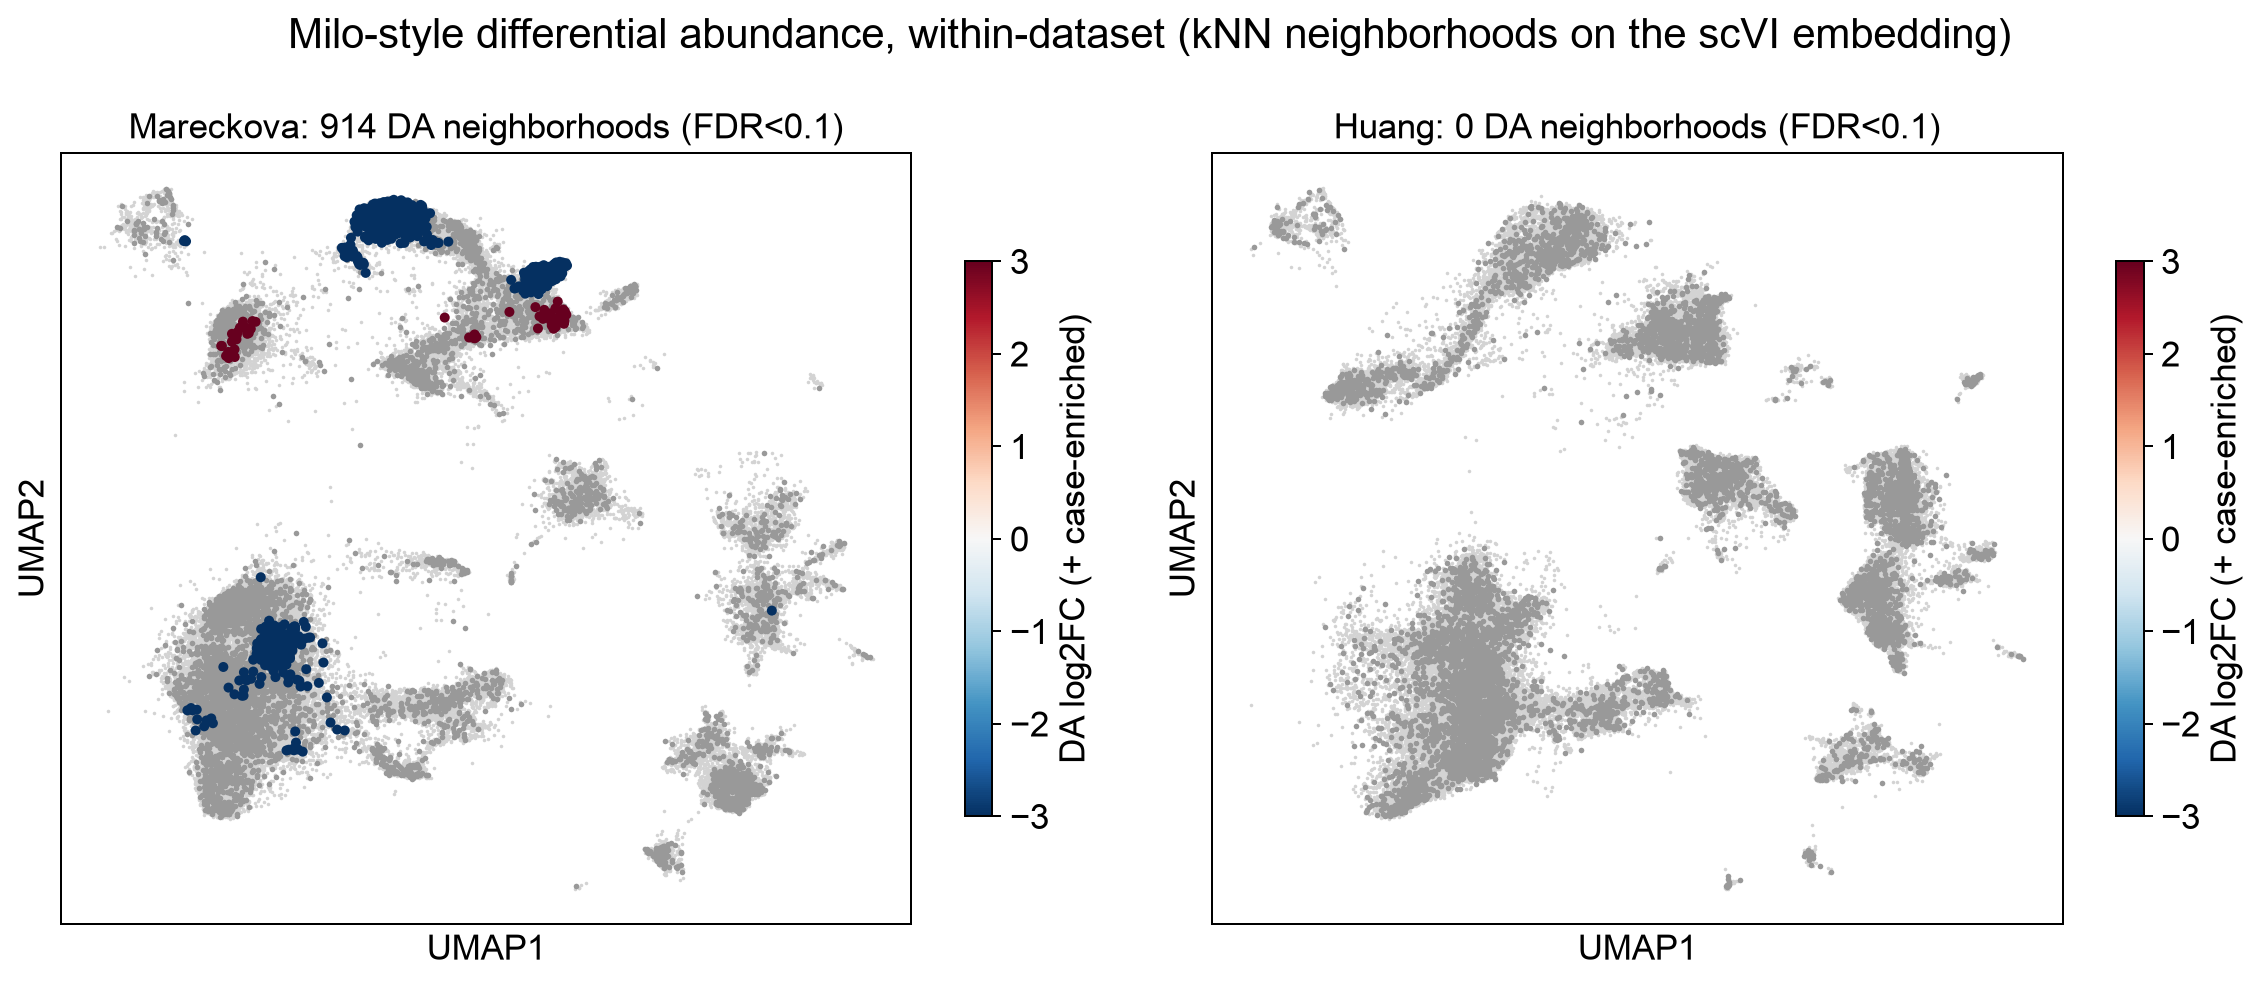

In [45]:
# Paint the differentially abundant neighborhoods onto the shipped UMAP: each index cell colored by
# its DA log2FC (red = case-enriched, blue = case-depleted), significant ones (FDR<0.1) highlighted.
# Mareckova lights up; Huang, run identically, is flat -- the abundance signal does not reproduce.
if _HAVE_R:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.6)); VMAX = 3.0
    for ax, (ds, sub, idx, da) in zip(axes, [("Mareckova", subM, idxM, daM), ("Huang", subH, idxH, daH)]):
        um = sub.obsm["X_umap"]; sig = da["FDR"].values < 0.10
        ax.scatter(um[:, 0], um[:, 1], s=2, c="lightgrey", linewidths=0, rasterized=True)
        ax.scatter(um[idx[~sig], 0], um[idx[~sig], 1], s=5, c="0.6", linewidths=0)   # non-DA neighborhoods
        m = ax.scatter(um[idx[sig], 0], um[idx[sig], 1], s=16, c=da["logFC"].values[sig],
                       cmap="RdBu_r", vmin=-VMAX, vmax=VMAX, linewidths=0)
        ax.set_title(f"{ds}: {int(sig.sum())} DA neighborhoods (FDR<0.1)")
        ax.set_xticks([]); ax.set_yticks([]); ax.set_xlabel("UMAP1"); ax.set_ylabel("UMAP2")
        plt.colorbar(m, ax=ax, shrink=0.72, label="DA log2FC (+ case-enriched)")
    plt.suptitle("Milo-style differential abundance, within-dataset (kNN neighborhoods on the scVI embedding)")
    plt.tight_layout(); plt.show()

The abundance result mirrors the expression result. Within Mareckova, Milo finds many differentially abundant neighborhoods (case-depleted glandular and pre-glandular states, case-enriched secretory-glandular and mid-decidualized stroma). Within Huang, run identically, it finds **none**. And the per-cell-type shifts do not merely fail to reproduce across the two datasets, they **anti-correlate** (Pearson r about −0.4, direction agreement near chance): a state that looks case-depleted in one dataset looks case-enriched in the other. So the strong within-Mareckova abundance signal is dataset-specific structure, not a reproducible disease composition. This is the differential-expression conclusion reached from the abundance side, and it is exactly the confound that led the reference to use single-nuclei data for abundance. Composition on the scRNA atlas stays supporting context, not disease evidence.

In [46]:
import session_info
try:
    session_info.show()
except Exception:
    import sys; print(sys.version); print("scanpy", sc.__version__, "| anndata", ad.__version__)